# Sectors 2014-2025

In [ ]:
# JUPYTER NOTEBOOK CELL — COMPLETE, ROBUST, WITH REQUESTED TITLE CHANGES (COMMODITY CAPITALIZED, NO FIGURE NUMBERS)

import os
import re
import math
import textwrap
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# ------------------------------------------------------------------------------------
# 1) Configuration
# ------------------------------------------------------------------------------------

# If running on your Windows machine, use this:
EXCEL_PATH = r"D:\WRI\Field Boundaries\Tech Note\Agrostat - Brazil - EUDR Crop Exports\Brazil Commodity Exports.xlsx"

# If running in an environment where the file has been uploaded under /mnt/data, use this instead:
# EXCEL_PATH = r"/mnt/data/Brazil Commodity Exports.xlsx"

SHEET_NAME = 0  # change if your data are on another sheet

# Countries of interest and canonical names
COUNTRY_ALIASES = {
    "all": ["all", "total", "totals", "totais", "totais ", "totais\t", "totais/total", "totais/ total", "totais (total)", "totais(total)", "grand total"],
    "china": ["china"],
    "united states": ["united states", "usa", "u.s.a.", "u.s.", "us", "estados unidos", "united states of america", "eua"],
    "european union": ["european union", "eu", "união europeia", "uniao europeia", "ue 27", "ue27", "eu 27", "european union 27", "eu-27", "eu27"],
}

# Product (sector) canonical mapping
PRODUCT_CANON = {
    "soybean": ["soy", "soja", "soybean", "soybeans", "complexo soja", "comple", "soj"],
    "coffee": ["coffee", "cafe", "café", "caf\u00e9", "cafê"],
    "cocoa": ["cocoa", "cacau", "cacao", "cocoa and products", "cocoa products"],
}

# Desired year span
YEAR_START = 2014
YEAR_END = 2025

# Colors (provided): #0099CC, #C51F24, #97BD3D, #7D0063
COLOR_PALETTE = {
    "china": "#0099CC",
    "united states": "#C51F24",
    "european union": "#97BD3D",
    "unused": "#7D0063",
}

# Output figure directory (created if missing)
FIG_DIR = "figures_brazil_exports"
os.makedirs(FIG_DIR, exist_ok=True)

# ------------------------------------------------------------------------------------
# 2) Helpers for normalization and parsing
# ------------------------------------------------------------------------------------

def _ascii_lower(s: str) -> str:
    """Lowercase and lightly deaccent strings without requiring external packages."""
    if s is None:
        return ""
    s = str(s)
    s = s.replace("Á","A").replace("À","A").replace("Â","A").replace("Ã","A").replace("Ä","A").replace("á","a").replace("à","a").replace("â","a").replace("ã","a").replace("ä","a")
    s = s.replace("É","E").replace("È","E").replace("Ê","E").replace("Ë","E").replace("é","e").replace("è","e").replace("ê","e").replace("ë","e")
    s = s.replace("Í","I").replace("Ì","I").replace("Î","I").replace("Ï","I").replace("í","i").replace("ì","i").replace("î","i").replace("ï","i")
    s = s.replace("Ó","O").replace("Ò","O").replace("Ô","O").replace("Õ","O").replace("Ö","O").replace("ó","o").replace("ò","o").replace("ô","o").replace("õ","o").replace("ö","o")
    s = s.replace("Ú","U").replace("Ù","U").replace("Û","U").replace("Ü","U").replace("ú","u").replace("ù","u").replace("û","u").replace("ü","u")
    s = s.replace("Ç","C").replace("ç","c")
    return s.lower().strip()

def parse_year(x) -> Optional[int]:
    """Return a 4-digit year int if present in x; otherwise None."""
    if x is None:
        return None
    s = str(x)
    m = re.search(r"(19|20)\d{2}", s)
    if m:
        return int(m.group(0))
    return None

def is_value_measure(name: str) -> bool:
    """Heuristics to identify 'value' columns."""
    s = _ascii_lower(name)
    return any(k in s for k in ["value", "valor", "us$", "usd", "dollar", "d\u00f3lar", "dolar", "valor(us$", "valor (us$"])

def is_weight_measure(name: str) -> bool:
    """Heuristics to identify 'weight/volume' columns."""
    s = _ascii_lower(name)
    return any(k in s for k in ["weight", "volume", "peso", "kg", "ton", "tonne", "tonnes", "peso(kg", "peso (kg"])

def is_country_header(name: str) -> bool:
    """Heuristics to detect a 'country' column in the second header row."""
    s = _ascii_lower(name)
    return any(k in s for k in ["country", "pa\u00eds", "pais", "bloco/pa\u00eds", "bloco/pais", "bloco", "país", "país/bloco", "pa\u00eds/bloco"])

def is_product_header(name: str) -> bool:
    """Heuristics to detect a 'product/sector' column in the second header row."""
    s = _ascii_lower(name)
    return any(k in s for k in ["product", "setor", "setor(es)", "produto", "sector", "setores", "setores)"])

def canon_country(name: str) -> Optional[str]:
    """Map various country spellings to canonical names (All, China, United States, European Union)."""
    s = _ascii_lower(name)
    for canon, variants in COUNTRY_ALIASES.items():
        for v in variants:
            if v in s:
                if canon == "european union":
                    if ("european" in s) or ("união" in s) or ("uniao" in s) or ("ue" in s) or ("eu 27" in s) or ("eu-27" in s) or ("eu27" in s):
                        return "European Union"
                elif canon == "united states":
                    return "United States"
                elif canon == "china":
                    return "China"
                elif canon == "all":
                    return "All"
    return None

def canon_product(name: str) -> Optional[str]:
    """Map sector strings to Soybean, Coffee, Cocoa; return None if not matched."""
    s = _ascii_lower(name)
    for canon, variants in PRODUCT_CANON.items():
        for v in variants:
            if v in s:
                if canon == "soybean":
                    return "Soybean"
                if canon == "coffee":
                    return "Coffee"
                if canon == "cocoa":
                    return "Cocoa"
    return None

def to_number(x) -> Optional[float]:
    """Convert strings with commas/spaces into float; return None if not numeric."""
    if x is None or (isinstance(x, float) and math.isnan(x)):
        return None
    if isinstance(x, (int, float, np.integer, np.floating)):
        return float(x)
    s = str(x).strip()
    s = s.replace(",", "")  # thousands separators
    s = s.replace("\u00a0", "")  # non-breaking spaces
    s = s.replace(" ", "")
    try:
        return float(s)
    except Exception:
        return None

# ------------------------------------------------------------------------------------
# 3) Load and transform to long/tidy format (robust to NaN top headers)
# ------------------------------------------------------------------------------------

def load_wide_table(path: str, sheet_name=0) -> pd.DataFrame:
    """
    Reads the Excel with first row = years and second row = column labels (country, product, value/weight per year).
    Returns a DataFrame with a normalized 2-level MultiIndex for columns where top=None for ID columns.
    """
    df = pd.read_excel(path, sheet_name=sheet_name, header=[0,1], dtype=object)

    # Normalize column MultiIndex:
    # - Coerce any NaN/"Unnamed" in the top level to None
    # - Strip the bottom level labels
    norm_cols = []
    for col in df.columns:
        if isinstance(col, tuple) and len(col) == 2:
            top, bottom = col
            top_str = "" if (top is None or (isinstance(top, float) and pd.isna(top))) else str(top)
            if top_str.strip() == "" or top_str.lower().startswith("unnamed"):
                top_clean = None
            else:
                top_clean = top
            bottom_clean = str(bottom).strip()
            norm_cols.append((top_clean, bottom_clean))
        else:
            norm_cols.append((None, str(col).strip()))
    df.columns = pd.MultiIndex.from_tuples(norm_cols)
    return df

def _first_column_key_with_bottom(df_multi: pd.DataFrame, bottom_label: str) -> Optional[Tuple[object, str]]:
    """
    Find the first (top, bottom) column key whose bottom matches bottom_label (case-insensitive, stripped).
    Prefer a column whose top is None; otherwise return the first match.
    """
    target = _ascii_lower(bottom_label)
    candidates = [c for c in df_multi.columns if _ascii_lower(c[1]) == target]
    if not candidates:
        return None
    for c in candidates:
        if c[0] is None:
            return c
    return candidates[0]

def find_id_columns(df_multi: pd.DataFrame) -> Tuple[Tuple[object, str], Tuple[object, str]]:
    """
    Locate the actual (top, bottom) keys for the 'country' and 'product' columns
    from the second header row (bottom labels). If heuristics fail, fall back to the
    first two columns by position.
    Returns the exact MultiIndex keys (top,bottom) for country and product.
    """
    country_key = None
    product_key = None
    for top, bottom in df_multi.columns:
        if is_country_header(bottom) and country_key is None:
            country_key = _first_column_key_with_bottom(df_multi, bottom)
        if is_product_header(bottom) and product_key is None:
            product_key = _first_column_key_with_bottom(df_multi, bottom)

    if country_key is None or product_key is None:
        cols = list(df_multi.columns)
        if len(cols) < 2:
            raise ValueError("Could not infer 'country' and 'product' columns.")
        country_key = cols[0] if country_key is None else country_key
        product_key = cols[1] if product_key is None else product_key

    return country_key, product_key

def melt_to_long(df_multi: pd.DataFrame) -> pd.DataFrame:
    """
    Convert the multiindex wide table into a long, tidy format:
    Columns: country, product, year, measure ('value'|'weight'), amount (float)
    """
    country_key, product_key = find_id_columns(df_multi)

    value_cols: List[Tuple[Tuple[object, str], int]] = []
    weight_cols: List[Tuple[Tuple[object, str], int]] = []

    for (top, bottom) in df_multi.columns:
        y = parse_year(top)
        if y is None:
            continue
        if is_value_measure(bottom):
            value_cols.append(((top, bottom), y))
        elif is_weight_measure(bottom):
            weight_cols.append(((top, bottom), y))

    if not value_cols and not weight_cols:
        raise ValueError("No value/weight measure columns were detected. Please check header rows.")

    id_df = pd.DataFrame({
        "country": df_multi[country_key],
        "product": df_multi[product_key],
    })

    long_frames = []

    if value_cols:
        df_val = id_df.copy()
        for (key, y) in value_cols:
            df_val[y] = df_multi[key]
        dfm = df_val.melt(id_vars=["country", "product"], var_name="year", value_name="amount")
        dfm["measure"] = "value"
        long_frames.append(dfm)

    if weight_cols:
        df_wt = id_df.copy()
        for (key, y) in weight_cols:
            df_wt[y] = df_multi[key]
        dfm2 = df_wt.melt(id_vars=["country", "product"], var_name="year", value_name="amount")
        dfm2["measure"] = "weight"
        long_frames.append(dfm2)

    long_df = pd.concat(long_frames, ignore_index=True)

    long_df["year"] = pd.to_numeric(long_df["year"], errors="coerce").astype("Int64")
    long_df["amount"] = long_df["amount"].apply(to_number)
    long_df = long_df.dropna(subset=["year", "amount"]).copy()

    long_df["product_canon"] = long_df["product"].apply(canon_product)
    long_df["country_canon"] = long_df["country"].apply(canon_country)

    keep_products = ["Soybean", "Coffee", "Cocoa"]
    long_df = long_df[long_df["product_canon"].isin(keep_products)].copy()
    long_df = long_df[long_df["country_canon"].isin(["All", "China", "United States", "European Union"])].copy()

    long_df = long_df[(long_df["year"] >= YEAR_START) & (long_df["year"] <= YEAR_END)].copy()

    long_df = long_df[["country_canon", "product_canon", "year", "measure", "amount"]].rename(
        columns={
            "country_canon": "country",
            "product_canon": "product"
        }
    ).reset_index(drop=True)

    return long_df

def compute_share_percent(long_df: pd.DataFrame) -> pd.DataFrame:
    """
    From tidy long data, compute percent shares for (China, United States, European Union)
    dividing by 'All' for the same (product, year, measure).
    Returns columns: country, product, year, measure, share_pct
    """
    all_df = long_df[long_df["country"] == "All"][["product", "year", "measure", "amount"]].rename(columns={"amount": "total_amount"})
    merged = long_df.merge(all_df, on=["product", "year", "measure"], how="left", validate="m:1")
    merged["share_pct"] = (merged["amount"] / merged["total_amount"]) * 100.0
    out = merged[merged["country"].isin(["China", "United States", "European Union"])].copy()
    out = out.replace([np.inf, -np.inf], np.nan).dropna(subset=["share_pct"])
    return out[["country", "product", "year", "measure", "share_pct"]].reset_index(drop=True)

# ------------------------------------------------------------------------------------
# 4) Plotting with WRI figure style (title without numbering; commodity first letter capitalized)
# ------------------------------------------------------------------------------------

def sentence_case(s: str) -> str:
    s = str(s).strip()
    return s[:1].upper() + s[1:].lower() if s else s

def wrap_text(s: str, width: int = 100) -> str:
    return "\n".join(textwrap.wrap(s, width=width, break_long_words=False))

def plot_share_lines(
    df_share: pd.DataFrame,
    product: str,
    measure: str,
    figure_number: int,   # kept for file naming; not used in the title
    note_text: str,
    source_text: str,
    save_dir: str = FIG_DIR
) -> str:
    """
    Plot share lines for given product and measure ('value' or 'weight').
    Returns the saved filepath.
    """
    sub = df_share[(df_share["product"] == product) & (df_share["measure"] == measure)].copy()
    if sub.empty:
        raise ValueError(f"No data available to plot for product={product}, measure={measure}.")

    pivot = sub.pivot_table(index="year", columns="country", values="share_pct", aggfunc="mean").sort_index()
    ordered_countries = ["China", "United States", "European Union"]
    pivot = pivot.reindex(columns=ordered_countries)

    measure_label = "value" if measure == "value" else "weight"
    # Ensure commodity just capitalizes first letter
    product_cap = product[:1].upper() + product[1:].lower()
    title = f"Brazilian {product_cap} export share by destination, {YEAR_START}–{YEAR_END} ({measure_label})"

    fig, ax = plt.subplots(figsize=(10, 6), dpi=150)

    for c in ordered_countries:
        if c in pivot.columns:
            ax.plot(pivot.index, pivot[c], label=c, linewidth=2.2, color=COLOR_PALETTE[_ascii_lower(c)])

    ax.set_xlabel("Year")
    ax.set_ylabel("Share of exports (%)")
    ymax = np.nanmax(pivot.values)
    if np.isnan(ymax):
        ymax = 100
    ax.set_ylim(0, max(100, math.ceil(ymax / 10.0) * 10))
    ax.yaxis.set_major_locator(MaxNLocator(integer=True, nbins=6))
    ax.grid(True, axis="y", alpha=0.2, linewidth=0.8)
    ax.legend(title=sentence_case("destination"), frameon=False)

    # Bold title
    plt.suptitle(title, fontsize=12, fontweight="bold", y=0.98)

    note_text = wrap_text(note_text, width=110)
    source_text = wrap_text(source_text, width=110)
    plt.subplots_adjust(top=0.86, bottom=0.22)

    # Annotations below the chart
    fig.text(0.01, 0.12, f"Note(s): {note_text}", ha="left", va="top", fontsize=9, style="italic")
    fig.text(0.01, 0.06, f"Sources: {source_text}", ha="left", va="top", fontsize=9)

    safe_prod = product.lower().replace(" ", "_")
    outpath = os.path.join(save_dir, f"figure_{figure_number:02d}_{safe_prod}_{measure_label}_share.png")
    plt.savefig(outpath, bbox_inches="tight")
    plt.show()

    return outpath

# ------------------------------------------------------------------------------------
# 5) Run: load, transform, compute shares, and generate charts
# ------------------------------------------------------------------------------------

df_wide = load_wide_table(EXCEL_PATH, sheet_name=SHEET_NAME)
df_long = melt_to_long(df_wide)
df_share = compute_share_percent(df_long)

available_years = sorted(df_share["year"].dropna().unique().tolist())
print("Available years in the dataset:", available_years)

products_to_plot = ["Soybean", "Coffee", "Cocoa"]
measures_to_plot = ["value", "weight"]

NOTE_VALUE = (
    "Shares are calculated as destination value divided by the total for the same product and year; "
    "value represents export value in nominal US dollars as provided in the source data."
)
NOTE_WEIGHT = (
    "Shares are calculated as destination weight divided by the total for the same product and year; "
    "weight represents physical quantities (e.g., kilograms or tonnes) as provided in the source data."
)
SOURCES = "Brazilian export data sourced from Agrostat of the Ministério da Agricultura Pecuária e Abastecimento; WRI analysis."

figure_counter = 1
saved_files: List[str] = []

for prod in products_to_plot:
    for meas in measures_to_plot:
        note = NOTE_VALUE if meas == "value" else NOTE_WEIGHT
        try:
            outpng = plot_share_lines(
                df_share=df_share,
                product=prod,
                measure=meas,
                figure_number=figure_counter,  # numbering retained in filenames only
                note_text=note,
                source_text=SOURCES,
                save_dir=FIG_DIR
            )
            saved_files.append(outpng)
            print(f"Saved: {outpng}")
            figure_counter += 1
        except ValueError as e:
            print(f"Skipping {prod} ({meas}): {e}")

# Optional: export the long-format shares table to CSV
shares_csv_path = os.path.join(FIG_DIR, "brazil_export_shares_2014_2025.csv")
df_share.sort_values(["product", "measure", "country", "year"]).to_csv(shares_csv_path, index=False)
print(f"Exported shares table: {shares_csv_path}")


# Sectors 1997 - 2025

In [ ]:
# JUPYTER NOTEBOOK CELL — UPDATED FOR 1997–2025 AND TWO-ROW HEADER; EXCLUDES UNITED STATES FROM CHARTS

import os
import re
import math
import textwrap
from typing import List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# ------------------------------------------------------------------------------------
# 1) Configuration
# ------------------------------------------------------------------------------------

# Update path to your new workbook
EXCEL_PATH = r"D:\WRI\Field Boundaries\Tech Note\Agrostat - Brazil - EUDR Crop Exports\Brazil Commodity Exports 1997-2025.xlsx"
# If running in an environment where the file has been uploaded under /mnt/data, use this instead:
# EXCEL_PATH = r"/mnt/data/Brazil Commodity Exports 1997-2025.xlsx"

SHEET_NAME = 0  # change if your data are on another sheet

# Countries of interest and canonical names
COUNTRY_ALIASES = {
    "all": ["all", "total", "totals", "totais", "grand total"],
    "china": ["china"],
    "united states": ["united states", "usa", "u.s.a.", "u.s.", "us", "estados unidos", "united states of america", "eua"],
    "european union": ["european union", "eu", "ue 27", "ue27", "eu 27", "eu-27", "eu27", "ue"],
}

# Product (sector) canonical mapping
PRODUCT_CANON = {
    "soybean": ["soy", "soja", "soybean", "soybeans", "complexo soja", "soj"],
    "coffee": ["coffee", "cafe", "café", "caf\u00e9", "cafê"],
    "cocoa": ["cocoa", "cacau", "cacao", "cocoa and products", "cocoa products"],
}

# Desired year span (UPDATED)
YEAR_START = 1997
YEAR_END = 2025

# Colors (provided): #0099CC, #C51F24, #97BD3D, #7D0063
COLOR_PALETTE = {
    "china": "#0099CC",
    "united states": "#C51F24",   # not used in the no-US charts
    "european union": "#97BD3D",
    "unused": "#7D0063",
}

# Output figure directory (created if missing)
FIG_DIR = "figures_brazil_exports"
os.makedirs(FIG_DIR, exist_ok=True)

# ------------------------------------------------------------------------------------
# 2) Helpers for normalization and parsing
# ------------------------------------------------------------------------------------

def _ascii_lower(s: str) -> str:
    if s is None:
        return ""
    s = str(s)
    s = s.replace("Á","A").replace("À","A").replace("Â","A").replace("Ã","A").replace("Ä","A").replace("á","a").replace("à","a").replace("â","a").replace("ã","a").replace("ä","a")
    s = s.replace("É","E").replace("È","E").replace("Ê","E").replace("Ë","E").replace("é","e").replace("è","e").replace("ê","e").replace("ë","e")
    s = s.replace("Í","I").replace("Ì","I").replace("Î","I").replace("Ï","I").replace("í","i").replace("ì","i").replace("î","i").replace("ï","i")
    s = s.replace("Ó","O").replace("Ò","O").replace("Ô","O").replace("Õ","O").replace("Ö","O").replace("ó","o").replace("ò","o").replace("ô","o").replace("õ","o").replace("ö","o")
    s = s.replace("Ú","U").replace("Ù","U").replace("Û","U").replace("Ü","U").replace("ú","u").replace("ù","u").replace("û","u").replace("ü","u")
    s = s.replace("Ç","C").replace("ç","c")
    return s.lower().strip()

def parse_year(x) -> Optional[int]:
    if x is None:
        return None
    s = str(x)
    m = re.search(r"(19|20)\d{2}", s)
    if m:
        return int(m.group(0))
    return None

def is_value_measure(name: str) -> bool:
    s = _ascii_lower(name)
    return any(k in s for k in ["value", "valor", "us$", "usd", "dollar", "d\u00f3lar", "dolar"])

def is_weight_measure(name: str) -> bool:
    s = _ascii_lower(name)
    return any(k in s for k in ["weight", "volume", "peso", "kg", "ton", "tonne", "tonnes"])

def is_country_header(name: str) -> bool:
    s = _ascii_lower(name)
    return any(k in s for k in ["country", "pa\u00eds", "pais", "bloco", "país"])

def is_product_header(name: str) -> bool:
    s = _ascii_lower(name)
    return any(k in s for k in ["product", "setor", "produto", "sector"])

def canon_country(name: str) -> Optional[str]:
    s = _ascii_lower(name)
    # Exact/short forms first to ensure "EU" maps correctly
    if s in {"eu", "ue", "eu-27", "eu27", "eu 27", "ue27", "ue 27"} or "european union" in s:
        return "European Union"
    if any(v in s for v in COUNTRY_ALIASES["china"]):
        return "China"
    if any(v in s for v in COUNTRY_ALIASES["united states"]):
        return "United States"
    if any(v in s for v in COUNTRY_ALIASES["all"]):
        return "All"
    return None

def canon_product(name: str) -> Optional[str]:
    s = _ascii_lower(name)
    for canon, variants in PRODUCT_CANON.items():
        for v in variants:
            if v in s:
                return {"soybean": "Soybean", "coffee": "Coffee", "cocoa": "Cocoa"}[canon]
    return None

def to_number(x) -> Optional[float]:
    if x is None or (isinstance(x, float) and math.isnan(x)):
        return None
    if isinstance(x, (int, float, np.integer, np.floating)):
        return float(x)
    s = str(x).strip().replace(",", "").replace("\u00a0", "").replace(" ", "")
    try:
        return float(s)
    except Exception:
        return None

# ------------------------------------------------------------------------------------
# 3) Load and transform to long/tidy format (two-row header: years on row 1, labels on row 2)
# ------------------------------------------------------------------------------------

def load_wide_table(path: str, sheet_name=0) -> pd.DataFrame:
    df = pd.read_excel(path, sheet_name=sheet_name, header=[0, 1], dtype=object)

    # Normalize the column MultiIndex:
    norm_cols = []
    for col in df.columns:
        if isinstance(col, tuple) and len(col) == 2:
            top, bottom = col
            top_clean = None if (top is None or (isinstance(top, float) and pd.isna(top)) or str(top).lower().startswith("unnamed")) else top
            bottom_clean = str(bottom).strip()
            norm_cols.append((top_clean, bottom_clean))
        else:
            norm_cols.append((None, str(col).strip()))
    df.columns = pd.MultiIndex.from_tuples(norm_cols)
    return df

def _first_column_key_with_bottom(df_multi: pd.DataFrame, bottom_label: str) -> Optional[Tuple[object, str]]:
    target = _ascii_lower(bottom_label)
    candidates = [c for c in df_multi.columns if _ascii_lower(c[1]) == target]
    if not candidates:
        return None
    for c in candidates:
        if c[0] is None:
            return c
    return candidates[0]

def find_id_columns(df_multi: pd.DataFrame) -> Tuple[Tuple[object, str], Tuple[object, str]]:
    country_key = None
    product_key = None
    for top, bottom in df_multi.columns:
        if is_country_header(bottom) and country_key is None:
            country_key = _first_column_key_with_bottom(df_multi, bottom)
        if is_product_header(bottom) and product_key is None:
            product_key = _first_column_key_with_bottom(df_multi, bottom)
    if country_key is None or product_key is None:
        cols = list(df_multi.columns)
        if len(cols) < 2:
            raise ValueError("Could not infer 'country' and 'product' columns.")
        country_key = cols[0] if country_key is None else country_key
        product_key = cols[1] if product_key is None else product_key
    return country_key, product_key

def melt_to_long(df_multi: pd.DataFrame) -> pd.DataFrame:
    country_key, product_key = find_id_columns(df_multi)

    value_cols: List[Tuple[Tuple[object, str], int]] = []
    weight_cols: List[Tuple[Tuple[object, str], int]] = []
    for (top, bottom) in df_multi.columns:
        y = parse_year(top)
        if y is None:
            continue
        if is_value_measure(bottom):
            value_cols.append(((top, bottom), y))
        elif is_weight_measure(bottom):
            weight_cols.append(((top, bottom), y))

    if not value_cols and not weight_cols:
        raise ValueError("No value/weight measure columns were detected. Please check header rows.")

    id_df = pd.DataFrame({
        "country": df_multi[country_key],
        "product": df_multi[product_key],
    })

    long_frames = []
    if value_cols:
        df_val = id_df.copy()
        for (key, y) in value_cols:
            df_val[y] = df_multi[key]
        dfm = df_val.melt(id_vars=["country", "product"], var_name="year", value_name="amount")
        dfm["measure"] = "value"
        long_frames.append(dfm)

    if weight_cols:
        df_wt = id_df.copy()
        for (key, y) in weight_cols:
            df_wt[y] = df_multi[key]
        dfm2 = df_wt.melt(id_vars=["country", "product"], var_name="year", value_name="amount")
        dfm2["measure"] = "weight"
        long_frames.append(dfm2)

    long_df = pd.concat(long_frames, ignore_index=True)
    long_df["year"] = pd.to_numeric(long_df["year"], errors="coerce").astype("Int64")
    long_df["amount"] = long_df["amount"].apply(to_number)
    long_df = long_df.dropna(subset=["year", "amount"]).copy()

    long_df["product_canon"] = long_df["product"].apply(canon_product)
    long_df["country_canon"] = long_df["country"].apply(canon_country)

    keep_products = ["Soybean", "Coffee", "Cocoa"]
    long_df = long_df[long_df["product_canon"].isin(keep_products)].copy()
    long_df = long_df[long_df["country_canon"].isin(["All", "China", "United States", "European Union"])].copy()

    long_df = long_df[(long_df["year"] >= YEAR_START) & (long_df["year"] <= YEAR_END)].copy()

    long_df = long_df[["country_canon", "product_canon", "year", "measure", "amount"]].rename(
        columns={"country_canon": "country", "product_canon": "product"}
    ).reset_index(drop=True)

    return long_df

def compute_share_percent(long_df: pd.DataFrame) -> pd.DataFrame:
    all_df = long_df[long_df["country"] == "All"][["product", "year", "measure", "amount"]].rename(columns={"amount": "total_amount"})
    merged = long_df.merge(all_df, on=["product", "year", "measure"], how="left", validate="m:1")
    merged["share_pct"] = (merged["amount"] / merged["total_amount"]) * 100.0
    out = merged[merged["country"].isin(["China", "United States", "European Union"])].copy()
    out = out.replace([np.inf, -np.inf], np.nan).dropna(subset=["share_pct"])
    return out[["country", "product", "year", "measure", "share_pct"]].reset_index(drop=True)

# ------------------------------------------------------------------------------------
# 4) Plotting with WRI figure style (title without numbering; commodity first letter capitalized)
#     — Charts show ONLY China and European Union (United States excluded)
# ------------------------------------------------------------------------------------

def sentence_case(s: str) -> str:
    s = str(s).strip()
    return s[:1].upper() + s[1:].lower() if s else s

def wrap_text(s: str, width: int = 100) -> str:
    return "\n".join(textwrap.wrap(s, width=width, break_long_words=False))

def plot_share_lines_no_us(
    df_share: pd.DataFrame,
    product: str,
    measure: str,
    figure_number: int,
    note_text: str,
    source_text: str,
    save_dir: str = FIG_DIR
) -> str:
    sub = df_share[(df_share["product"] == product) & (df_share["measure"] == measure)].copy()
    if sub.empty:
        raise ValueError(f"No data available to plot for product={product}, measure={measure}.")

    # Force exclusion of US and keep only China & EU
    sub = sub[sub["country"].isin(["China", "European Union"])].copy()

    pivot = sub.pivot_table(index="year", columns="country", values="share_pct", aggfunc="mean").sort_index()
    pivot = pivot.reindex(columns=["China", "European Union"])

    measure_label = "value" if measure == "value" else "weight"
    product_cap = product[:1].upper() + product[1:].lower()
    title = f"Brazilian {product_cap} export share by destination, {YEAR_START}–{YEAR_END} ({measure_label})"

    fig, ax = plt.subplots(figsize=(10, 6), dpi=150)

    for c in ["China", "European Union"]:
        if c in pivot.columns:
            ax.plot(pivot.index, pivot[c], label=c, linewidth=2.2, color=COLOR_PALETTE[_ascii_lower(c)])

    ax.set_xlabel("Year")
    ax.set_ylabel("Share of exports (%)")
    ymax = np.nanmax(pivot.values)
    if np.isnan(ymax):
        ymax = 100
    ax.set_ylim(0, max(100, math.ceil(ymax / 10.0) * 10))
    ax.yaxis.set_major_locator(MaxNLocator(integer=True, nbins=6))
    ax.grid(True, axis="y", alpha=0.2, linewidth=0.8)
    ax.legend(title=sentence_case("destination"), frameon=False)

    plt.suptitle(title, fontsize=12, fontweight="bold", y=0.98)

    note_text = wrap_text(note_text, width=110)
    source_text = wrap_text(source_text, width=110)
    plt.subplots_adjust(top=0.86, bottom=0.22)
    fig.text(0.01, 0.12, f"Note(s): {note_text}", ha="left", va="top", fontsize=9, style="italic")
    fig.text(0.01, 0.06, f"Sources: {source_text}", ha="left", va="top", fontsize=9)

    safe_prod = product.lower().replace(" ", "_")
    outpath = os.path.join(save_dir, f"figure_{figure_number:02d}_{safe_prod}_{measure_label}_share_no_us.png")
    plt.savefig(outpath, bbox_inches="tight")
    plt.show()
    return outpath

# ------------------------------------------------------------------------------------
# 5) Run: load, transform, compute shares, and generate charts (1997–2025)
# ------------------------------------------------------------------------------------

df_wide = load_wide_table(EXCEL_PATH, sheet_name=SHEET_NAME)
df_long = melt_to_long(df_wide)
df_share = compute_share_percent(df_long)

available_years = sorted(df_share["year"].dropna().unique().tolist())
print("Available years in the dataset:", available_years)

products_to_plot = ["Soybean", "Coffee", "Cocoa"]
measures_to_plot = ["value", "weight"]

NOTE_VALUE = (
    "Shares are calculated as destination value divided by the total for the same product and year; "
    "value represents export value in nominal US dollars as provided in the source data."
)
NOTE_WEIGHT = (
    "Shares are calculated as destination weight divided by the total for the same product and year; "
    "weight represents physical quantities (e.g., kilograms or tonnes) as provided in the source data."
)
SOURCES = "Brazilian export data sourced from Agrostat of the Ministério da Agricultura Pecuária e Abastecimento; WRI analysis."

figure_counter = 1
saved_files: List[str] = []

# Create charts WITHOUT the United States
for prod in products_to_plot:
    for meas in measures_to_plot:
        note = NOTE_VALUE if meas == "value" else NOTE_WEIGHT
        try:
            outpng = plot_share_lines_no_us(
                df_share=df_share,
                product=prod,
                measure=meas,
                figure_number=figure_counter,
                note_text=note,
                source_text=SOURCES,
                save_dir=FIG_DIR
            )
            saved_files.append(outpng)
            print(f"Saved (no US): {outpng}")
            figure_counter += 1
        except ValueError as e:
            print(f"Skipping (no US) {prod} ({meas}): {e}")

# Optional: export the long-format shares table (1997–2025, China & EU only) to CSV
shares_csv_path = os.path.join(FIG_DIR, "brazil_export_shares_1997_2025_no_us.csv")
(df_share[df_share["country"].isin(["China", "European Union"])]
 .sort_values(["product", "measure", "country", "year"])
 .to_csv(shares_csv_path, index=False))
print(f"Exported shares table (no US): {shares_csv_path}")


add USA back in for long-trend

In [ ]:
# JUPYTER NOTEBOOK CELL — 1997–2025, TWO-ROW HEADER, UNITED STATES INCLUDED (China, United States, European Union)

import os
import re
import math
import textwrap
from typing import List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# ------------------------------------------------------------------------------------
# 1) Configuration
# ------------------------------------------------------------------------------------

# Workbook path
EXCEL_PATH = r"D:\WRI\Field Boundaries\Tech Note\Agrostat - Brazil - EUDR Crop Exports\Brazil Commodity Exports 1997-2025.xlsx"
# If running in an environment where the file has been uploaded under /mnt/data, use this instead:
# EXCEL_PATH = r"/mnt/data/Brazil Commodity Exports 1997-2025.xlsx"

SHEET_NAME = 0  # change if your data are on another sheet

# Countries of interest and canonical names
COUNTRY_ALIASES = {
    "all": ["all", "total", "totals", "totais", "grand total"],
    "china": ["china"],
    "united states": ["united states", "usa", "u.s.a.", "u.s.", "us", "estados unidos", "united states of america", "eua"],
    "european union": ["european union", "eu", "ue 27", "ue27", "eu 27", "eu-27", "eu27", "ue"],
}

# Product (sector) canonical mapping
PRODUCT_CANON = {
    "soybean": ["soy", "soja", "soybean", "soybeans", "complexo soja", "soj"],
    "coffee": ["coffee", "cafe", "café", "caf\u00e9", "cafê"],
    "cocoa": ["cocoa", "cacau", "cacao", "cocoa and products", "cocoa products"],
}

# Desired year span
YEAR_START = 1997
YEAR_END = 2025

# Colors (provided): #0099CC, #C51F24, #97BD3D, #7D0063
COLOR_PALETTE = {
    "china": "#0099CC",
    "united states": "#C51F24",
    "european union": "#97BD3D",
    "unused": "#7D0063",
}

# Output figure directory (created if missing)
FIG_DIR = "figures_brazil_exports"
os.makedirs(FIG_DIR, exist_ok=True)

# ------------------------------------------------------------------------------------
# 2) Helpers for normalization and parsing
# ------------------------------------------------------------------------------------

def _ascii_lower(s: str) -> str:
    if s is None:
        return ""
    s = str(s)
    s = s.replace("Á","A").replace("À","A").replace("Â","A").replace("Ã","A").replace("Ä","A").replace("á","a").replace("à","a").replace("â","a").replace("ã","a").replace("ä","a")
    s = s.replace("É","E").replace("È","E").replace("Ê","E").replace("Ë","E").replace("é","e").replace("è","e").replace("ê","e").replace("ë","e")
    s = s.replace("Í","I").replace("Ì","I").replace("Î","I").replace("Ï","I").replace("í","i").replace("ì","i").replace("î","i").replace("ï","i")
    s = s.replace("Ó","O").replace("Ò","O").replace("Ô","O").replace("Õ","O").replace("Ö","O").replace("ó","o").replace("ò","o").replace("ô","o").replace("õ","o").replace("ö","o")
    s = s.replace("Ú","U").replace("Ù","U").replace("Û","U").replace("Ü","U").replace("ú","u").replace("ù","u").replace("û","u").replace("ü","u")
    s = s.replace("Ç","C").replace("ç","c")
    return s.lower().strip()

def parse_year(x) -> Optional[int]:
    if x is None:
        return None
    s = str(x)
    m = re.search(r"(19|20)\d{2}", s)
    if m:
        return int(m.group(0))
    return None

def is_value_measure(name: str) -> bool:
    s = _ascii_lower(name)
    return any(k in s for k in ["value", "valor", "us$", "usd", "dollar", "d\u00f3lar", "dolar"])

def is_weight_measure(name: str) -> bool:
    s = _ascii_lower(name)
    return any(k in s for k in ["weight", "volume", "peso", "kg", "ton", "tonne", "tonnes"])

def is_country_header(name: str) -> bool:
    s = _ascii_lower(name)
    return any(k in s for k in ["country", "pa\u00eds", "pais", "bloco", "país"])

def is_product_header(name: str) -> bool:
    s = _ascii_lower(name)
    return any(k in s for k in ["product", "setor", "produto", "sector"])

def canon_country(name: str) -> Optional[str]:
    s = _ascii_lower(name)
    if s in {"eu", "ue", "eu-27", "eu27", "eu 27", "ue27", "ue 27"} or "european union" in s:
        return "European Union"
    if any(v in s for v in COUNTRY_ALIASES["china"]):
        return "China"
    if any(v in s for v in COUNTRY_ALIASES["united states"]):
        return "United States"
    if any(v in s for v in COUNTRY_ALIASES["all"]):
        return "All"
    return None

def canon_product(name: str) -> Optional[str]:
    s = _ascii_lower(name)
    for canon, variants in PRODUCT_CANON.items():
        for v in variants:
            if v in s:
                return {"soybean": "Soybean", "coffee": "Coffee", "cocoa": "Cocoa"}[canon]
    return None

def to_number(x) -> Optional[float]:
    if x is None or (isinstance(x, float) and math.isnan(x)):
        return None
    if isinstance(x, (int, float, np.integer, np.floating)):
        return float(x)
    s = str(x).strip().replace(",", "").replace("\u00a0", "").replace(" ", "")
    try:
        return float(s)
    except Exception:
        return None

# ------------------------------------------------------------------------------------
# 3) Load and transform to long/tidy format (two-row header: years on row 1, labels on row 2)
# ------------------------------------------------------------------------------------

def load_wide_table(path: str, sheet_name=0) -> pd.DataFrame:
    df = pd.read_excel(path, sheet_name=sheet_name, header=[0, 1], dtype=object)

    # Normalize the column MultiIndex:
    norm_cols = []
    for col in df.columns:
        if isinstance(col, tuple) and len(col) == 2:
            top, bottom = col
            top_clean = None if (top is None or (isinstance(top, float) and pd.isna(top)) or str(top).lower().startswith("unnamed")) else top
            bottom_clean = str(bottom).strip()
            norm_cols.append((top_clean, bottom_clean))
        else:
            norm_cols.append((None, str(col).strip()))
    df.columns = pd.MultiIndex.from_tuples(norm_cols)
    return df

def _first_column_key_with_bottom(df_multi: pd.DataFrame, bottom_label: str) -> Optional[Tuple[object, str]]:
    target = _ascii_lower(bottom_label)
    candidates = [c for c in df_multi.columns if _ascii_lower(c[1]) == target]
    if not candidates:
        return None
    for c in candidates:
        if c[0] is None:
            return c
    return candidates[0]

def find_id_columns(df_multi: pd.DataFrame) -> Tuple[Tuple[object, str], Tuple[object, str]]:
    country_key = None
    product_key = None
    for top, bottom in df_multi.columns:
        if is_country_header(bottom) and country_key is None:
            country_key = _first_column_key_with_bottom(df_multi, bottom)
        if is_product_header(bottom) and product_key is None:
            product_key = _first_column_key_with_bottom(df_multi, bottom)
    if country_key is None or product_key is None:
        cols = list(df_multi.columns)
        if len(cols) < 2:
            raise ValueError("Could not infer 'country' and 'product' columns.")
        country_key = cols[0] if country_key is None else country_key
        product_key = cols[1] if product_key is None else product_key
    return country_key, product_key

def melt_to_long(df_multi: pd.DataFrame) -> pd.DataFrame:
    country_key, product_key = find_id_columns(df_multi)

    value_cols: List[Tuple[Tuple[object, str], int]] = []
    weight_cols: List[Tuple[Tuple[object, str], int]] = []
    for (top, bottom) in df_multi.columns:
        y = parse_year(top)
        if y is None:
            continue
        if is_value_measure(bottom):
            value_cols.append(((top, bottom), y))
        elif is_weight_measure(bottom):
            weight_cols.append(((top, bottom), y))

    if not value_cols and not weight_cols:
        raise ValueError("No value/weight measure columns were detected. Please check header rows.")

    id_df = pd.DataFrame({
        "country": df_multi[country_key],
        "product": df_multi[product_key],
    })

    long_frames = []
    if value_cols:
        df_val = id_df.copy()
        for (key, y) in value_cols:
            df_val[y] = df_multi[key]
        dfm = df_val.melt(id_vars=["country", "product"], var_name="year", value_name="amount")
        dfm["measure"] = "value"
        long_frames.append(dfm)

    if weight_cols:
        df_wt = id_df.copy()
        for (key, y) in weight_cols:
            df_wt[y] = df_multi[key]
        dfm2 = df_wt.melt(id_vars=["country", "product"], var_name="year", value_name="amount")
        dfm2["measure"] = "weight"
        long_frames.append(dfm2)

    long_df = pd.concat(long_frames, ignore_index=True)
    long_df["year"] = pd.to_numeric(long_df["year"], errors="coerce").astype("Int64")
    long_df["amount"] = long_df["amount"].apply(to_number)
    long_df = long_df.dropna(subset=["year", "amount"]).copy()

    long_df["product_canon"] = long_df["product"].apply(canon_product)
    long_df["country_canon"] = long_df["country"].apply(canon_country)

    keep_products = ["Soybean", "Coffee", "Cocoa"]
    long_df = long_df[long_df["product_canon"].isin(keep_products)].copy()
    long_df = long_df[long_df["country_canon"].isin(["All", "China", "United States", "European Union"])].copy()

    long_df = long_df[(long_df["year"] >= YEAR_START) & (long_df["year"] <= YEAR_END)].copy()

    long_df = long_df[["country_canon", "product_canon", "year", "measure", "amount"]].rename(
        columns={"country_canon": "country", "product_canon": "product"}
    ).reset_index(drop=True)

    return long_df

def compute_share_percent(long_df: pd.DataFrame) -> pd.DataFrame:
    all_df = long_df[long_df["country"] == "All"][["product", "year", "measure", "amount"]].rename(columns={"amount": "total_amount"})
    merged = long_df.merge(all_df, on=["product", "year", "measure"], how="left", validate="m:1")
    merged["share_pct"] = (merged["amount"] / merged["total_amount"]) * 100.0
    out = merged[merged["country"].isin(["China", "United States", "European Union"])].copy()
    out = out.replace([np.inf, -np.inf], np.nan).dropna(subset=["share_pct"])
    return out[["country", "product", "year", "measure", "share_pct"]].reset_index(drop=True)

# ------------------------------------------------------------------------------------
# 4) Plotting with WRI figure style (title without numbering; commodity first letter capitalized)
#     — Charts show China, United States, and European Union
# ------------------------------------------------------------------------------------

def sentence_case(s: str) -> str:
    s = str(s).strip()
    return s[:1].upper() + s[1:].lower() if s else s

def wrap_text(s: str, width: int = 100) -> str:
    return "\n".join(textwrap.wrap(s, width=width, break_long_words=False))

def plot_share_lines(
    df_share: pd.DataFrame,
    product: str,
    measure: str,
    figure_number: int,   # used in filename only (titles have no figure numbers)
    note_text: str,
    source_text: str,
    save_dir: str = FIG_DIR
) -> str:
    sub = df_share[(df_share["product"] == product) & (df_share["measure"] == measure)].copy()
    if sub.empty:
        raise ValueError(f"No data available to plot for product={product}, measure={measure}.")

    pivot = sub.pivot_table(index="year", columns="country", values="share_pct", aggfunc="mean").sort_index()
    ordered_countries = ["China", "United States", "European Union"]
    pivot = pivot.reindex(columns=ordered_countries)

    measure_label = "value" if measure == "value" else "weight"
    product_cap = product[:1].upper() + product[1:].lower()
    title = f"Brazilian {product_cap} export share by destination, {YEAR_START}–{YEAR_END} ({measure_label})"

    fig, ax = plt.subplots(figsize=(10, 6), dpi=150)

    for c in ordered_countries:
        if c in pivot.columns:
            ax.plot(pivot.index, pivot[c], label=c, linewidth=2.2, color=COLOR_PALETTE[_ascii_lower(c)])

    ax.set_xlabel("Year")
    ax.set_ylabel("Share of exports (%)")
    ymax = np.nanmax(pivot.values)
    if np.isnan(ymax):
        ymax = 100
    ax.set_ylim(0, max(100, math.ceil(ymax / 10.0) * 10))
    ax.yaxis.set_major_locator(MaxNLocator(integer=True, nbins=6))
    ax.grid(True, axis="y", alpha=0.2, linewidth=0.8)
    ax.legend(title=sentence_case("destination"), frameon=False)

    plt.suptitle(title, fontsize=12, fontweight="bold", y=0.98)

    note_text = wrap_text(note_text, width=110)
    source_text = wrap_text(source_text, width=110)
    plt.subplots_adjust(top=0.86, bottom=0.22)
    fig.text(0.01, 0.12, f"Note(s): {note_text}", ha="left", va="top", fontsize=9, style="italic")
    fig.text(0.01, 0.06, f"Sources: {source_text}", ha="left", va="top", fontsize=9)

    safe_prod = product.lower().replace(" ", "_")
    outpath = os.path.join(save_dir, f"figure_{figure_number:02d}_{safe_prod}_{measure_label}_share.png")
    plt.savefig(outpath, bbox_inches="tight")
    plt.show()

    return outpath

# ------------------------------------------------------------------------------------
# 5) Run: load, transform, compute shares, and generate charts (1997–2025, US INCLUDED)
# ------------------------------------------------------------------------------------

df_wide = load_wide_table(EXCEL_PATH, sheet_name=SHEET_NAME)
df_long = melt_to_long(df_wide)
df_share = compute_share_percent(df_long)

available_years = sorted(df_share["year"].dropna().unique().tolist())
print("Available years in the dataset:", available_years)

products_to_plot = ["Soybean", "Coffee", "Cocoa"]
measures_to_plot = ["value", "weight"]

NOTE_VALUE = (
    "Shares are calculated as destination value divided by the total for the same product and year; "
    "value represents export value in nominal US dollars as provided in the source data."
)
NOTE_WEIGHT = (
    "Shares are calculated as destination weight divided by the total for the same product and year; "
    "weight represents physical quantities (e.g., kilograms or tonnes) as provided in the source data."
)
SOURCES = "Brazilian export data sourced from Agrostat of the Ministério da Agricultura Pecuária e Abastecimento; WRI analysis."

figure_counter = 1
saved_files: List[str] = []

for prod in products_to_plot:
    for meas in measures_to_plot:
        note = NOTE_VALUE if meas == "value" else NOTE_WEIGHT
        try:
            outpng = plot_share_lines(
                df_share=df_share,
                product=prod,
                measure=meas,
                figure_number=figure_counter,  # numbering retained in filenames only
                note_text=note,
                source_text=SOURCES,
                save_dir=FIG_DIR
            )
            saved_files.append(outpng)
            print(f"Saved: {outpng}")
            figure_counter += 1
        except ValueError as e:
            print(f"Skipping {prod} ({meas}): {e}")

# Optional: export the long-format shares table (1997–2025) to CSV
shares_csv_path = os.path.join(FIG_DIR, "brazil_export_shares_1997_2025.csv")
df_share.sort_values(["product", "measure", "country", "year"]).to_csv(shares_csv_path, index=False)
print(f"Exported shares table: {shares_csv_path}")


Sectors 1997 - 2025, beef and rubber added

Available years in the dataset: [1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


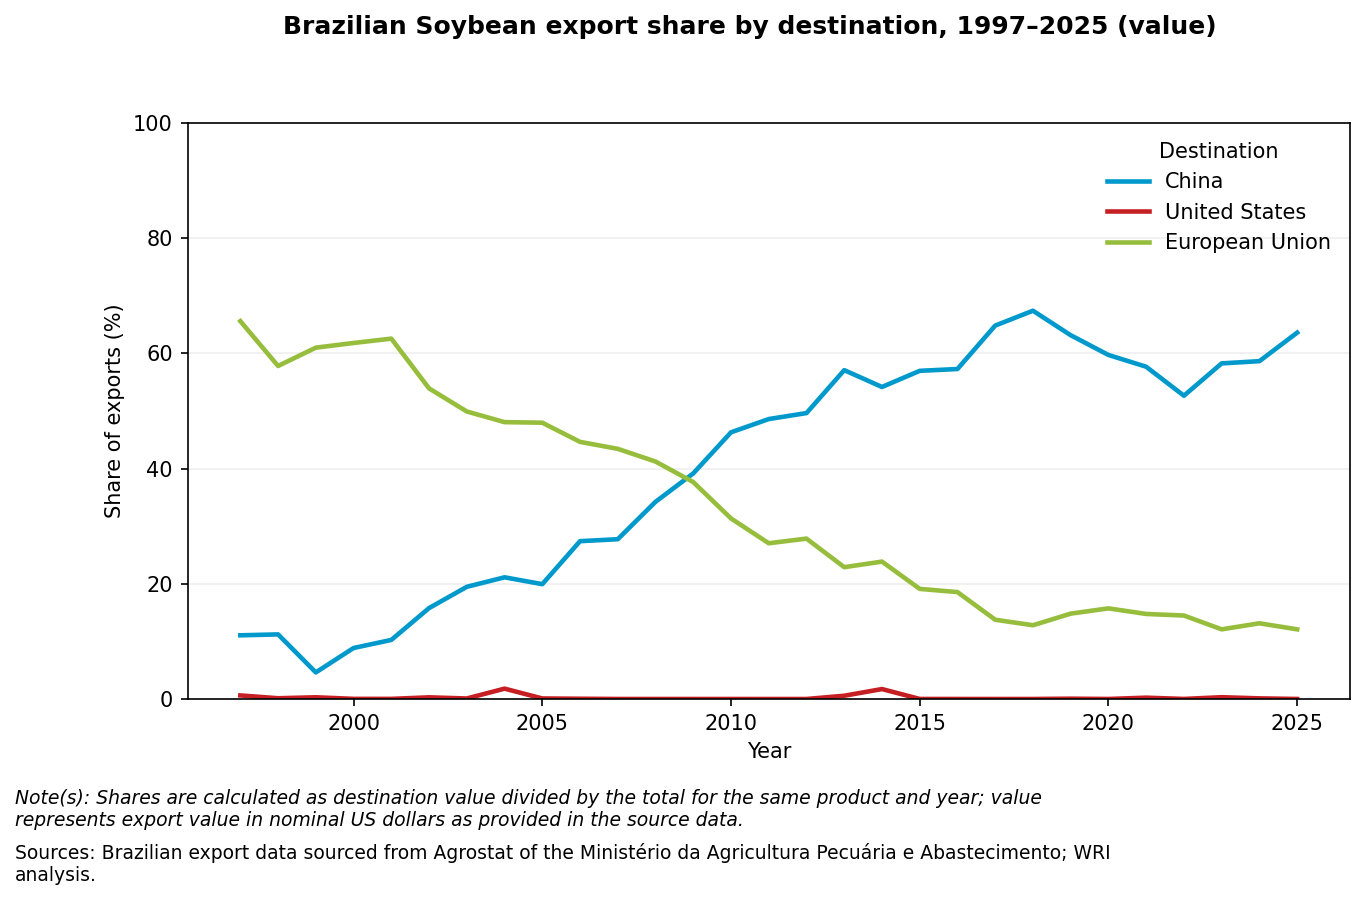

Saved: figures_brazil_exports\figure_01_soybean_value_share.png


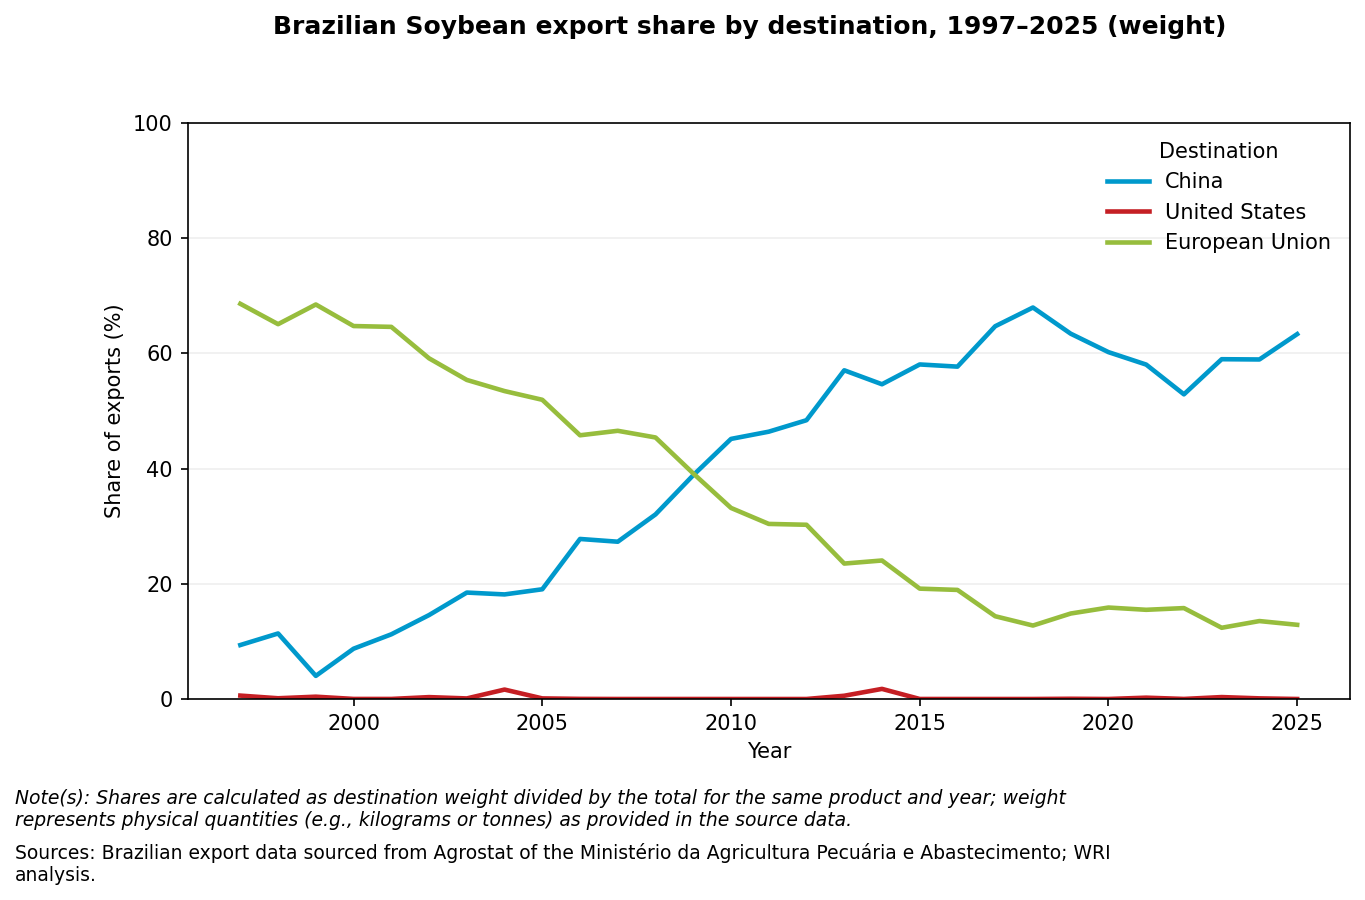

Saved: figures_brazil_exports\figure_02_soybean_weight_share.png


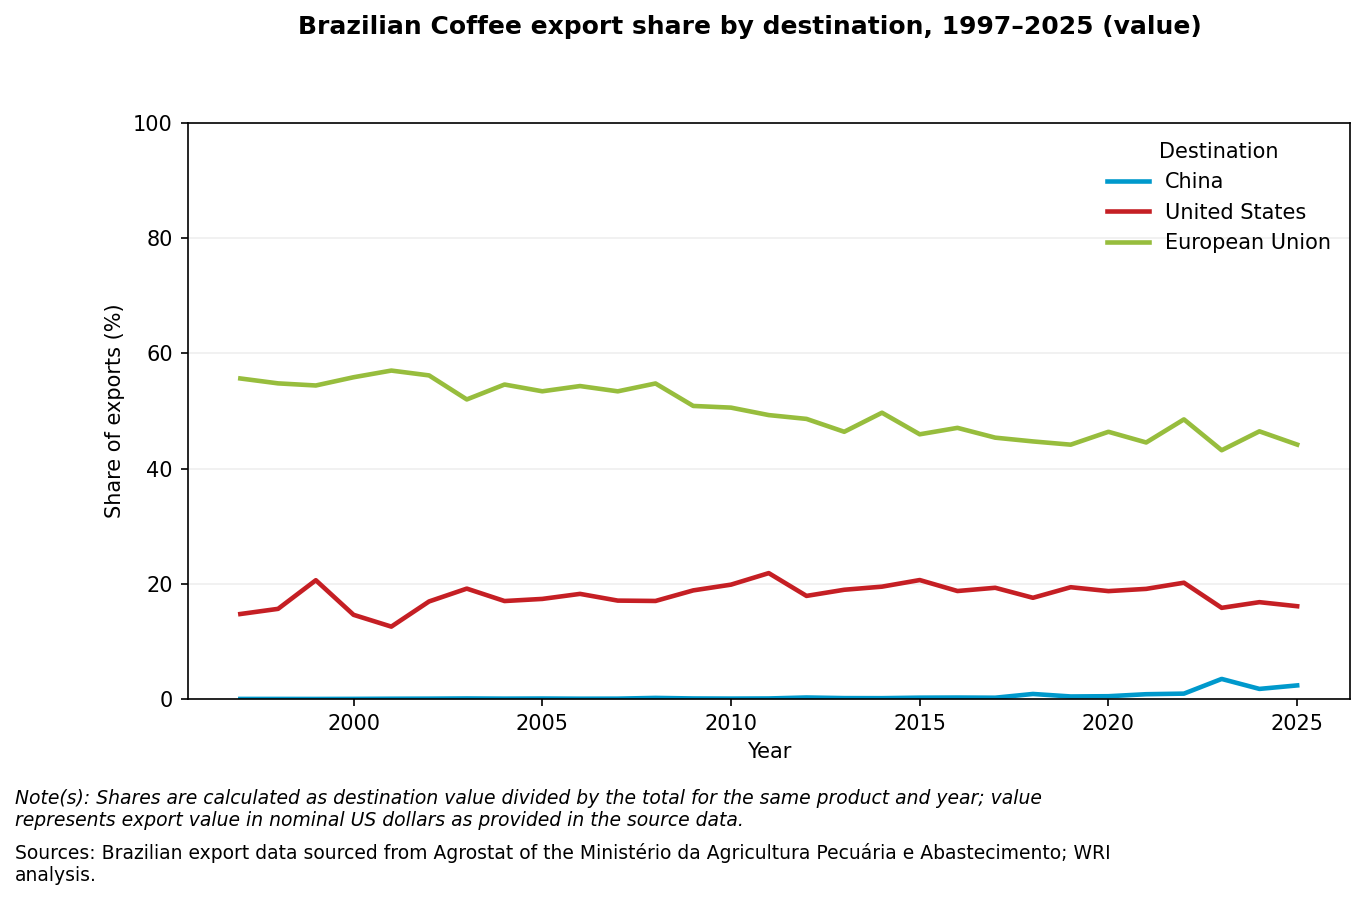

Saved: figures_brazil_exports\figure_03_coffee_value_share.png


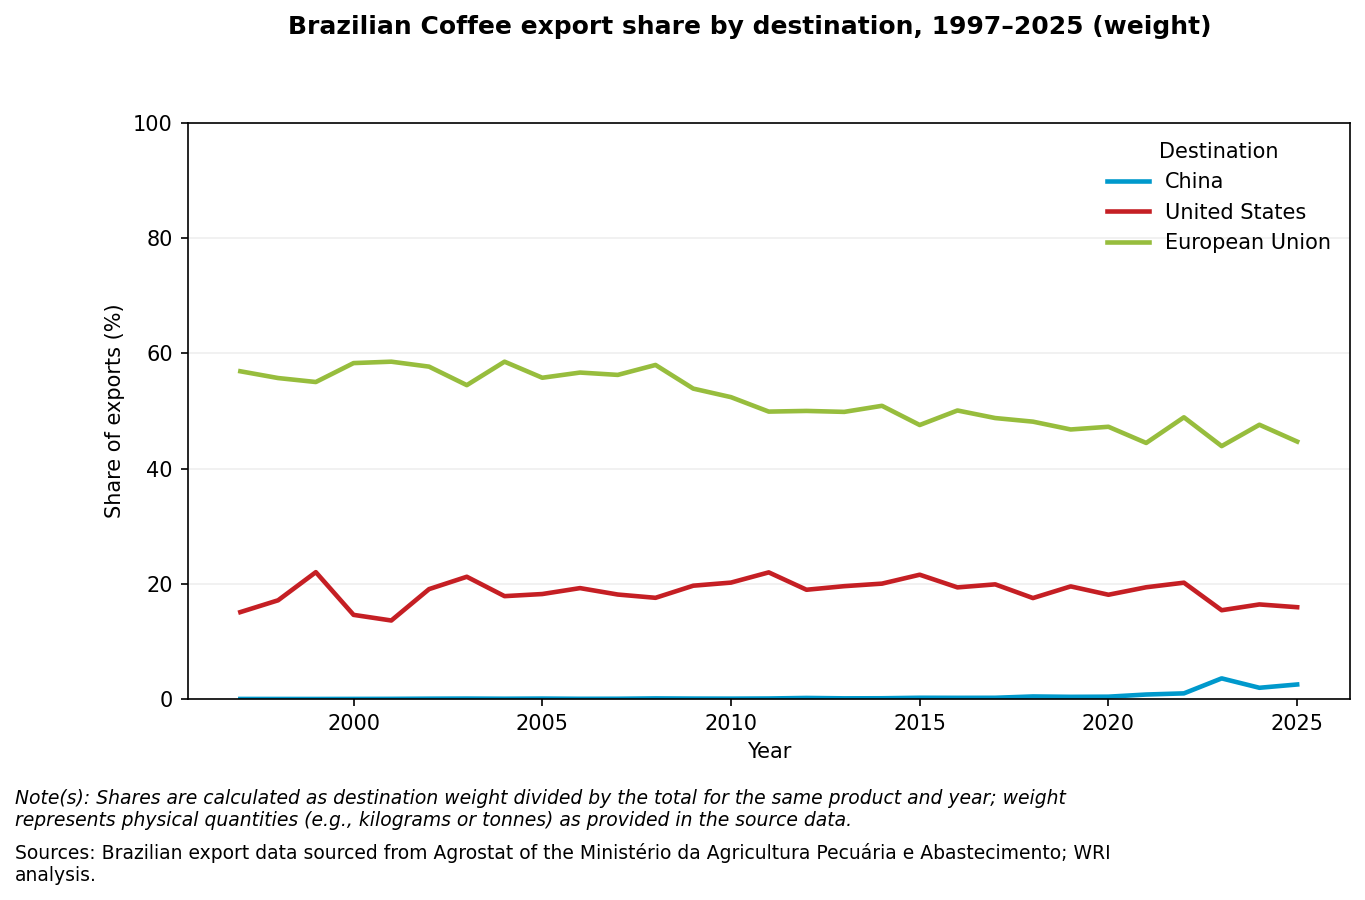

Saved: figures_brazil_exports\figure_04_coffee_weight_share.png


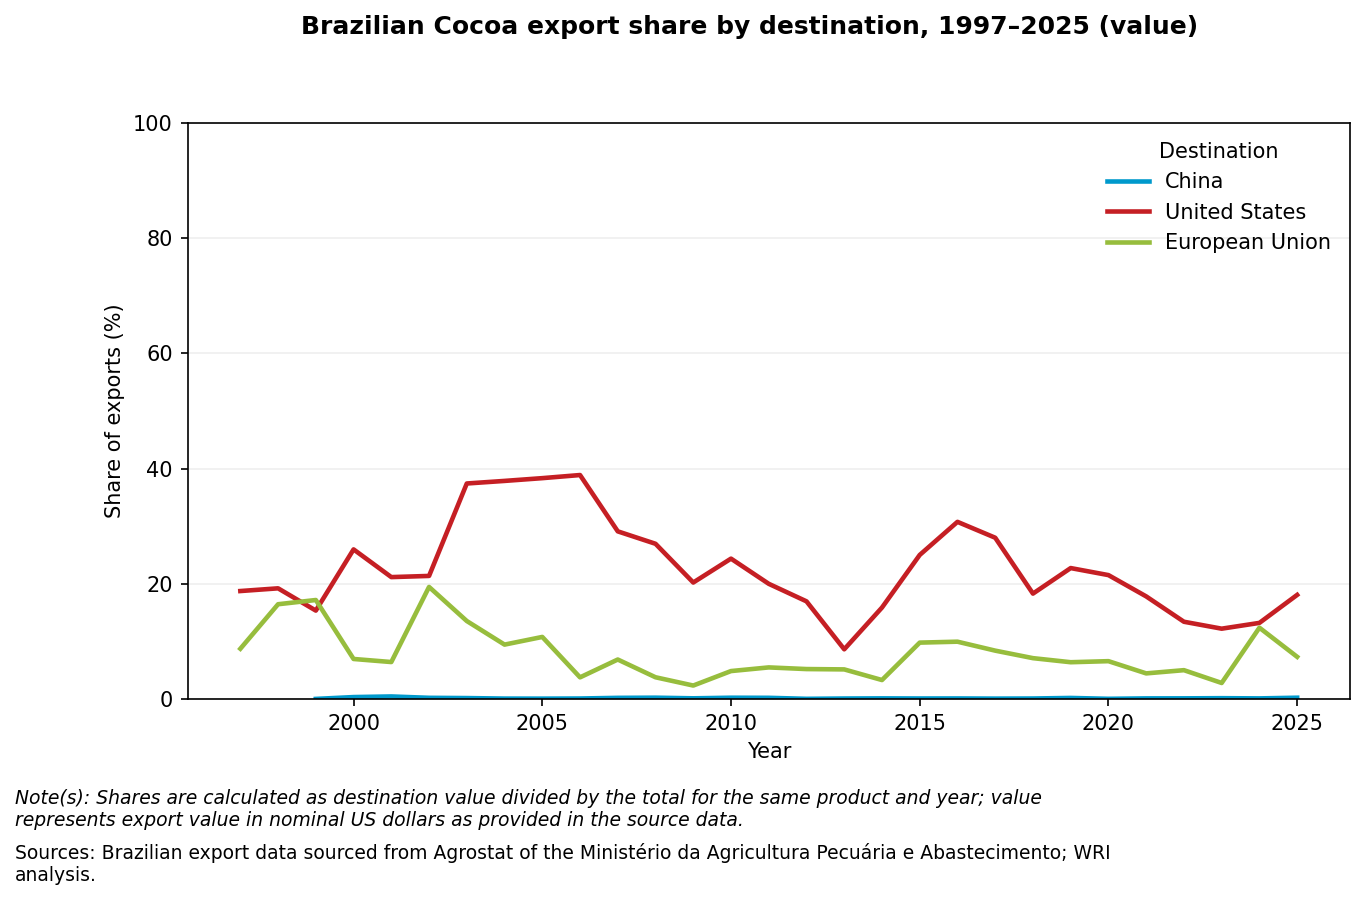

Saved: figures_brazil_exports\figure_05_cocoa_value_share.png


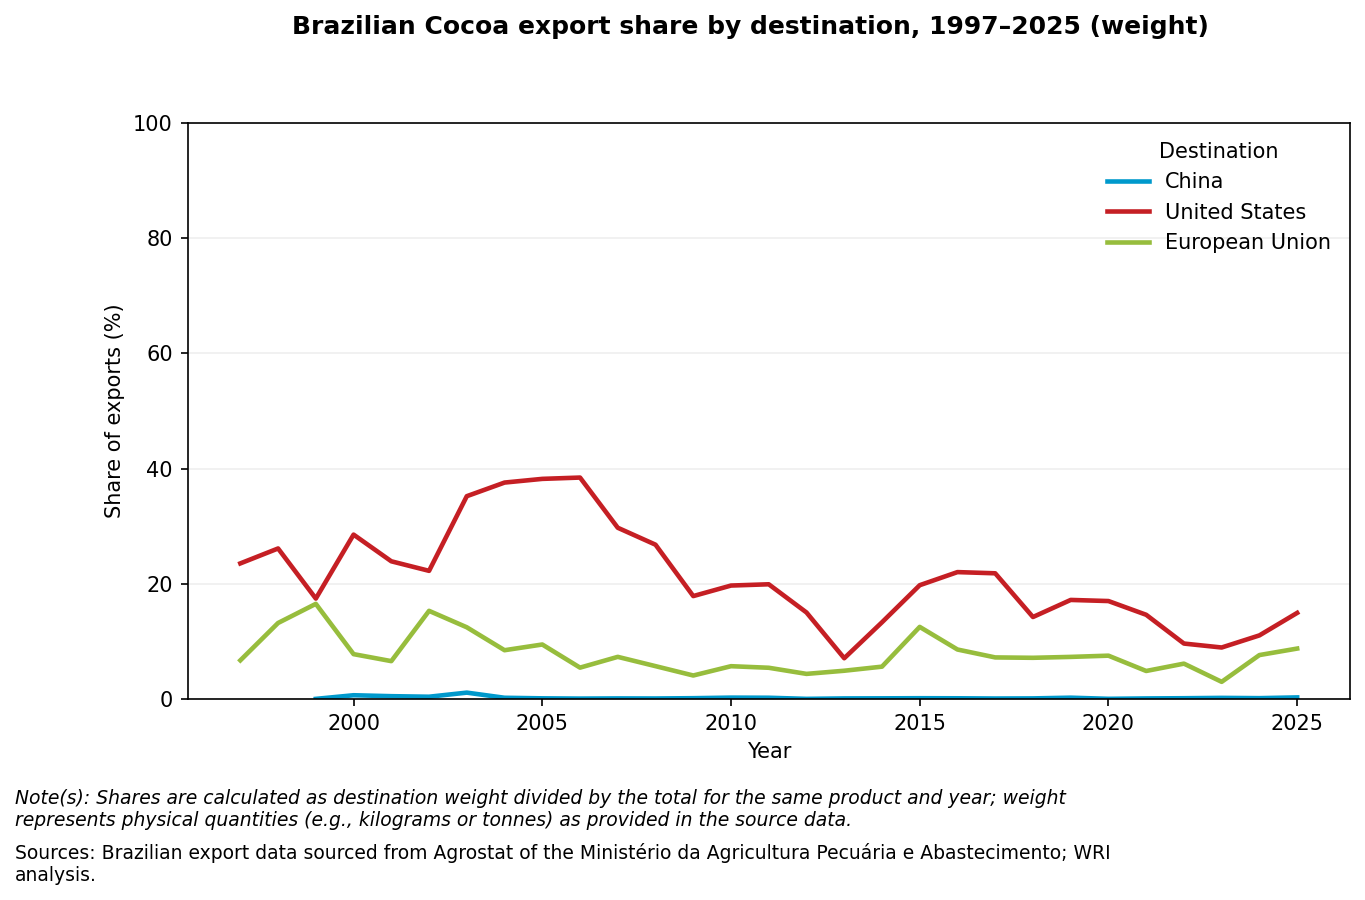

Saved: figures_brazil_exports\figure_06_cocoa_weight_share.png
Skipping Forest Products (value): No data available to plot for product=Forest Products, measure=value.
Skipping Forest Products (weight): No data available to plot for product=Forest Products, measure=weight.


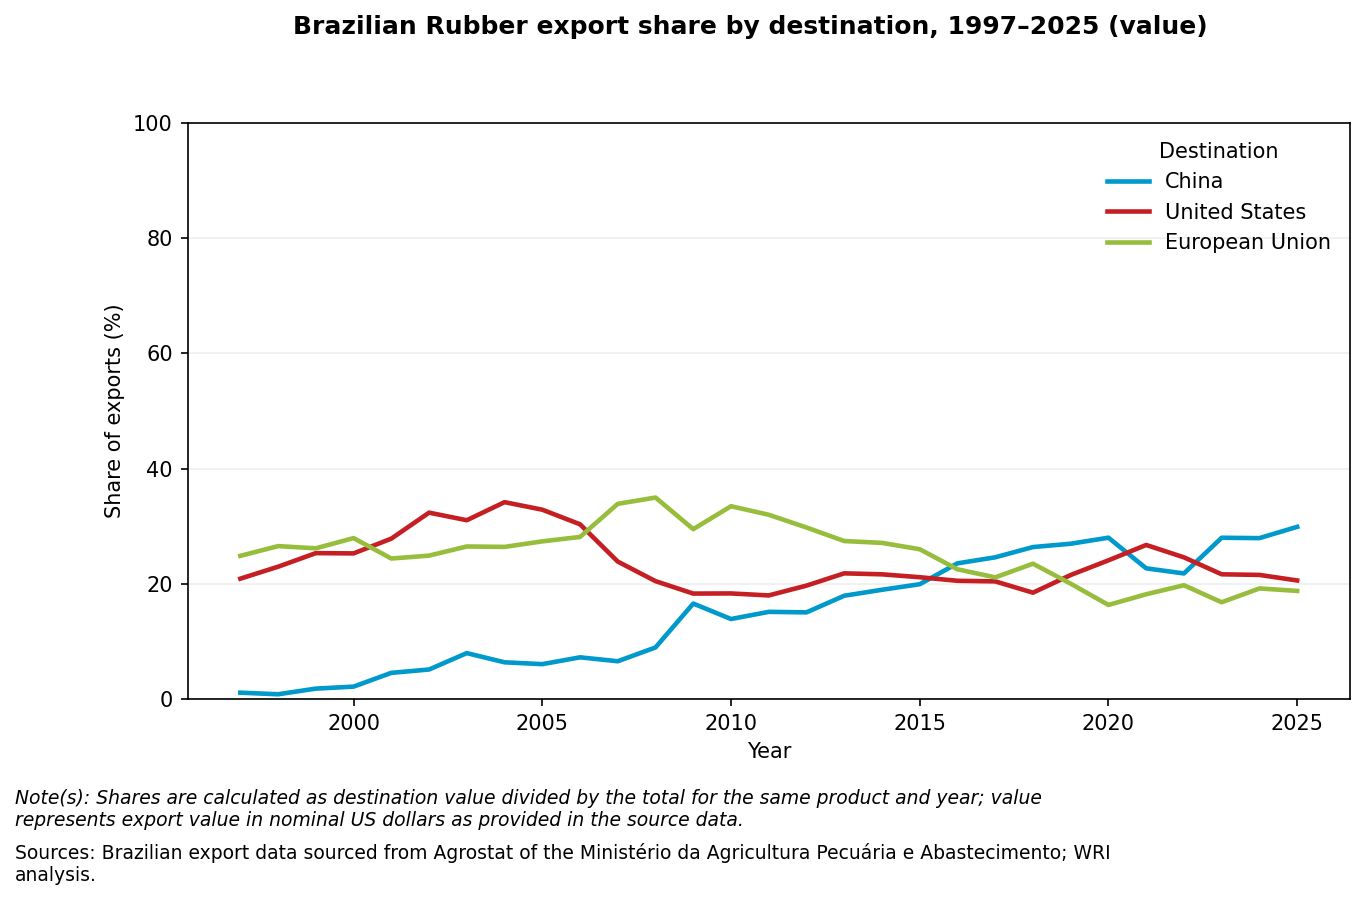

Saved: figures_brazil_exports\figure_07_rubber_value_share.png


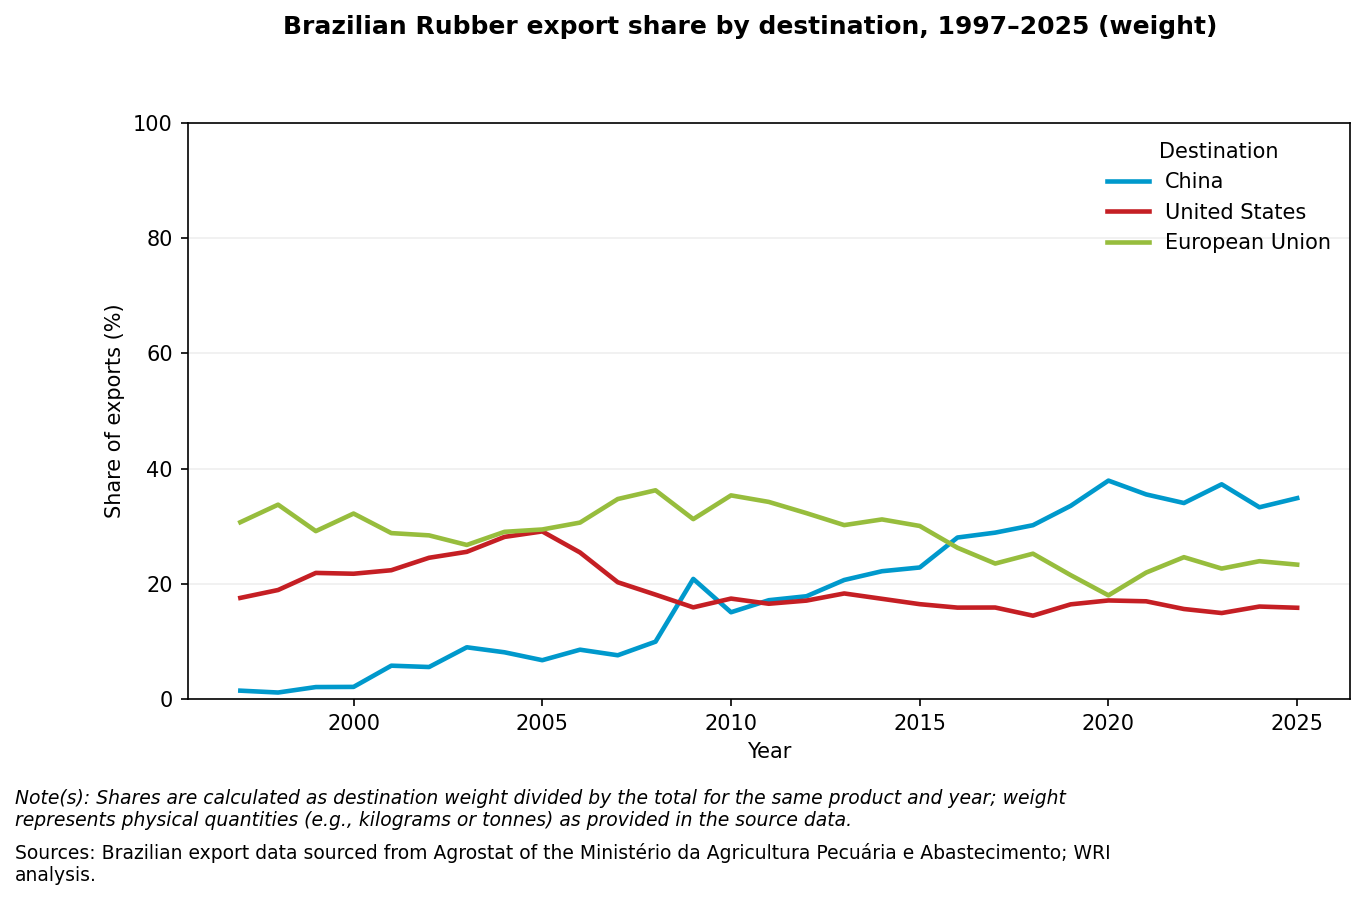

Saved: figures_brazil_exports\figure_08_rubber_weight_share.png


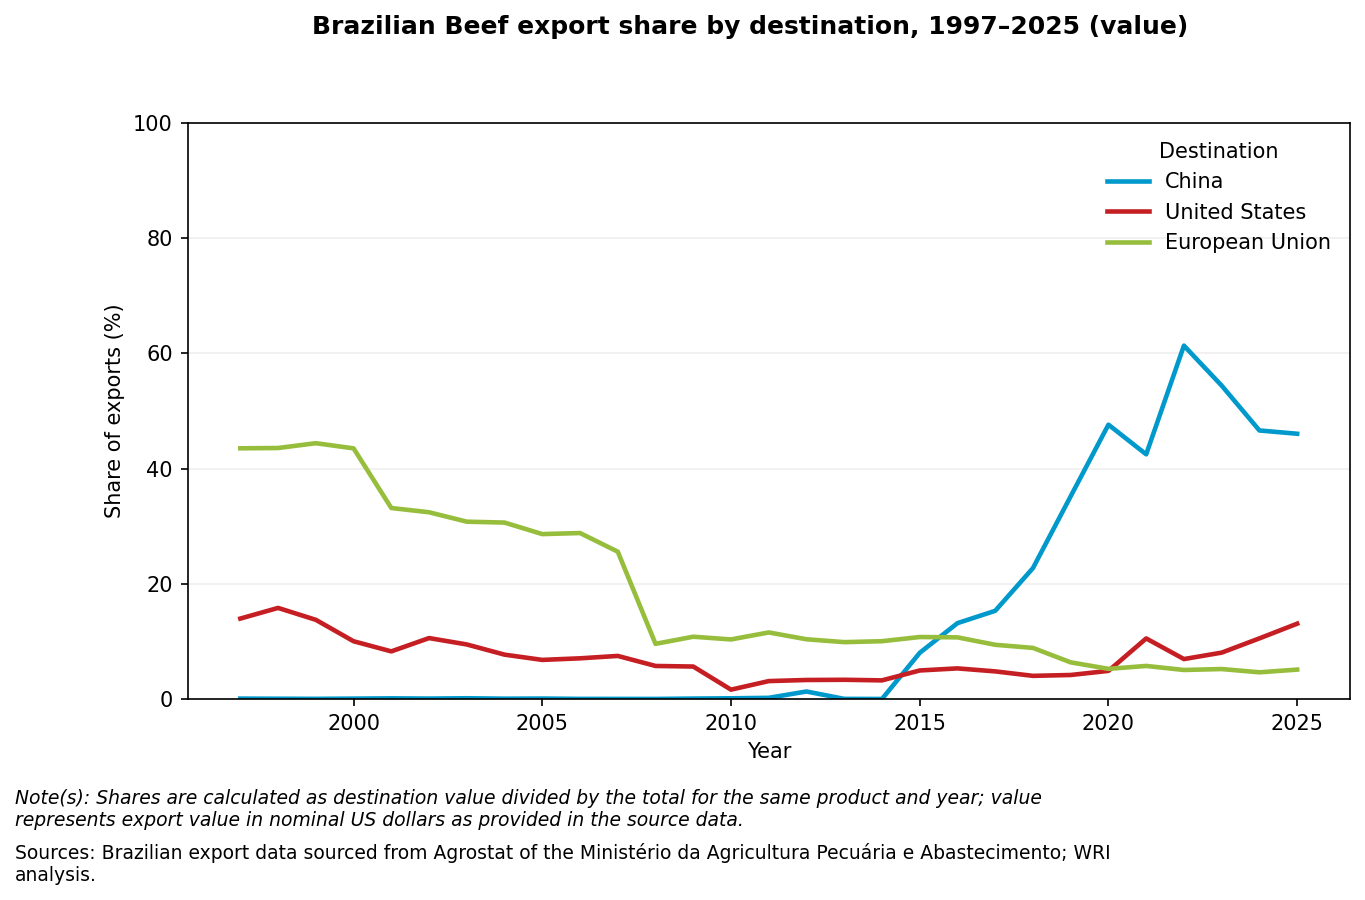

Saved: figures_brazil_exports\figure_09_beef_value_share.png


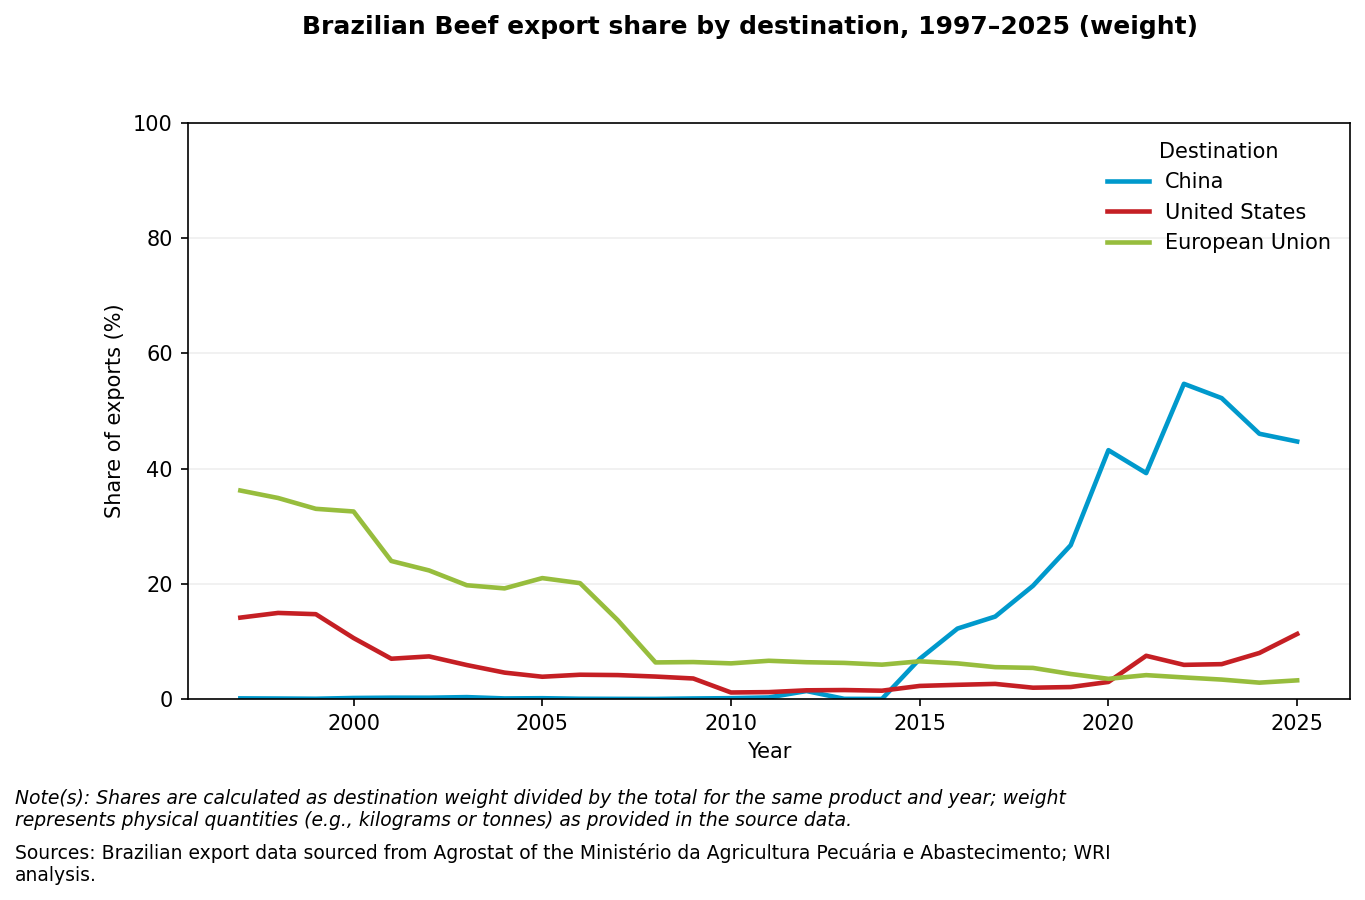

Saved: figures_brazil_exports\figure_10_beef_weight_share.png
Exported shares table: figures_brazil_exports\brazil_export_shares_1997_2025.csv


In [20]:
# JUPYTER NOTEBOOK CELL — 1997–2025, TWO-ROW HEADER, UNITED STATES INCLUDED
# UPDATED: map/rename all instances of "Timber" → "Rubber" and ADD "Beef" product charts

import os
import re
import math
import textwrap
from typing import List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# ------------------------------------------------------------------------------------
# 1) Configuration
# ------------------------------------------------------------------------------------

# Workbook path
EXCEL_PATH = r"D:\WRI\Field Boundaries\Tech Note\Agrostat - Brazil - EUDR Crop Exports\Brazil Commodity Exports 1997-2025.xlsx"
# If running in an environment where the file has been uploaded under /mnt/data, use this instead:
# EXCEL_PATH = r"/mnt/data/Brazil Commodity Exports 1997-2025.xlsx"

SHEET_NAME = 0  # change if your data are on another sheet

# Countries of interest and canonical names
COUNTRY_ALIASES = {
    "all": ["all", "total", "totals", "totais", "grand total"],
    "china": ["china"],
    "united states": ["united states", "usa", "u.s.a.", "u.s.", "us", "estados unidos", "united states of america", "eua"],
    "european union": ["european union", "eu", "ue 27", "ue27", "eu 27", "eu-27", "eu27", "ue"],
}

# Product (sector) canonical mapping — UPDATED to include Rubber (and map any "Timber" to Rubber) and Beef
PRODUCT_CANON = {
    "soybean": ["soy", "soja", "soybean", "soybeans", "complexo soja", "soj"],
    "coffee": ["coffee", "cafe", "café", "caf\u00e9", "cafê"],
    "cocoa": ["cocoa", "cacau", "cacao", "cocoa and products", "cocoa products"],
    "forest products": ["forest products", "forest", "produtos florestais", "madeira", "wood", "paper", "pulp", "celulose", "papel", "pulp & paper", "pulp and paper"],
    # New product: Rubber. Also treat any legacy "Timber" label as "Rubber" per instruction.
    "rubber": ["rubber", "latex", "hevea", "borracha", "timber"],
    # New product: Beef (common English/Portuguese variants)
    "beef": ["beef", "bovina", "bovino", "bovinos", "carne bovina", "bovine", "bovine meat", "carne de bovino", "carne bovina in natura"],
}

# Desired year span
YEAR_START = 1997
YEAR_END = 2025

# Colors for destination lines
COLOR_PALETTE = {
    "china": "#0099CC",
    "united states": "#C51F24",
    "european union": "#97BD3D",
    "unused": "#7D0063",
}

# Output figure directory (created if missing)
FIG_DIR = "figures_brazil_exports"
os.makedirs(FIG_DIR, exist_ok=True)

# ------------------------------------------------------------------------------------
# 2) Helpers for normalization and parsing
# ------------------------------------------------------------------------------------

def _ascii_lower(s: str) -> str:
    if s is None:
        return ""
    s = str(s)
    s = s.replace("Á","A").replace("À","A").replace("Â","A").replace("Ã","A").replace("Ä","A").replace("á","a").replace("à","a").replace("â","a").replace("ã","a").replace("ä","a")
    s = s.replace("É","E").replace("È","E").replace("Ê","E").replace("Ë","E").replace("é","e").replace("è","e").replace("ê","e").replace("ë","e")
    s = s.replace("Í","I").replace("Ì","I").replace("Î","I").replace("Ï","I").replace("í","i").replace("ì","i").replace("î","i").replace("ï","i")
    s = s.replace("Ó","O").replace("Ò","O").replace("Ô","O").replace("Õ","O").replace("Ö","O").replace("ó","o").replace("ò","o").replace("ô","o").replace("õ","o").replace("ö","o")
    s = s.replace("Ú","U").replace("Ù","U").replace("Û","U").replace("Ü","U").replace("ú","u").replace("ù","u").replace("û","u").replace("ü","u")
    s = s.replace("Ç","C").replace("ç","c")
    return s.lower().strip()

def parse_year(x) -> Optional[int]:
    if x is None:
        return None
    s = str(x)
    m = re.search(r"(19|20)\d{2}", s)
    if m:
        return int(m.group(0))
    return None

def is_value_measure(name: str) -> bool:
    s = _ascii_lower(name)
    return any(k in s for k in ["value", "valor", "us$", "usd", "dollar", "d\u00f3lar", "dolar"])

def is_weight_measure(name: str) -> bool:
    s = _ascii_lower(name)
    return any(k in s for k in ["weight", "volume", "peso", "kg", "ton", "tonne", "tonnes"])

def is_country_header(name: str) -> bool:
    s = _ascii_lower(name)
    return any(k in s for k in ["country", "pa\u00eds", "pais", "bloco", "país"])

def is_product_header(name: str) -> bool:
    s = _ascii_lower(name)
    return any(k in s for k in ["product", "setor", "produto", "sector"])

def canon_country(name: str) -> Optional[str]:
    s = _ascii_lower(name)
    if s in {"eu", "ue", "eu-27", "eu27", "eu 27", "ue27", "ue 27"} or "european union" in s:
        return "European Union"
    if any(v in s for v in COUNTRY_ALIASES["china"]):
        return "China"
    if any(v in s for v in COUNTRY_ALIASES["united states"]):
        return "United States"
    if any(v in s for v in COUNTRY_ALIASES["all"]):
        return "All"
    return None

def canon_product(name: str) -> Optional[str]:
    s = _ascii_lower(name)
    for canon, variants in PRODUCT_CANON.items():
        for v in variants:
            if v in s:
                return {
                    "soybean": "Soybean",
                    "coffee": "Coffee",
                    "cocoa": "Cocoa",
                    "forest products": "Forest Products",
                    "rubber": "Rubber",
                    "beef": "Beef",
                }[canon]
    return None

def to_number(x) -> Optional[float]:
    if x is None or (isinstance(x, float) and math.isnan(x)):
        return None
    if isinstance(x, (int, float, np.integer, np.floating)):
        return float(x)
    s = str(x).strip().replace(",", "").replace("\u00a0", "").replace(" ", "")
    try:
        return float(s)
    except Exception:
        return None

# ------------------------------------------------------------------------------------
# 3) Load and transform to long/tidy format (two-row header: years on row 1, labels on row 2)
# ------------------------------------------------------------------------------------

def load_wide_table(path: str, sheet_name=0) -> pd.DataFrame:
    df = pd.read_excel(path, sheet_name=sheet_name, header=[0, 1], dtype=object)

    # Normalize the column MultiIndex:
    norm_cols = []
    for col in df.columns:
        if isinstance(col, tuple) and len(col) == 2:
            top, bottom = col
            top_clean = None if (top is None or (isinstance(top, float) and pd.isna(top)) or str(top).lower().startswith("unnamed")) else top
            bottom_clean = str(bottom).strip()
            norm_cols.append((top_clean, bottom_clean))
        else:
            norm_cols.append((None, str(col).strip()))
    df.columns = pd.MultiIndex.from_tuples(norm_cols)
    return df

def _first_column_key_with_bottom(df_multi: pd.DataFrame, bottom_label: str) -> Optional[Tuple[object, str]]:
    target = _ascii_lower(bottom_label)
    candidates = [c for c in df_multi.columns if _ascii_lower(c[1]) == target]
    if not candidates:
        return None
    for c in candidates:
        if c[0] is None:
            return c
    return candidates[0]

def find_id_columns(df_multi: pd.DataFrame) -> Tuple[Tuple[object, str], Tuple[object, str]]:
    country_key = None
    product_key = None
    for top, bottom in df_multi.columns:
        if is_country_header(bottom) and country_key is None:
            country_key = _first_column_key_with_bottom(df_multi, bottom)
        if is_product_header(bottom) and product_key is None:
            product_key = _first_column_key_with_bottom(df_multi, bottom)
    if country_key is None or product_key is None:
        cols = list(df_multi.columns)
        if len(cols) < 2:
            raise ValueError("Could not infer 'country' and 'product' columns.")
        country_key = cols[0] if country_key is None else country_key
        product_key = cols[1] if product_key is None else product_key
    return country_key, product_key

def melt_to_long(df_multi: pd.DataFrame) -> pd.DataFrame:
    country_key, product_key = find_id_columns(df_multi)

    value_cols: List[Tuple[Tuple[object, str], int]] = []
    weight_cols: List[Tuple[Tuple[object, str], int]] = []
    for (top, bottom) in df_multi.columns:
        y = parse_year(top)
        if y is None:
            continue
        if is_value_measure(bottom):
            value_cols.append(((top, bottom), y))
        elif is_weight_measure(bottom):
            weight_cols.append(((top, bottom), y))

    if not value_cols and not weight_cols:
        raise ValueError("No value/weight measure columns were detected. Please check header rows.")

    id_df = pd.DataFrame({
        "country": df_multi[country_key],
        "product": df_multi[product_key],
    })

    long_frames = []
    if value_cols:
        df_val = id_df.copy()
        for (key, y) in value_cols:
            df_val[y] = df_multi[key]
        dfm = df_val.melt(id_vars=["country", "product"], var_name="year", value_name="amount")
        dfm["measure"] = "value"
        long_frames.append(dfm)

    if weight_cols:
        df_wt = id_df.copy()
        for (key, y) in weight_cols:
            df_wt[y] = df_multi[key]
        dfm2 = df_wt.melt(id_vars=["country", "product"], var_name="year", value_name="amount")
        dfm2["measure"] = "weight"
        long_frames.append(dfm2)

    long_df = pd.concat(long_frames, ignore_index=True)
    long_df["year"] = pd.to_numeric(long_df["year"], errors="coerce").astype("Int64")
    long_df["amount"] = long_df["amount"].apply(to_number)
    long_df = long_df.dropna(subset=["year", "amount"]).copy()

    # Rename all instances of "Timber" to "Rubber" in the raw product labels (exact word)
    long_df["product"] = long_df["product"].astype(str).str.replace(r"(?i)\btimber\b", "Rubber", regex=True)

    # Canonicalize product and country
    long_df["product_canon"] = long_df["product"].apply(canon_product)
    long_df["country_canon"] = long_df["country"].apply(canon_country)

    # Keep requested products (now includes Rubber and Beef)
    keep_products = ["Soybean", "Coffee", "Cocoa", "Forest Products", "Rubber", "Beef"]
    long_df = long_df[long_df["product_canon"].isin(keep_products)].copy()
    long_df = long_df[long_df["country_canon"].isin(["All", "China", "United States", "European Union"])].copy()

    long_df = long_df[(long_df["year"] >= YEAR_START) & (long_df["year"] <= YEAR_END)].copy()

    long_df = long_df[["country_canon", "product_canon", "year", "measure", "amount"]].rename(
        columns={"country_canon": "country", "product_canon": "product"}
    ).reset_index(drop=True)

    return long_df

def compute_share_percent(long_df: pd.DataFrame) -> pd.DataFrame:
    all_df = long_df[long_df["country"] == "All"][["product", "year", "measure", "amount"]].rename(columns={"amount": "total_amount"})
    merged = long_df.merge(all_df, on=["product", "year", "measure"], how="left", validate="m:1")
    merged["share_pct"] = (merged["amount"] / merged["total_amount"]) * 100.0
    out = merged[merged["country"].isin(["China", "United States", "European Union"])].copy()
    out = out.replace([np.inf, -np.inf], np.nan).dropna(subset=["share_pct"])
    return out[["country", "product", "year", "measure", "share_pct"]].reset_index(drop=True)

# ------------------------------------------------------------------------------------
# 4) Plotting with WRI figure style (title without numbering; commodity first letter capitalized)
# ------------------------------------------------------------------------------------

def sentence_case(s: str) -> str:
    s = str(s).strip()
    return s[:1].upper() + s[1:].lower() if s else s

def wrap_text(s: str, width: int = 100) -> str:
    return "\n".join(textwrap.wrap(s, width=width, break_long_words=False))

def plot_share_lines(
    df_share: pd.DataFrame,
    product: str,
    measure: str,
    figure_number: int,   # used in filename only (titles have no figure numbers)
    note_text: str,
    source_text: str,
    save_dir: str = FIG_DIR
) -> str:
    sub = df_share[(df_share["product"] == product) & (df_share["measure"] == measure)].copy()
    if sub.empty:
        raise ValueError(f"No data available to plot for product={product}, measure={measure}.")

    pivot = sub.pivot_table(index="year", columns="country", values="share_pct", aggfunc="mean").sort_index()
    ordered_countries = ["China", "United States", "European Union"]
    pivot = pivot.reindex(columns=ordered_countries)

    measure_label = "value" if measure == "value" else "weight"
    product_cap = product[:1].upper() + product[1:].lower()
    title = f"Brazilian {product_cap} export share by destination, {YEAR_START}–{YEAR_END} ({measure_label})"

    fig, ax = plt.subplots(figsize=(10, 6), dpi=150)

    for c in ordered_countries:
        if c in pivot.columns:
            ax.plot(pivot.index, pivot[c], label=c, linewidth=2.2, color=COLOR_PALETTE[_ascii_lower(c)])

    ax.set_xlabel("Year")
    ax.set_ylabel("Share of exports (%)")
    ymax = np.nanmax(pivot.values)
    if np.isnan(ymax):
        ymax = 100
    ax.set_ylim(0, max(100, math.ceil(ymax / 10.0) * 10))
    ax.yaxis.set_major_locator(MaxNLocator(integer=True, nbins=6))
    ax.grid(True, axis="y", alpha=0.2, linewidth=0.8)
    ax.legend(title=sentence_case("destination"), frameon=False)

    plt.suptitle(title, fontsize=12, fontweight="bold", y=0.98)

    note_text = wrap_text(note_text, width=110)
    source_text = wrap_text(source_text, width=110)
    plt.subplots_adjust(top=0.86, bottom=0.22)
    fig.text(0.01, 0.12, f"Note(s): {note_text}", ha="left", va="top", fontsize=9, style="italic")
    fig.text(0.01, 0.06, f"Sources: {source_text}", ha="left", va="top", fontsize=9)

    safe_prod = product.lower().replace(" ", "_")
    outpath = os.path.join(save_dir, f"figure_{figure_number:02d}_{safe_prod}_{measure_label}_share.png")
    plt.savefig(outpath, bbox_inches="tight")
    plt.show()

    return outpath

# ------------------------------------------------------------------------------------
# 5) Run: load, transform, compute shares, and generate charts (now including Rubber and Beef)
# ------------------------------------------------------------------------------------

df_wide = load_wide_table(EXCEL_PATH, sheet_name=SHEET_NAME)
df_long = melt_to_long(df_wide)
df_share = compute_share_percent(df_long)

available_years = sorted(df_share["year"].dropna().unique().tolist())
print("Available years in the dataset:", available_years)

# Include Rubber and Beef in the chart list
products_to_plot = ["Soybean", "Coffee", "Cocoa", "Forest Products", "Rubber", "Beef"]
measures_to_plot = ["value", "weight"]

NOTE_VALUE = (
    "Shares are calculated as destination value divided by the total for the same product and year; "
    "value represents export value in nominal US dollars as provided in the source data."
)
NOTE_WEIGHT = (
    "Shares are calculated as destination weight divided by the total for the same product and year; "
    "weight represents physical quantities (e.g., kilograms or tonnes) as provided in the source data."
)
SOURCES = "Brazilian export data sourced from Agrostat of the Ministério da Agricultura Pecuária e Abastecimento; WRI analysis."

figure_counter = 1
saved_files: List[str] = []

for prod in products_to_plot:
    for meas in measures_to_plot:
        note = NOTE_VALUE if meas == "value" else NOTE_WEIGHT
        try:
            outpng = plot_share_lines(
                df_share=df_share,
                product=prod,
                measure=meas,
                figure_number=figure_counter,  # numbering retained in filenames only
                note_text=note,
                source_text=SOURCES,
                save_dir=FIG_DIR
            )
            saved_files.append(outpng)
            print(f"Saved: {outpng}")
            figure_counter += 1
        except ValueError as e:
            print(f"Skipping {prod} ({meas}): {e}")

# Optional: export the long-format shares table (1997–2025) to CSV
shares_csv_path = os.path.join(FIG_DIR, "brazil_export_shares_1997_2025.csv")
df_share.sort_values(["product", "measure", "country", "year"]).to_csv(shares_csv_path, index=False)
print(f"Exported shares table: {shares_csv_path}")


Sectors 1997 - 2025, beef and rubber added, VOLUME rather than percentages by commodity type

Available years in the dataset: [1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


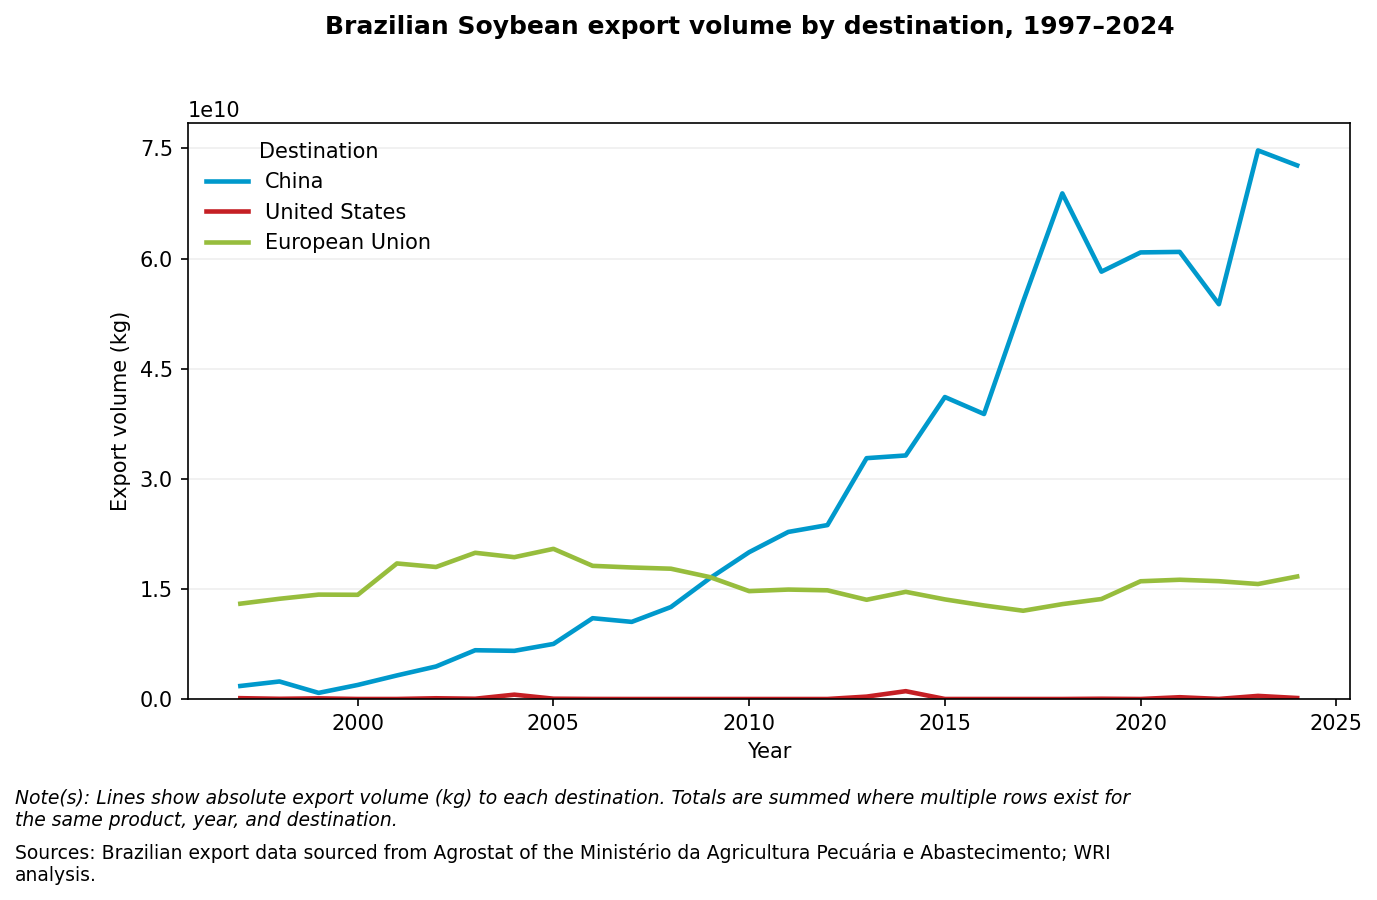

Saved: figures_brazil_exports_volume\volume_01_soybean_by_destination.png


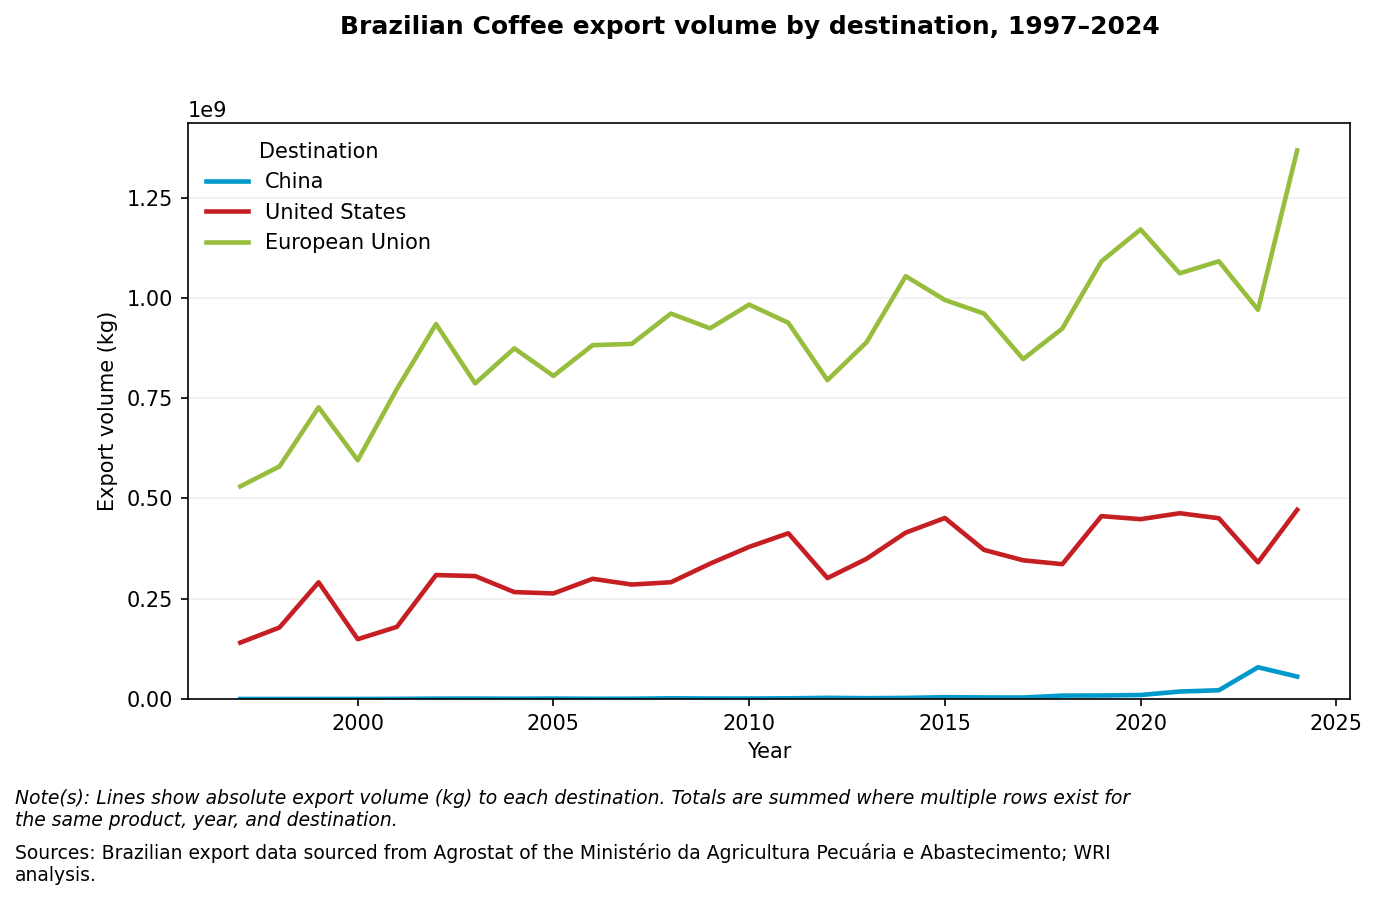

Saved: figures_brazil_exports_volume\volume_02_coffee_by_destination.png


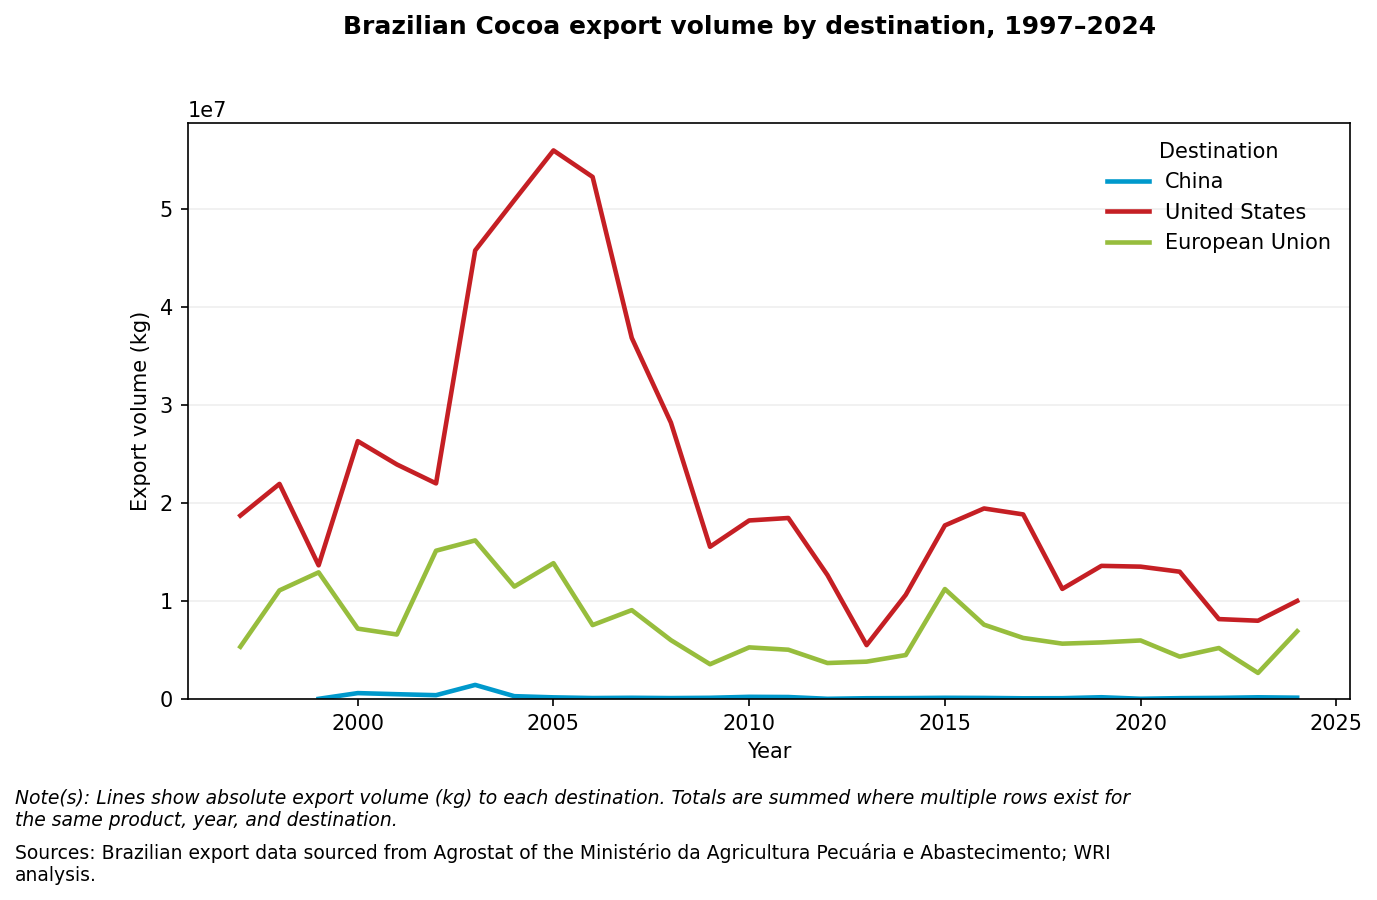

Saved: figures_brazil_exports_volume\volume_03_cocoa_by_destination.png
Skipping Forest Products: No volume data available to plot for product=Forest Products.


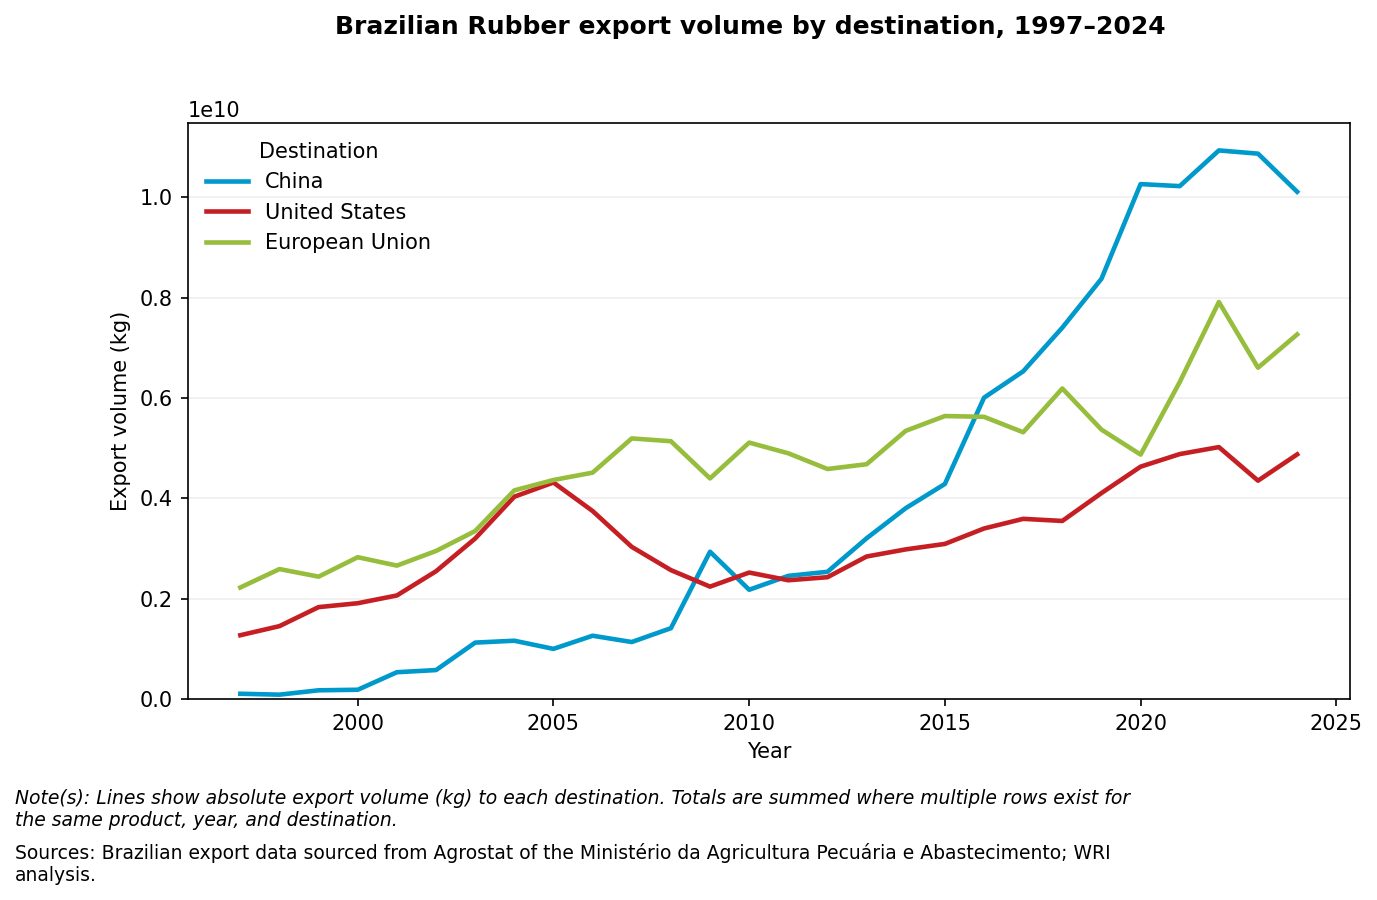

Saved: figures_brazil_exports_volume\volume_04_rubber_by_destination.png


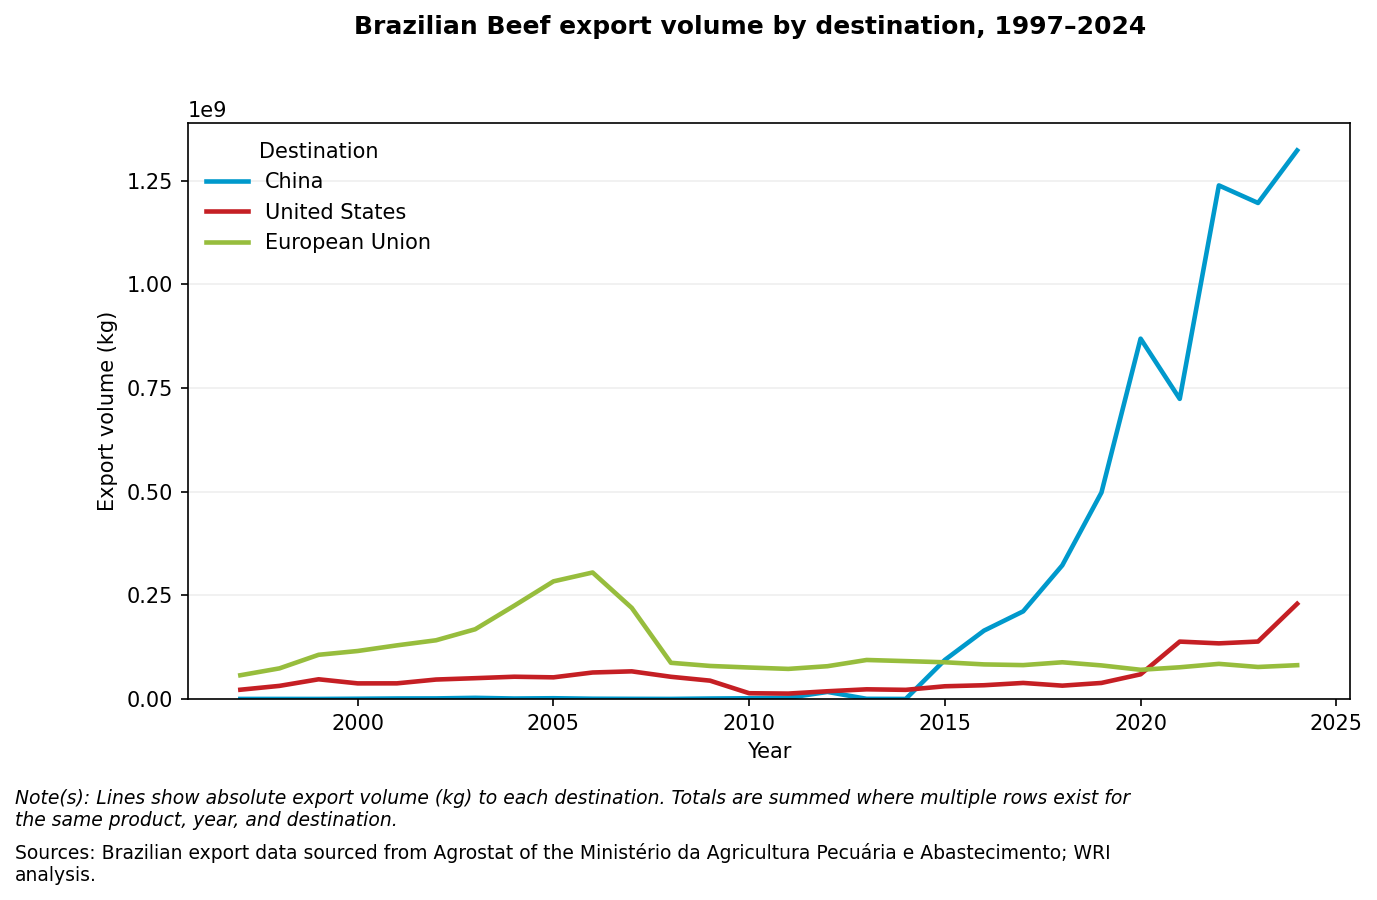

Saved: figures_brazil_exports_volume\volume_05_beef_by_destination.png
Exported volume table: figures_brazil_exports_volume\brazil_export_volumes_1997_2025.csv


In [18]:
# JUPYTER NOTEBOOK CELL — 1997–2025, TWO-ROW HEADER
# OVERALL EXPORT VOLUME (no percentages) BY DESTINATION FOR EACH CROP
# (China, United States, European Union lines shown for each product; y-axis = volume in kg)

import os
import re
import math
import textwrap
from typing import List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# ------------------------------------------------------------------------------------
# 1) Configuration
# ------------------------------------------------------------------------------------

# Workbook path
EXCEL_PATH = r"D:\WRI\Field Boundaries\Tech Note\Agrostat - Brazil - EUDR Crop Exports\Brazil Commodity Exports 1997-2025.xlsx"
# If running in an environment where the file has been uploaded under /mnt/data, use this instead:
# EXCEL_PATH = r"/mnt/data/Brazil Commodity Exports 1997-2025.xlsx"

SHEET_NAME = 0  # change if your data are on another sheet

# Countries of interest and canonical names
COUNTRY_ALIASES = {
    "all": ["all", "total", "totals", "totais", "grand total"],
    "china": ["china"],
    "united states": ["united states", "usa", "u.s.a.", "u.s.", "us", "estados unidos", "united states of america", "eua"],
    "european union": ["european union", "eu", "ue 27", "ue27", "eu 27", "eu-27", "eu27", "ue"],
}

# Product (sector) canonical mapping — includes Rubber (maps legacy "Timber"→Rubber) and Beef
PRODUCT_CANON = {
    "soybean": ["soy", "soja", "soybean", "soybeans", "complexo soja", "soj"],
    "coffee": ["coffee", "cafe", "café", "caf\u00e9", "cafê"],
    "cocoa": ["cocoa", "cacau", "cacao", "cocoa and products", "cocoa products"],
    "forest products": ["forest products", "forest", "produtos florestais", "madeira", "wood", "paper", "pulp", "celulose", "papel", "pulp & paper", "pulp and paper"],
    "rubber": ["rubber", "latex", "hevea", "borracha", "timber"],  # <- map any "Timber" to Rubber
    "beef": ["beef", "bovina", "bovino", "bovinos", "carne bovina", "bovine", "bovine meat", "carne de bovino", "carne bovina in natura"],
}

# Desired year span
YEAR_START = 1997
YEAR_END = 2024

# Line colors (must be from approved palette)
# Using three from your list: China=#0099CC, United States=#C51F24, EU=#97BD3D
COLOR_PALETTE = {
    "china": "#0099CC",
    "united states": "#C51F24",
    "european union": "#97BD3D",
    "unused": "#7D0063",
}

# Output figure directory (created if missing)
FIG_DIR = "figures_brazil_exports_volume"
os.makedirs(FIG_DIR, exist_ok=True)

# ------------------------------------------------------------------------------------
# 2) Helpers for normalization and parsing
# ------------------------------------------------------------------------------------

def _ascii_lower(s: str) -> str:
    if s is None:
        return ""
    s = str(s)
    s = s.replace("Á","A").replace("À","A").replace("Â","A").replace("Ã","A").replace("Ä","A").replace("á","a").replace("à","a").replace("â","a").replace("ã","a").replace("ä","a")
    s = s.replace("É","E").replace("È","E").replace("Ê","E").replace("Ë","E").replace("é","e").replace("è","e").replace("ê","e").replace("ë","e")
    s = s.replace("Í","I").replace("Ì","I").replace("Î","I").replace("Ï","I").replace("í","i").replace("ì","i").replace("î","i").replace("ï","i")
    s = s.replace("Ó","O").replace("Ò","O").replace("Ô","O").replace("Õ","O").replace("Ö","O").replace("ó","o").replace("ò","o").replace("ô","o").replace("õ","o").replace("ö","o")
    s = s.replace("Ú","U").replace("Ù","U").replace("Û","U").replace("Ü","U").replace("ú","u").replace("ù","u").replace("û","u").replace("ü","u")
    s = s.replace("Ç","C").replace("ç","c")
    return s.lower().strip()

def parse_year(x) -> Optional[int]:
    if x is None:
        return None
    s = str(x)
    m = re.search(r"(19|20)\d{2}", s)
    if m:
        return int(m.group(0))
    return None

def is_value_measure(name: str) -> bool:
    s = _ascii_lower(name)
    return any(k in s for k in ["value", "valor", "us$", "usd", "dollar", "d\u00f3lar", "dolar"])

def is_weight_measure(name: str) -> bool:
    s = _ascii_lower(name)
    return any(k in s for k in ["weight", "volume", "peso", "kg", "ton", "tonne", "tonnes"])

def is_country_header(name: str) -> bool:
    s = _ascii_lower(name)
    return any(k in s for k in ["country", "pa\u00eds", "pais", "bloco", "país"])

def is_product_header(name: str) -> bool:
    s = _ascii_lower(name)
    return any(k in s for k in ["product", "setor", "produto", "sector"])

def canon_country(name: str) -> Optional[str]:
    s = _ascii_lower(name)
    if s in {"eu", "ue", "eu-27", "eu27", "eu 27", "ue27", "ue 27"} or "european union" in s:
        return "European Union"
    if any(v in s for v in COUNTRY_ALIASES["china"]):
        return "China"
    if any(v in s for v in COUNTRY_ALIASES["united states"]):
        return "United States"
    if any(v in s for v in COUNTRY_ALIASES["all"]):
        return "All"
    return None

def canon_product(name: str) -> Optional[str]:
    s = _ascii_lower(name)
    # enforce Timber→Rubber replacement before mapping
    s = re.sub(r"\btimber\b", "rubber", s, flags=re.IGNORECASE)
    for canon, variants in PRODUCT_CANON.items():
        for v in variants:
            if v in s:
                return {
                    "soybean": "Soybean",
                    "coffee": "Coffee",
                    "cocoa": "Cocoa",
                    "forest products": "Forest Products",
                    "rubber": "Rubber",
                    "beef": "Beef",
                }[canon]
    return None

def to_number(x) -> Optional[float]:
    if x is None or (isinstance(x, float) and math.isnan(x)):
        return None
    if isinstance(x, (int, float, np.integer, np.floating)):
        return float(x)
    s = str(x).strip().replace(",", "").replace("\u00a0", "").replace(" ", "")
    try:
        return float(s)
    except Exception:
        return None

# ------------------------------------------------------------------------------------
# 3) Load and transform to long/tidy format (two-row header: years on row 1, labels on row 2)
# ------------------------------------------------------------------------------------

def load_wide_table(path: str, sheet_name=0) -> pd.DataFrame:
    df = pd.read_excel(path, sheet_name=sheet_name, header=[0, 1], dtype=object)

    # Normalize the column MultiIndex:
    norm_cols = []
    for col in df.columns:
        if isinstance(col, tuple) and len(col) == 2:
            top, bottom = col
            top_clean = None if (top is None or (isinstance(top, float) and pd.isna(top)) or str(top).lower().startswith("unnamed")) else top
            bottom_clean = str(bottom).strip()
            norm_cols.append((top_clean, bottom_clean))
        else:
            norm_cols.append((None, str(col).strip()))
    df.columns = pd.MultiIndex.from_tuples(norm_cols)
    return df

def _first_column_key_with_bottom(df_multi: pd.DataFrame, bottom_label: str) -> Optional[Tuple[object, str]]:
    target = _ascii_lower(bottom_label)
    candidates = [c for c in df_multi.columns if _ascii_lower(c[1]) == target]
    if not candidates:
        return None
    for c in candidates:
        if c[0] is None:
            return c
    return candidates[0]

def find_id_columns(df_multi: pd.DataFrame) -> Tuple[Tuple[object, str], Tuple[object, str]]:
    country_key = None
    product_key = None
    for top, bottom in df_multi.columns:
        if is_country_header(bottom) and country_key is None:
            country_key = _first_column_key_with_bottom(df_multi, bottom)
        if is_product_header(bottom) and product_key is None:
            product_key = _first_column_key_with_bottom(df_multi, bottom)
    if country_key is None or product_key is None:
        cols = list(df_multi.columns)
        if len(cols) < 2:
            raise ValueError("Could not infer 'country' and 'product' columns.")
        country_key = cols[0] if country_key is None else country_key
        product_key = cols[1] if product_key is None else product_key
    return country_key, product_key

def melt_to_long(df_multi: pd.DataFrame) -> pd.DataFrame:
    country_key, product_key = find_id_columns(df_multi)

    value_cols: List[Tuple[Tuple[object, str], int]] = []
    weight_cols: List[Tuple[Tuple[object, str], int]] = []
    for (top, bottom) in df_multi.columns:
        y = parse_year(top)
        if y is None:
            continue
        if is_value_measure(bottom):
            value_cols.append(((top, bottom), y))
        elif is_weight_measure(bottom):
            weight_cols.append(((top, bottom), y))

    if not value_cols and not weight_cols:
        raise ValueError("No value/weight measure columns were detected. Please check header rows.")

    # Build id frame
    id_df = pd.DataFrame({
        "country": df_multi[country_key],
        "product": df_multi[product_key],
    })

    long_frames = []
    if value_cols:
        df_val = id_df.copy()
        for (key, y) in value_cols:
            df_val[y] = df_multi[key]
        dfm = df_val.melt(id_vars=["country", "product"], var_name="year", value_name="amount")
        dfm["measure"] = "value"
        long_frames.append(dfm)

    if weight_cols:
        df_wt = id_df.copy()
        for (key, y) in weight_cols:
            df_wt[y] = df_multi[key]
        dfm2 = df_wt.melt(id_vars=["country", "product"], var_name="year", value_name="amount")
        dfm2["measure"] = "weight"
        long_frames.append(dfm2)

    long_df = pd.concat(long_frames, ignore_index=True)

    # Clean/convert
    long_df["year"] = pd.to_numeric(long_df["year"], errors="coerce").astype("Int64")
    long_df["amount"] = long_df["amount"].apply(to_number)
    long_df = long_df.dropna(subset=["year", "amount"]).copy()

    # Timber→Rubber rename in raw labels, then canonicalize
    long_df["product"] = long_df["product"].astype(str).str.replace(r"(?i)\btimber\b", "Rubber", regex=True)
    long_df["product_canon"] = long_df["product"].apply(canon_product)
    long_df["country_canon"] = long_df["country"].apply(canon_country)

    # Keep requested products (now includes Rubber and Beef)
    keep_products = ["Soybean", "Coffee", "Cocoa", "Forest Products", "Rubber", "Beef"]
    long_df = long_df[long_df["product_canon"].isin(keep_products)].copy()
    long_df = long_df[long_df["country_canon"].isin(["All", "China", "United States", "European Union"])].copy()

    long_df = long_df[(long_df["year"] >= YEAR_START) & (long_df["year"] <= YEAR_END)].copy()

    long_df = long_df[["country_canon", "product_canon", "year", "measure", "amount"]].rename(
        columns={"country_canon": "country", "product_canon": "product"}
    ).reset_index(drop=True)

    return long_df

# ------------------------------------------------------------------------------------
# 4) Plotting with WRI figure style (VOLUME ONLY; no percentages)
# ------------------------------------------------------------------------------------

def sentence_case(s: str) -> str:
    s = str(s).strip()
    return s[:1].upper() + s[1:].lower() if s else s

def wrap_text(s: str, width: int = 100) -> str:
    return "\n".join(textwrap.wrap(s, width=width, break_long_words=False))

def plot_volume_lines(
    df_long: pd.DataFrame,
    product: str,
    figure_number: int,
    note_text: str,
    source_text: str,
    save_dir: str = FIG_DIR
) -> str:
    """
    Plot lines for China, United States, and European Union showing absolute export volumes (kg).
    """
    sub = df_long[(df_long["product"] == product) & (df_long["measure"] == "weight")].copy()
    if sub.empty:
        raise ValueError(f"No volume data available to plot for product={product}.")

    pivot = sub.pivot_table(index="year", columns="country", values="amount", aggfunc="sum").sort_index()
    ordered_countries = ["China", "United States", "European Union"]
    pivot = pivot.reindex(columns=ordered_countries)

    product_cap = product[:1].upper() + product[1:].lower()
    title = f"Brazilian {product_cap} export volume by destination, {YEAR_START}–{YEAR_END}"

    fig, ax = plt.subplots(figsize=(10, 6), dpi=150)

    for c in ordered_countries:
        if c in pivot.columns:
            ax.plot(pivot.index, pivot[c], label=c, linewidth=2.2, color=COLOR_PALETTE[_ascii_lower(c)])

    ax.set_xlabel("Year")
    ax.set_ylabel("Export volume (kg)")
    ymax = np.nanmax(pivot.values)
    if np.isnan(ymax):
        ymax = 1.0
    ax.set_ylim(0, math.ceil(ymax * 1.05))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6))
    ax.grid(True, axis="y", alpha=0.2, linewidth=0.8)
    ax.legend(title=sentence_case("destination"), frameon=False)

    plt.suptitle(title, fontsize=12, fontweight="bold", y=0.98)

    note_text = wrap_text(note_text, width=110)
    source_text = wrap_text(source_text, width=110)
    plt.subplots_adjust(top=0.86, bottom=0.22)
    fig.text(0.01, 0.12, f"Note(s): {note_text}", ha="left", va="top", fontsize=9, style="italic")
    fig.text(0.01, 0.06, f"Sources: {source_text}", ha="left", va="top", fontsize=9)

    safe_prod = product.lower().replace(" ", "_")
    outpath = os.path.join(save_dir, f"volume_{figure_number:02d}_{safe_prod}_by_destination.png")
    plt.savefig(outpath, bbox_inches="tight")
    plt.show()

    return outpath

# ------------------------------------------------------------------------------------
# 5) Run: load, transform, and generate VOLUME charts (no percentages)
# ------------------------------------------------------------------------------------

df_wide = load_wide_table(EXCEL_PATH, sheet_name=SHEET_NAME)
df_long_all = melt_to_long(df_wide)

available_years = sorted(df_long_all["year"].dropna().unique().tolist())
print("Available years in the dataset:", available_years)

products_to_plot = ["Soybean", "Coffee", "Cocoa", "Forest Products", "Rubber", "Beef"]

NOTE_VOLUME = (
    "Lines show absolute export volume (kg) to each destination. "
    "Totals are summed where multiple rows exist for the same product, year, and destination."
)
SOURCES = "Brazilian export data sourced from Agrostat of the Ministério da Agricultura Pecuária e Abastecimento; WRI analysis."

figure_counter = 1
saved_files: List[str] = []

for prod in products_to_plot:
    try:
        outpng = plot_volume_lines(
            df_long=df_long_all,
            product=prod,
            figure_number=figure_counter,
            note_text=NOTE_VOLUME,
            source_text=SOURCES,
            save_dir=FIG_DIR
        )
        saved_files.append(outpng)
        print(f"Saved: {outpng}")
        figure_counter += 1
    except ValueError as e:
        print(f"Skipping {prod}: {e}")

# Optional: export the long-format volume table used for plots
volume_csv_path = os.path.join(FIG_DIR, "brazil_export_volumes_1997_2025.csv")
(df_long_all[df_long_all["measure"] == "weight"]
 .sort_values(["product", "country", "year"])
 .to_csv(volume_csv_path, index=False))
print(f"Exported volume table: {volume_csv_path}")


Sectors 1997 - 2025, beef and rubber added, VOLUME rather than percentages by country. All commodities on a single country plot

Available years in the dataset: [1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


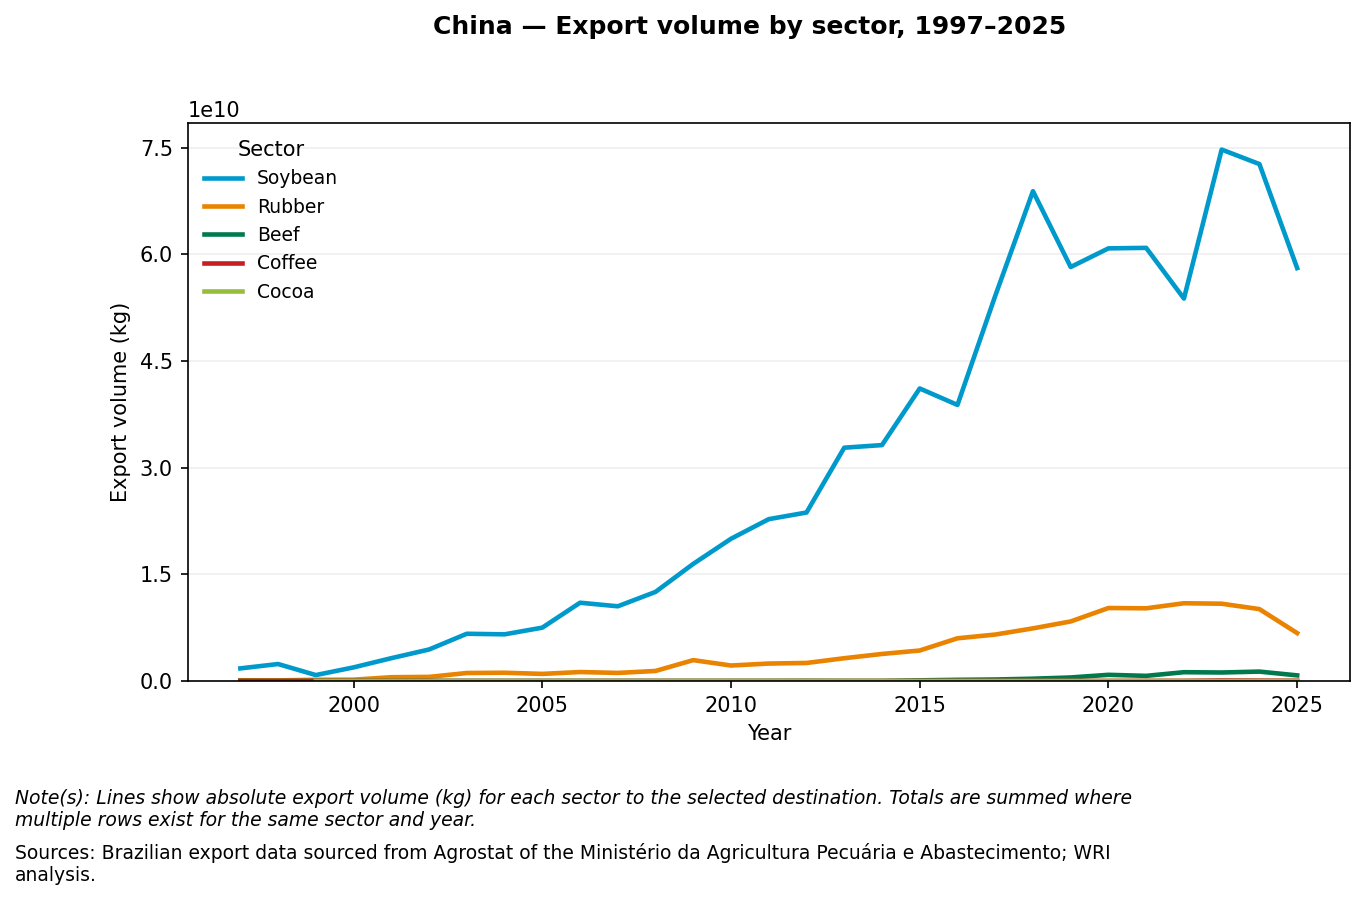

Saved: figures_brazil_exports_volume_by_country\china_volume_by_sector_1997_2025.png


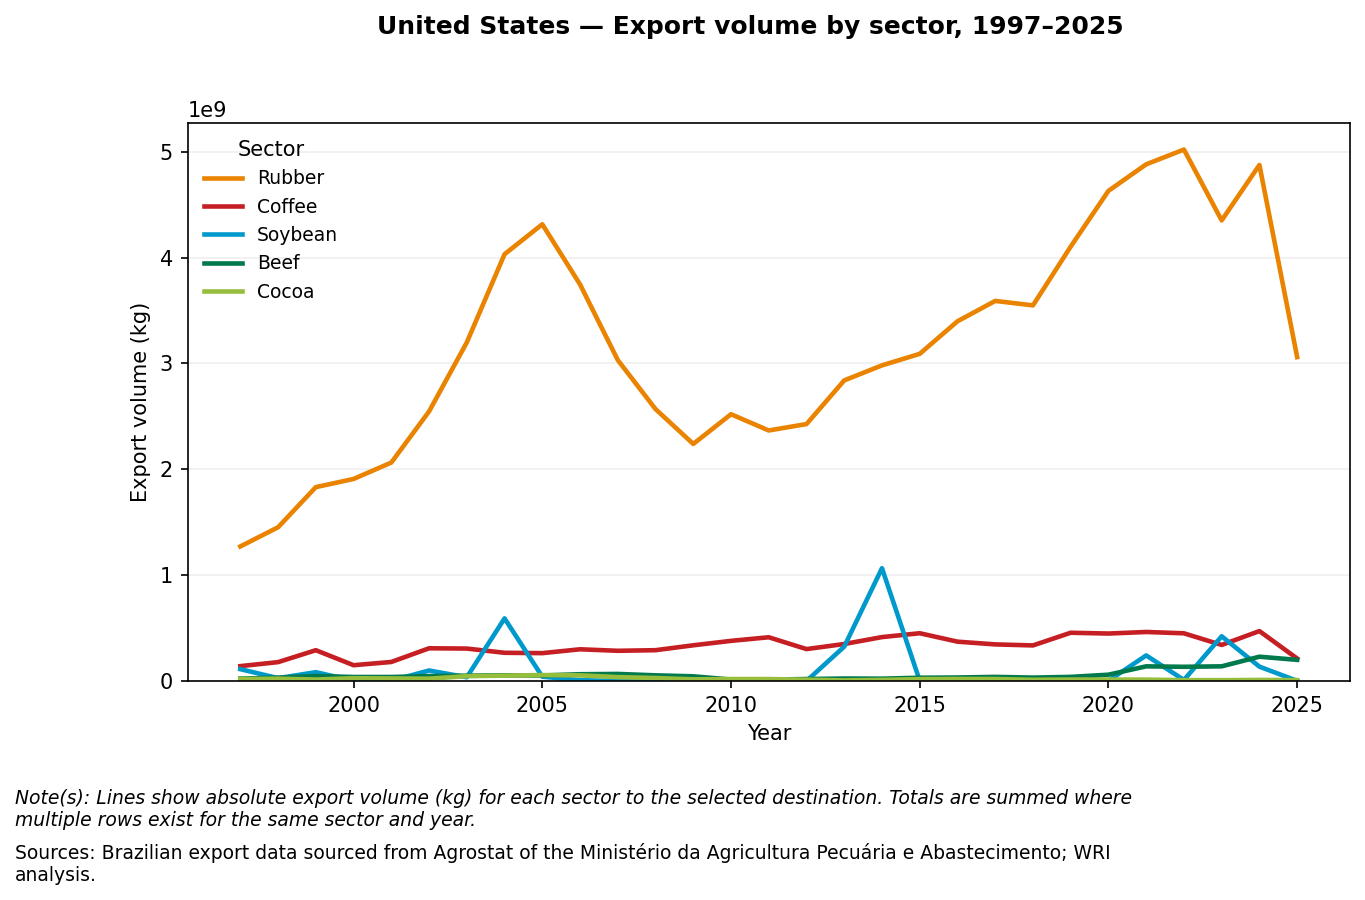

Saved: figures_brazil_exports_volume_by_country\united_states_volume_by_sector_1997_2025.png


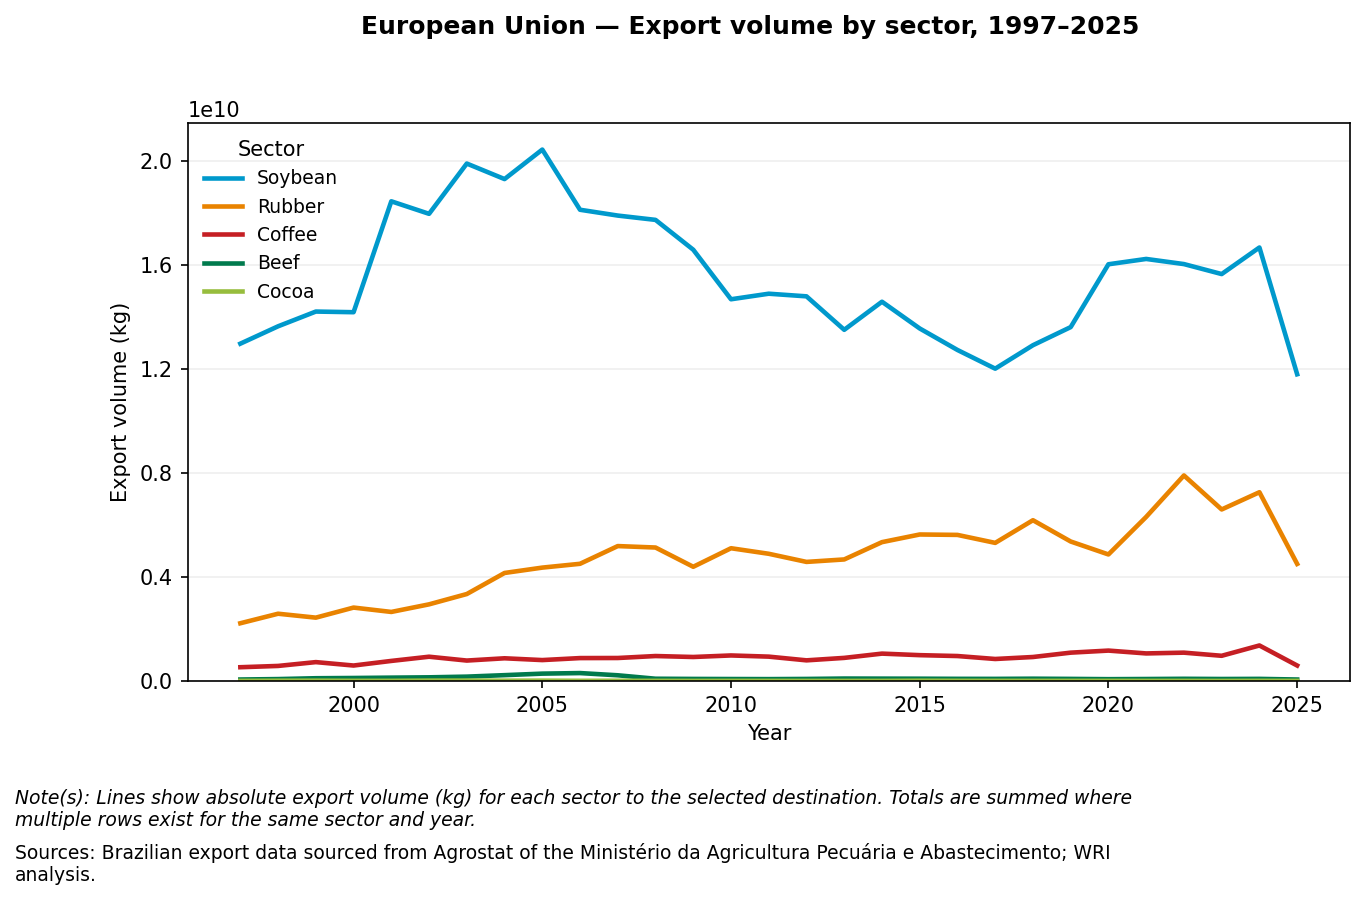

Saved: figures_brazil_exports_volume_by_country\european_union_volume_by_sector_1997_2025.png
Exported volume table: figures_brazil_exports_volume_by_country\brazil_export_volumes_country_product_1997_2025.csv


In [17]:
# JUPYTER NOTEBOOK CELL — 1997–2025, TWO-ROW HEADER
# SECTORS (Soybean, Coffee, Cocoa, Forest Products, Rubber, Beef) — ABSOLUTE EXPORT VOLUME (kg)
# One chart per COUNTRY, with ALL commodities as separate lines (no percentages)

import os
import re
import math
import textwrap
from typing import List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# ------------------------------------------------------------------------------------
# 1) Configuration
# ------------------------------------------------------------------------------------

# Workbook path
EXCEL_PATH = r"D:\WRI\Field Boundaries\Tech Note\Agrostat - Brazil - EUDR Crop Exports\Brazil Commodity Exports 1997-2025.xlsx"
# If running in an environment where the file has been uploaded under /mnt/data, use this instead:
# EXCEL_PATH = r"/mnt/data/Brazil Commodity Exports 1997-2025.xlsx"

SHEET_NAME = 0  # change if your data are on another sheet

# Countries of interest and canonical names
COUNTRY_ALIASES = {
    "all": ["all", "total", "totals", "totais", "grand total"],
    "china": ["china"],
    "united states": [
        "united states", "usa", "u.s.a.", "u.s.", "us",
        "estados unidos", "united states of america", "eua"
    ],
    "european union": [
        "european union", "eu", "ue 27", "ue27", "eu 27", "eu-27", "eu27", "ue"
    ],
}

# Product (sector) canonical mapping — includes Rubber (maps legacy "Timber"→Rubber) and Beef
PRODUCT_CANON = {
    "soybean": ["soy", "soja", "soybean", "soybeans", "complexo soja", "soj"],
    "coffee": ["coffee", "cafe", "café", "caf\u00e9", "cafê"],
    "cocoa": ["cocoa", "cacau", "cacao", "cocoa and products", "cocoa products"],
    "forest products": [
        "forest products", "forest", "produtos florestais", "madeira",
        "wood", "paper", "pulp", "celulose", "papel", "pulp & paper", "pulp and paper"
    ],
    "rubber": ["rubber", "latex", "hevea", "borracha", "timber"],  # map any "Timber" to Rubber
    "beef": [
        "beef", "bovina", "bovino", "bovinos", "carne bovina",
        "bovine", "bovine meat", "carne de bovino", "carne bovina in natura"
    ],
}

# Desired year span
YEAR_START = 1997
YEAR_END = 2025

# Per-country line colors for the ORIGINAL destination plots are irrelevant here.
# We now need PER-PRODUCT colors (same country, many product lines), using only approved palette.
PRODUCT_COLORS = {
    "Soybean": "#0099CC",
    "Coffee": "#C51F24",
    "Cocoa": "#97BD3D",
    "Forest Products": "#7D0063",
    "Rubber": "#E98300",
    "Beef": "#007A4D",
}
# Fallback palette (cycled) if any unexpected product sneaks in
FALLBACK_COLORS = ["#003F6A", "#ED1A37", "#FCD900", "#9B9B9B"]

# Countries to plot (one chart per country)
COUNTRIES_TO_PLOT = ["China", "United States", "European Union"]

# Output figure directory (created if missing)
FIG_DIR = "figures_brazil_exports_volume_by_country"
os.makedirs(FIG_DIR, exist_ok=True)

# ------------------------------------------------------------------------------------
# 2) Helpers for normalization and parsing
# ------------------------------------------------------------------------------------

def _ascii_lower(s: str) -> str:
    if s is None:
        return ""
    s = str(s)
    s = s.replace("Á","A").replace("À","A").replace("Â","A").replace("Ã","A").replace("Ä","A").replace("á","a").replace("à","a").replace("â","a").replace("ã","a").replace("ä","a")
    s = s.replace("É","E").replace("È","E").replace("Ê","E").replace("Ë","E").replace("é","e").replace("è","e").replace("ê","e").replace("ë","e")
    s = s.replace("Í","I").replace("Ì","I").replace("Î","I").replace("Ï","I").replace("í","i").replace("ì","i").replace("î","i").replace("ï","i")
    s = s.replace("Ó","O").replace("Ò","O").replace("Ô","O").replace("Õ","O").replace("Ö","O").replace("ó","o").replace("ò","o").replace("ô","o").replace("õ","o").replace("ö","o")
    s = s.replace("Ú","U").replace("Ù","U").replace("Û","U").replace("Ü","U").replace("ú","u").replace("ù","u").replace("û","u").replace("ü","u")
    s = s.replace("Ç","C").replace("ç","c")
    return s.lower().strip()

def parse_year(x) -> Optional[int]:
    if x is None:
        return None
    s = str(x)
    m = re.search(r"(19|20)\d{2}", s)
    if m:
        return int(m.group(0))
    return None

def is_value_measure(name: str) -> bool:
    s = _ascii_lower(name)
    return any(k in s for k in ["value", "valor", "us$", "usd", "dollar", "d\u00f3lar", "dolar"])

def is_weight_measure(name: str) -> bool:
    s = _ascii_lower(name)
    return any(k in s for k in ["weight", "volume", "peso", "kg", "ton", "tonne", "tonnes"])

def is_country_header(name: str) -> bool:
    s = _ascii_lower(name)
    return any(k in s for k in ["country", "pa\u00eds", "pais", "bloco", "país"])

def is_product_header(name: str) -> bool:
    s = _ascii_lower(name)
    return any(k in s for k in ["product", "setor", "produto", "sector"])

def canon_country(name: str) -> Optional[str]:
    s = _ascii_lower(name)
    if s in {"eu", "ue", "eu-27", "eu27", "eu 27", "ue27", "ue 27"} or "european union" in s:
        return "European Union"
    if any(v in s for v in COUNTRY_ALIASES["china"]):
        return "China"
    if any(v in s for v in COUNTRY_ALIASES["united states"]):
        return "United States"
    if any(v in s for v in COUNTRY_ALIASES["all"]):
        return "All"
    return None

def canon_product(name: str) -> Optional[str]:
    s = _ascii_lower(name)
    # enforce Timber→Rubber replacement before mapping
    s = re.sub(r"\btimber\b", "rubber", s, flags=re.IGNORECASE)
    for canon, variants in PRODUCT_CANON.items():
        for v in variants:
            if v in s:
                return {
                    "soybean": "Soybean",
                    "coffee": "Coffee",
                    "cocoa": "Cocoa",
                    "forest products": "Forest Products",
                    "rubber": "Rubber",
                    "beef": "Beef",
                }[canon]
    return None

def to_number(x) -> Optional[float]:
    if x is None or (isinstance(x, float) and math.isnan(x)):
        return None
    if isinstance(x, (int, float, np.integer, np.floating)):
        return float(x)
    s = str(x).strip().replace(",", "").replace("\u00a0", "").replace(" ", "")
    # Handle dashes or blanks as missing
    if s in {"-", "", "nan", "None", "NONE"}:
        return None
    try:
        return float(s)
    except Exception:
        return None

def wrap_text(s: str, width: int = 100) -> str:
    return "\n".join(textwrap.wrap(s, width=width, break_long_words=False))

def sentence_case(s: str) -> str:
    s = str(s).strip()
    return s[:1].upper() + s[1:].lower() if s else s

# ------------------------------------------------------------------------------------
# 3) Load and transform to long/tidy format (row 1 years; row 2 measure labels)
# ------------------------------------------------------------------------------------

def load_wide_table(path: str, sheet_name=0) -> pd.DataFrame:
    df = pd.read_excel(path, sheet_name=sheet_name, header=[0, 1], dtype=object)

    # Normalize the column MultiIndex
    norm_cols = []
    for col in df.columns:
        if isinstance(col, tuple) and len(col) == 2:
            top, bottom = col
            top_str = "" if (top is None or (isinstance(top, float) and pd.isna(top))) else str(top)
            if top_str.strip() == "" or top_str.lower().startswith("unnamed"):
                top_clean = None
            else:
                top_clean = top
            bottom_clean = str(bottom).strip()
            norm_cols.append((top_clean, bottom_clean))
        else:
            norm_cols.append((None, str(col).strip()))
    df.columns = pd.MultiIndex.from_tuples(norm_cols)
    return df

def _first_column_key_with_bottom(df_multi: pd.DataFrame, bottom_label: str) -> Optional[Tuple[object, str]]:
    target = _ascii_lower(bottom_label)
    candidates = [c for c in df_multi.columns if _ascii_lower(c[1]) == target]
    if not candidates:
        return None
    for c in candidates:
        if c[0] is None:
            return c
    return candidates[0]

def find_id_columns(df_multi: pd.DataFrame) -> Tuple[Tuple[object, str], Tuple[object, str]]:
    country_key = None
    product_key = None
    for top, bottom in df_multi.columns:
        if is_country_header(bottom) and country_key is None:
            country_key = _first_column_key_with_bottom(df_multi, bottom)
        if is_product_header(bottom) and product_key is None:
            product_key = _first_column_key_with_bottom(df_multi, bottom)
    if country_key is None or product_key is None:
        cols = list(df_multi.columns)
        if len(cols) < 2:
            raise ValueError("Could not infer 'country' and 'product' columns.")
        country_key = cols[0] if country_key is None else country_key
        product_key = cols[1] if product_key is None else product_key
    return country_key, product_key

def melt_to_long(df_multi: pd.DataFrame) -> pd.DataFrame:
    country_key, product_key = find_id_columns(df_multi)

    value_cols: List[Tuple[Tuple[object, str], int]] = []
    weight_cols: List[Tuple[Tuple[object, str], int]] = []
    for (top, bottom) in df_multi.columns:
        y = parse_year(top)
        if y is None:
            continue
        if is_value_measure(bottom):
            value_cols.append(((top, bottom), y))
        elif is_weight_measure(bottom):
            weight_cols.append(((top, bottom), y))

    if not value_cols and not weight_cols:
        raise ValueError("No value/weight measure columns were detected. Please check header rows.")

    id_df = pd.DataFrame({
        "country": df_multi[country_key],
        "product": df_multi[product_key],
    })

    long_frames = []
    if value_cols:
        df_val = id_df.copy()
        for (key, y) in value_cols:
            df_val[y] = df_multi[key]
        dfm = df_val.melt(id_vars=["country", "product"], var_name="year", value_name="amount")
        dfm["measure"] = "value"
        long_frames.append(dfm)

    if weight_cols:
        df_wt = id_df.copy()
        for (key, y) in weight_cols:
            df_wt[y] = df_multi[key]
        dfm2 = df_wt.melt(id_vars=["country", "product"], var_name="year", value_name="amount")
        dfm2["measure"] = "weight"
        long_frames.append(dfm2)

    long_df = pd.concat(long_frames, ignore_index=True)
    long_df["year"] = pd.to_numeric(long_df["year"], errors="coerce").astype("Int64")
    long_df["amount"] = long_df["amount"].apply(to_number)
    long_df = long_df.dropna(subset=["year", "amount"]).copy()

    # Timber→Rubber rename on raw labels, then canonicalize product & country
    long_df["product"] = long_df["product"].astype(str).str.replace(r"(?i)\btimber\b", "Rubber", regex=True)
    long_df["product_canon"] = long_df["product"].apply(canon_product)
    long_df["country_canon"] = long_df["country"].apply(canon_country)

    # Keep requested products and countries
    keep_products = ["Soybean", "Coffee", "Cocoa", "Forest Products", "Rubber", "Beef"]
    long_df = long_df[long_df["product_canon"].isin(keep_products)].copy()
    long_df = long_df[long_df["country_canon"].isin(["All", "China", "United States", "European Union"])].copy()

    long_df = long_df[(long_df["year"] >= YEAR_START) & (long_df["year"] <= YEAR_END)].copy()

    # Final tidy columns
    long_df = long_df[["country_canon", "product_canon", "year", "measure", "amount"]].rename(
        columns={"country_canon": "country", "product_canon": "product"}
    ).reset_index(drop=True)

    return long_df

# ------------------------------------------------------------------------------------
# 4) Plotting with WRI figure style (VOLUME ONLY; one plot per country with product lines)
# ------------------------------------------------------------------------------------

def plot_country_products_volume(
    df_long: pd.DataFrame,
    country: str,
    note_text: str,
    source_text: str,
    save_dir: str = FIG_DIR
) -> str:
    """
    For a single country, plot all product lines (absolute export volume in kg) for 1997–2025.
    """
    sub = df_long[(df_long["country"] == country) & (df_long["measure"] == "weight")].copy()
    if sub.empty:
        raise ValueError(f"No volume data available to plot for country={country}.")

    # Sum across any duplicate rows for the same (year, product)
    g = sub.groupby(["year", "product"], dropna=False)["amount"].sum(min_count=1).reset_index()

    # Pivot: index = year; columns = product; values = summed amount
    pivot = g.pivot(index="year", columns="product", values="amount").sort_index()

    # Ensure consistent column order (by total volume descending)
    col_totals = pivot.sum(axis=0, skipna=True).sort_values(ascending=False)
    pivot = pivot[col_totals.index]

    # Build product color list in our chosen order
    colors = []
    unknown_count = 0
    for prod in pivot.columns:
        if prod in PRODUCT_COLORS:
            colors.append(PRODUCT_COLORS[prod])
        else:
            colors.append(FALLBACK_COLORS[unknown_count % len(FALLBACK_COLORS)])
            unknown_count += 1

    fig, ax = plt.subplots(figsize=(10, 6), dpi=150)

    for i, prod in enumerate(pivot.columns):
        ax.plot(pivot.index.values, pivot[prod].values, label=str(prod), linewidth=2.2, color=colors[i])

    ax.set_xlabel("Year")
    ax.set_ylabel("Export volume (kg)")
    ymax = np.nanmax(pivot.values)
    if np.isnan(ymax) or ymax <= 0:
        ymax = 1.0
    ax.set_ylim(0, math.ceil(ymax * 1.05))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6))
    ax.grid(True, axis="y", alpha=0.2, linewidth=0.8)
    ax.legend(title=sentence_case("sector"), frameon=False, ncol=1, fontsize=9)

    # Title
    title = f"{country} — Export volume by sector, {YEAR_START}–{YEAR_END}"
    plt.suptitle(title, fontsize=12, fontweight="bold", y=0.98)

    # Footers per WRI style
    nt = wrap_text(note_text, width=110)
    st = wrap_text(source_text, width=110)
    plt.subplots_adjust(top=0.86, bottom=0.24)
    fig.text(0.01, 0.12, f"Note(s): {nt}", ha="left", va="top", fontsize=9, style="italic")
    fig.text(0.01, 0.06, f"Sources: {st}", ha="left", va="top", fontsize=9)

    # Save
    safe_country = _ascii_lower(country).replace(" ", "_").replace("-", "_")
    outpath = os.path.join(save_dir, f"{safe_country}_volume_by_sector_{YEAR_START}_{YEAR_END}.png")
    plt.savefig(outpath, bbox_inches="tight")
    plt.show()

    return outpath

# ------------------------------------------------------------------------------------
# 5) Run: load, transform, and generate VOLUME charts — one per country with all sectors
# ------------------------------------------------------------------------------------

df_wide = load_wide_table(EXCEL_PATH, sheet_name=SHEET_NAME)
df_long_all = melt_to_long(df_wide)

available_years = sorted(df_long_all["year"].dropna().unique().tolist())
print("Available years in the dataset:", available_years)

NOTE_VOLUME = (
    "Lines show absolute export volume (kg) for each sector to the selected destination. "
    "Totals are summed where multiple rows exist for the same sector and year."
)
SOURCES = "Brazilian export data sourced from Agrostat of the Ministério da Agricultura Pecuária e Abastecimento; WRI analysis."

saved_files: List[str] = []

for ctry in COUNTRIES_TO_PLOT:
    try:
        outpng = plot_country_products_volume(
            df_long=df_long_all,
            country=ctry,
            note_text=NOTE_VOLUME,
            source_text=SOURCES,
            save_dir=FIG_DIR
        )
        saved_files.append(outpng)
        print(f"Saved: {outpng}")
    except ValueError as e:
        print(f"Skipping {ctry}: {e}")

# Optional: export the country–product–year volume table used for plots
volume_csv_path = os.path.join(FIG_DIR, "brazil_export_volumes_country_product_1997_2025.csv")
(df_long_all[df_long_all["measure"] == "weight"]
 .sort_values(["country", "product", "year"])
 .to_csv(volume_csv_path, index=False))
print(f"Exported volume table: {volume_csv_path}")


# Soy Sub-sector Analysis 1997 - 2025

Countries detected (soy derivatives): ['All', 'China', 'European Union', 'United States']


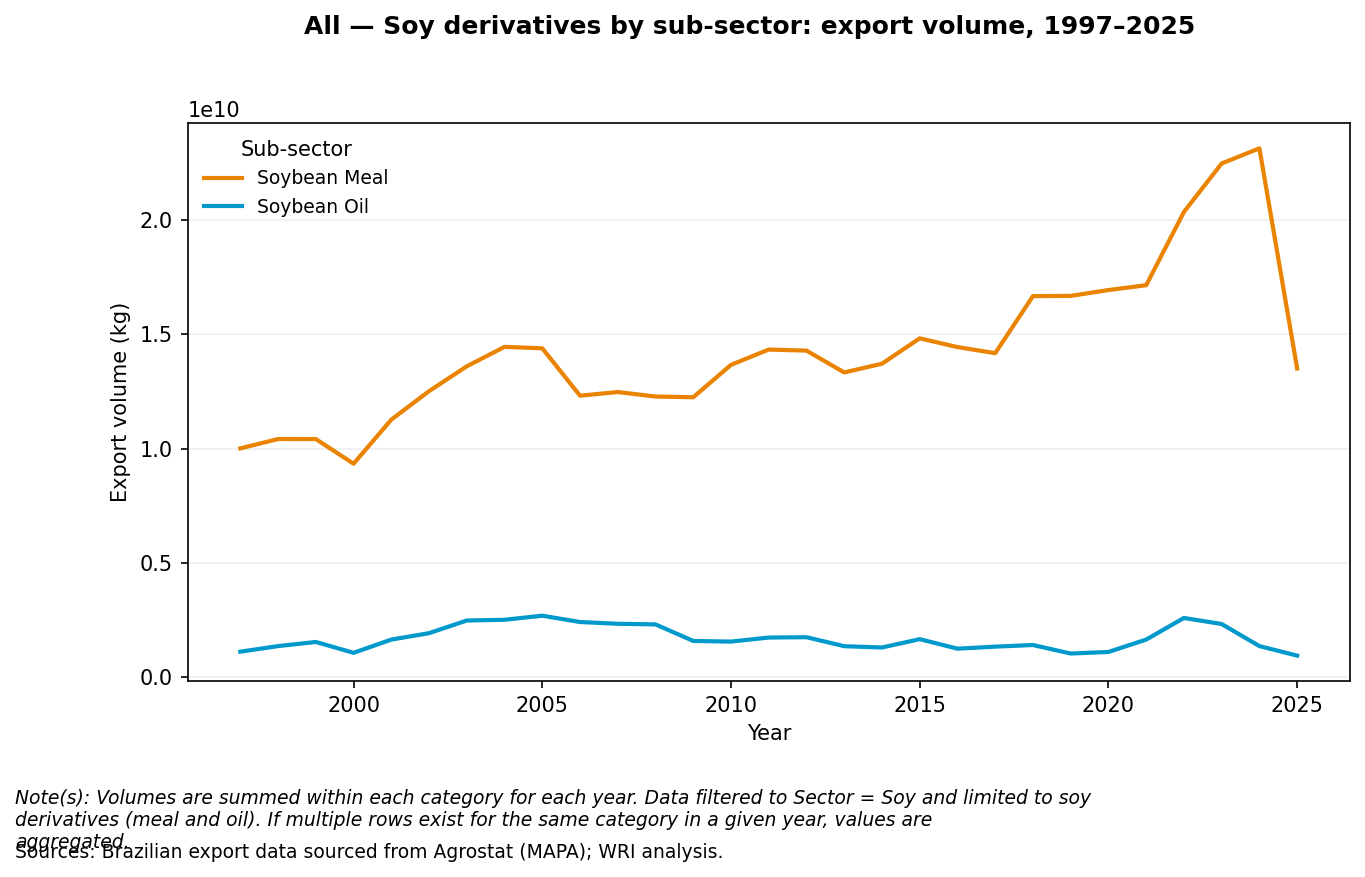

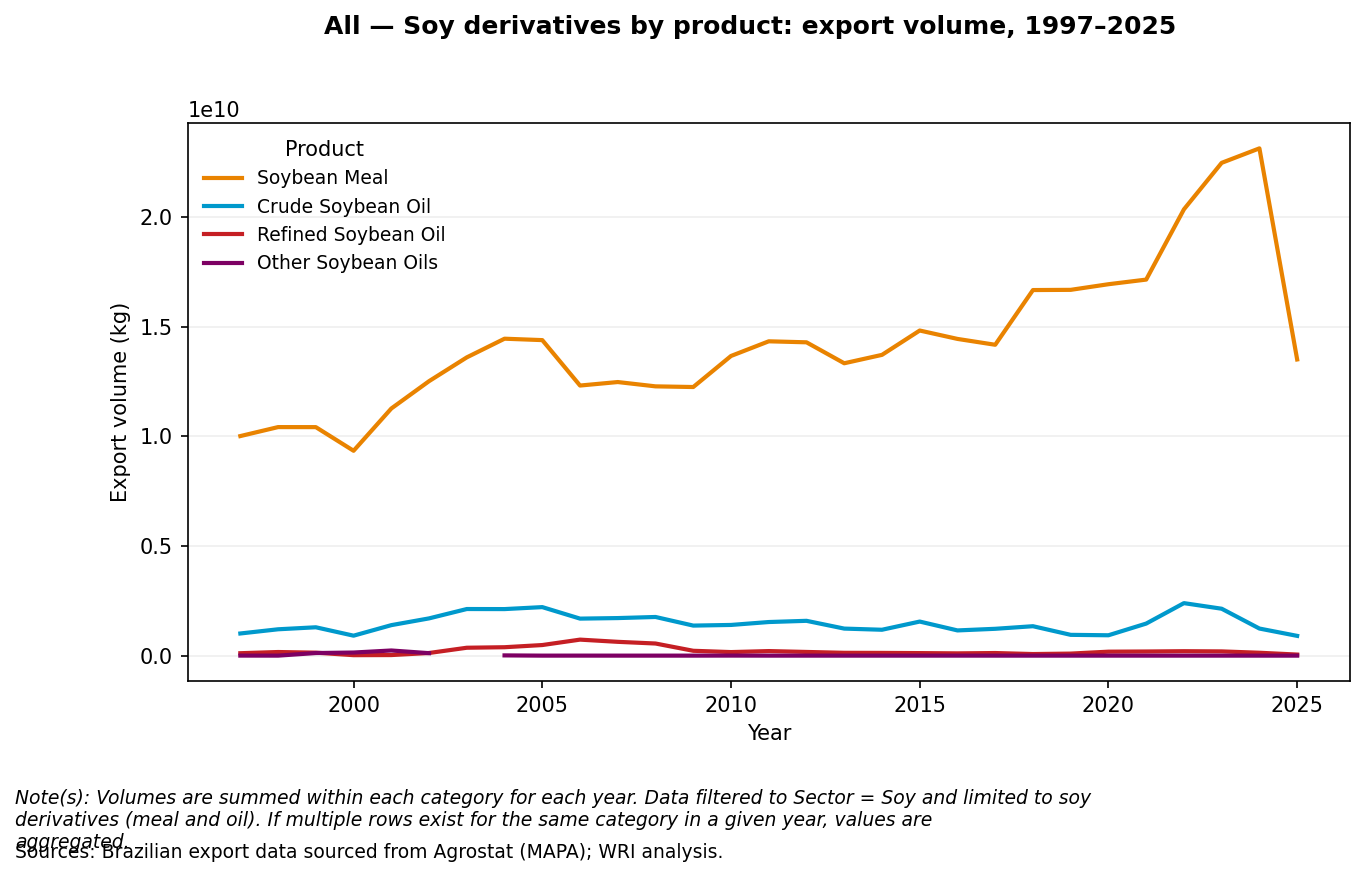

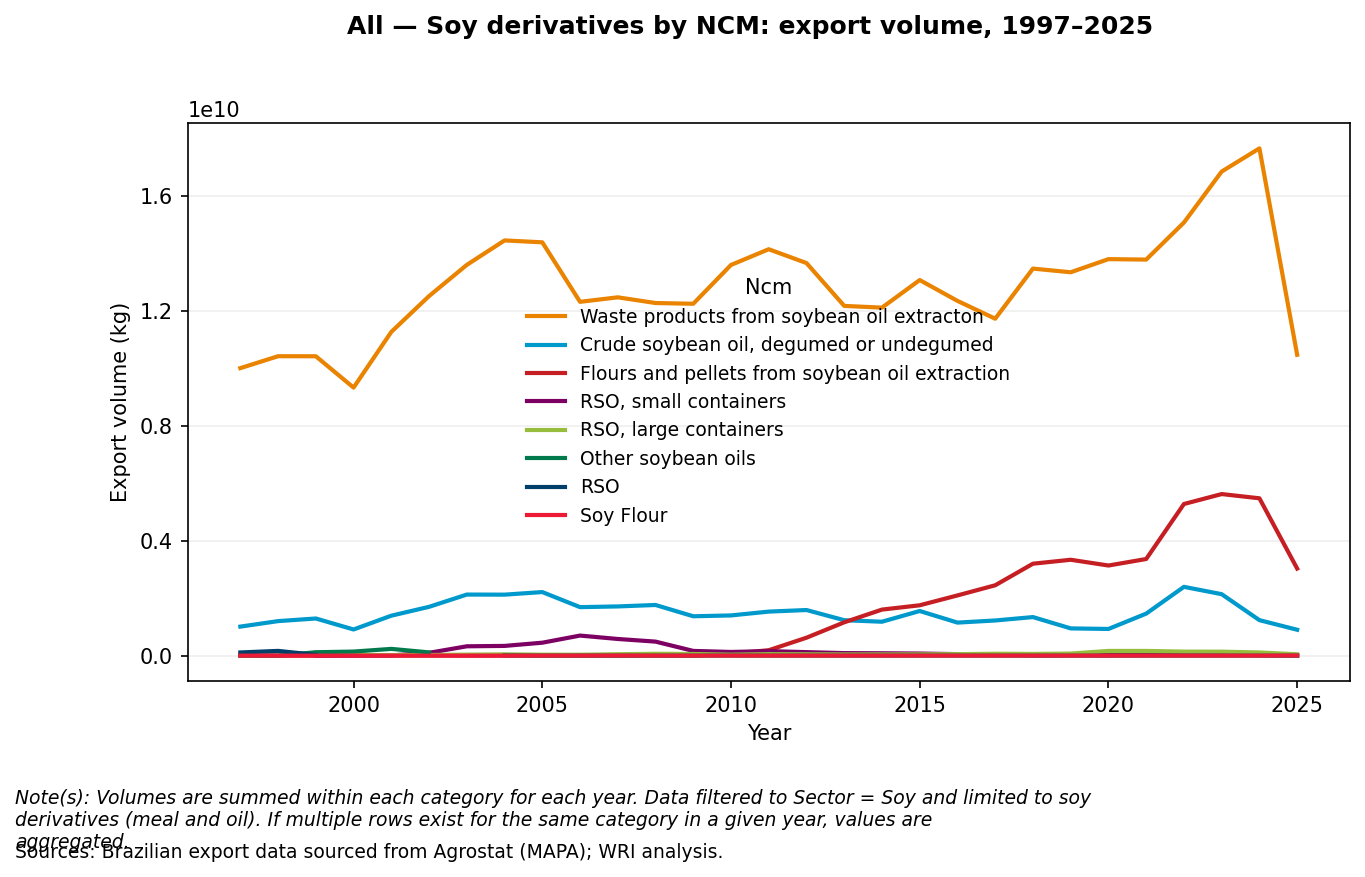

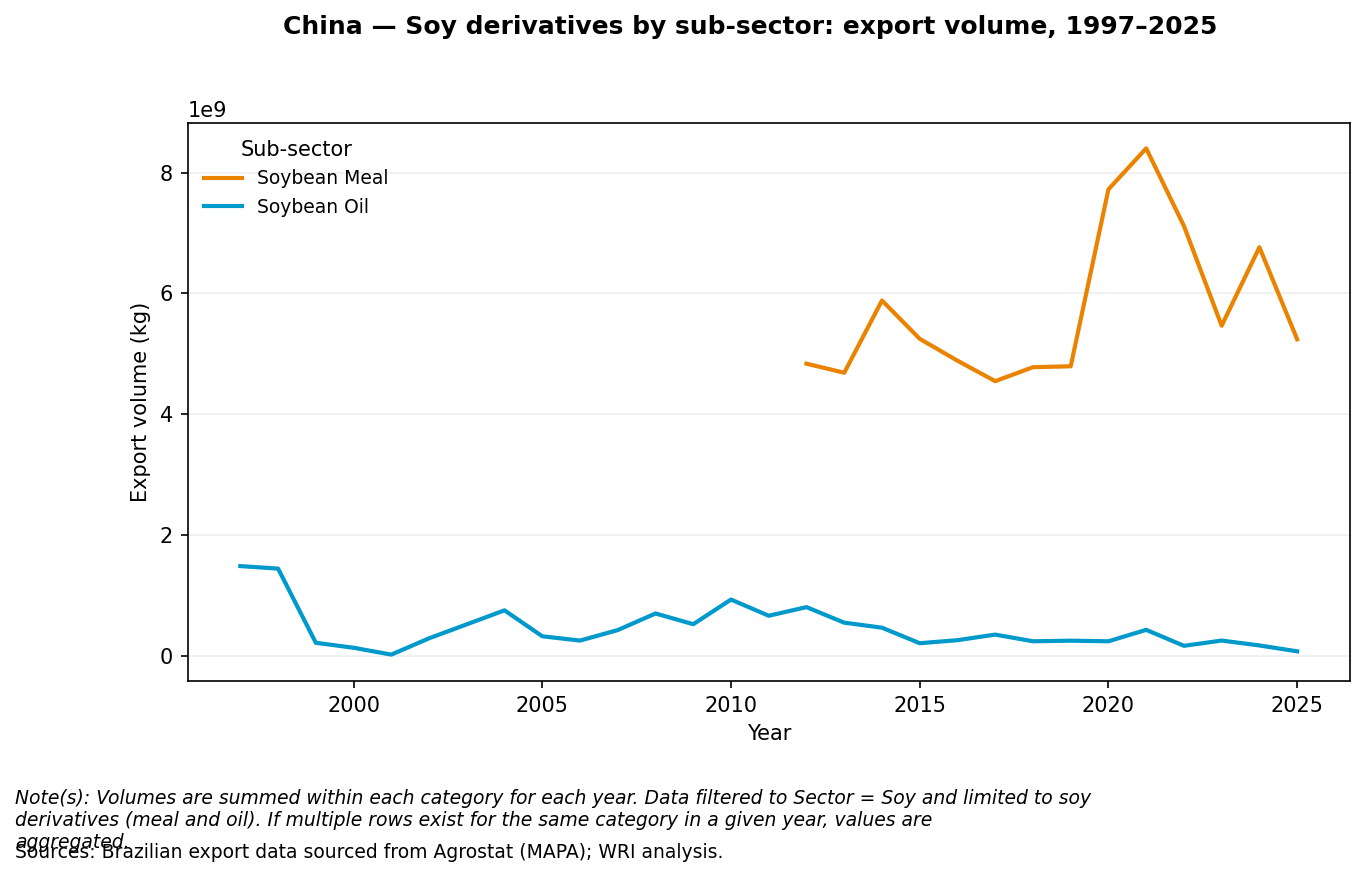

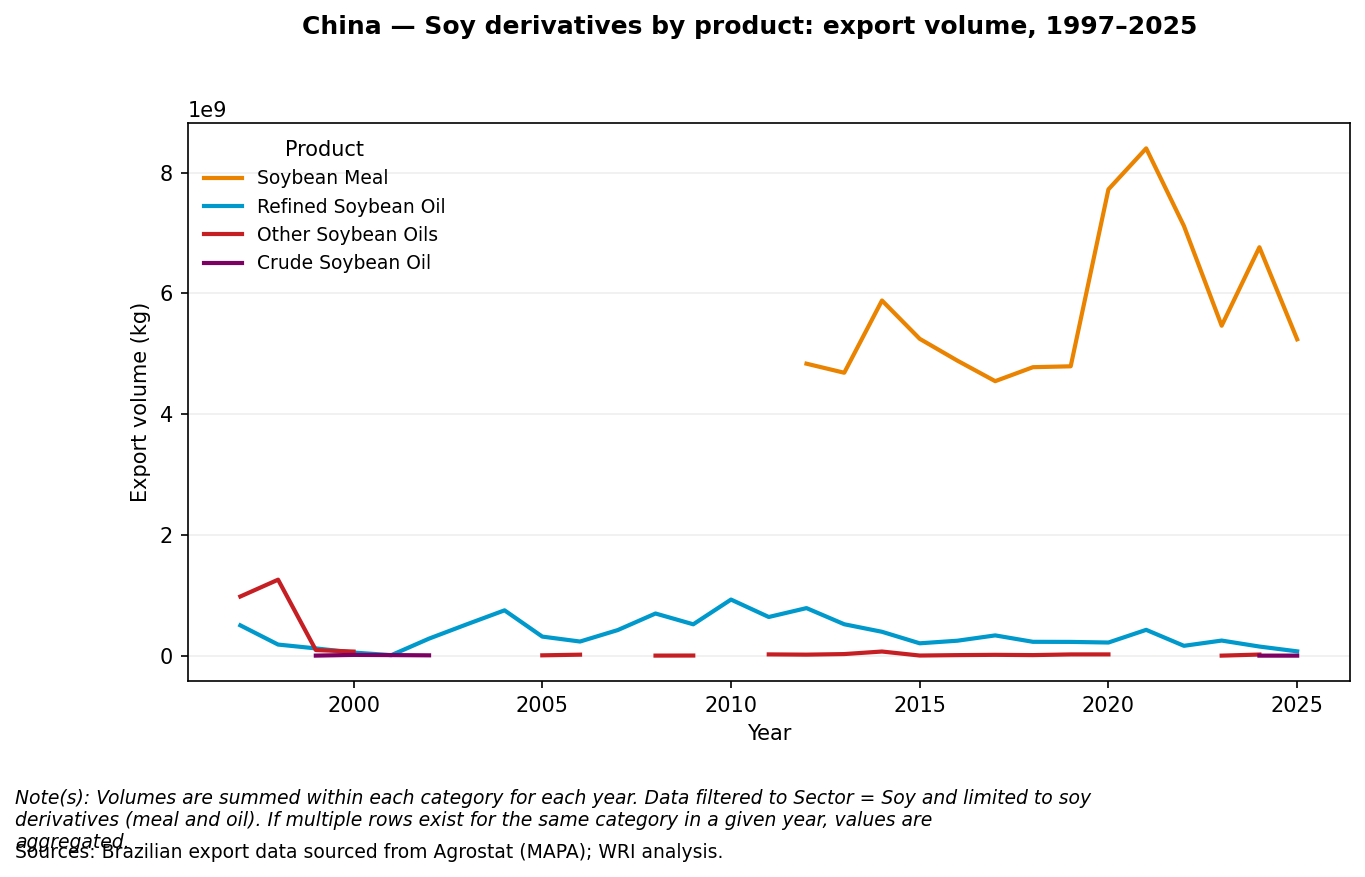

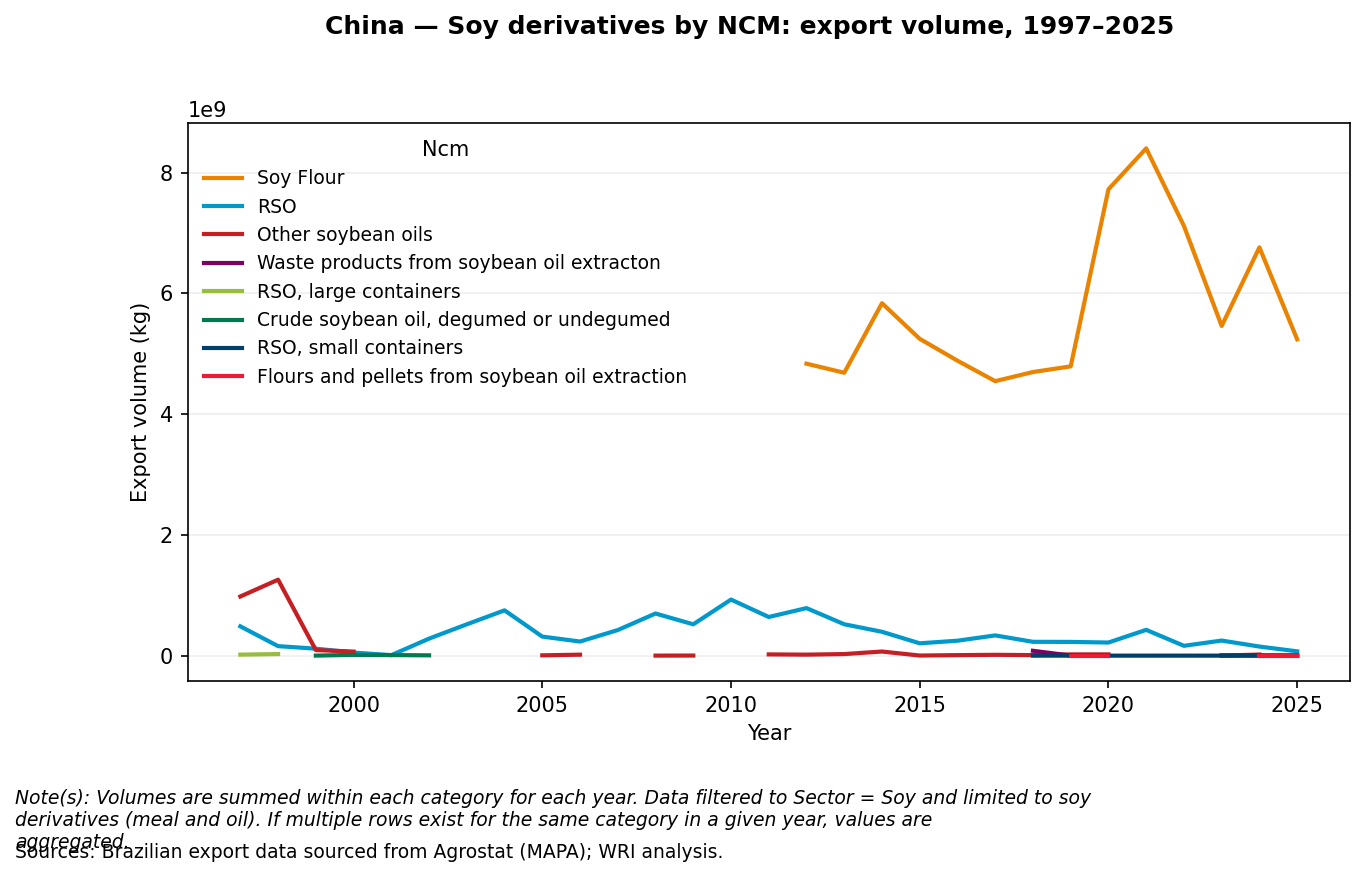

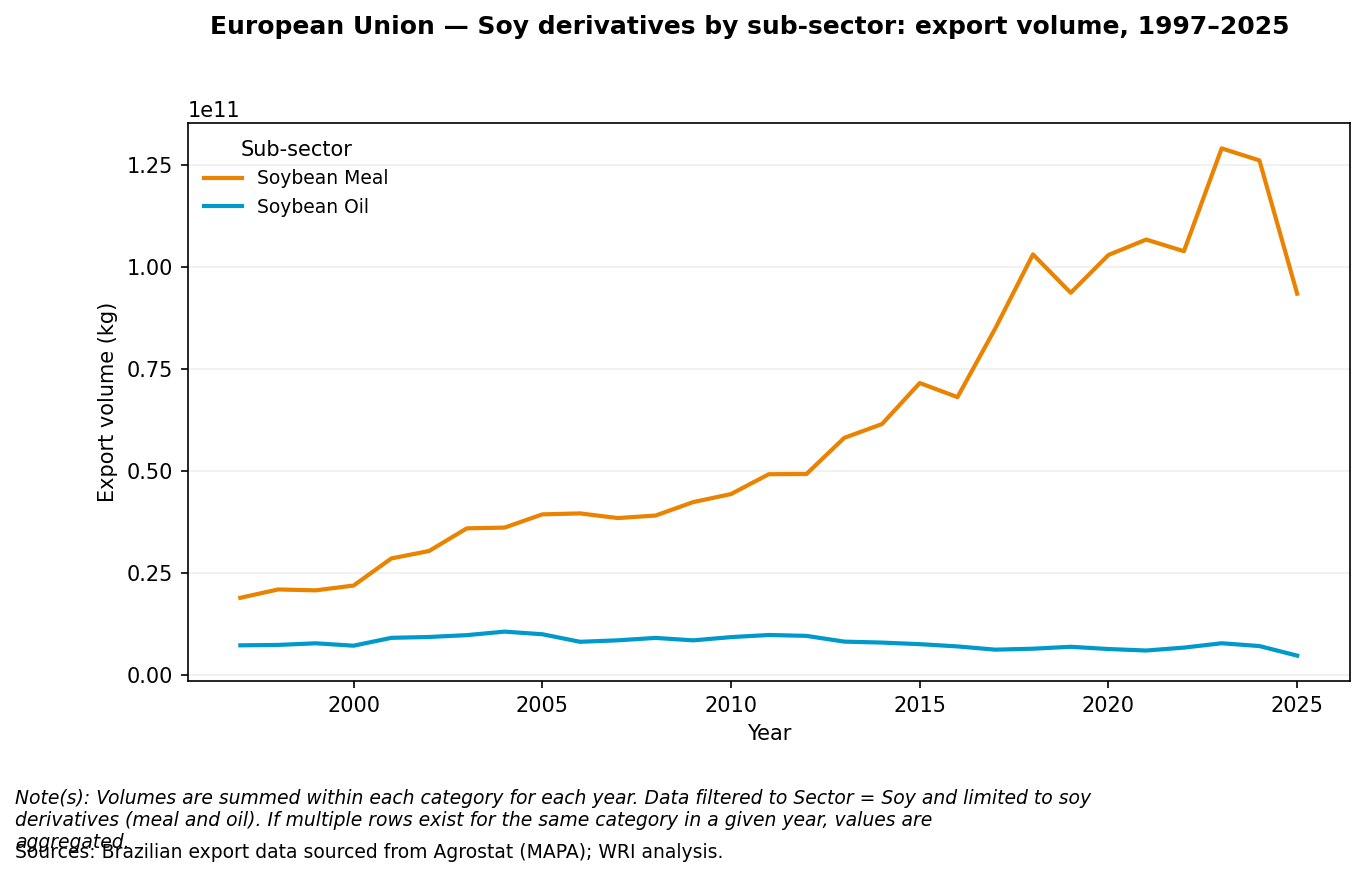

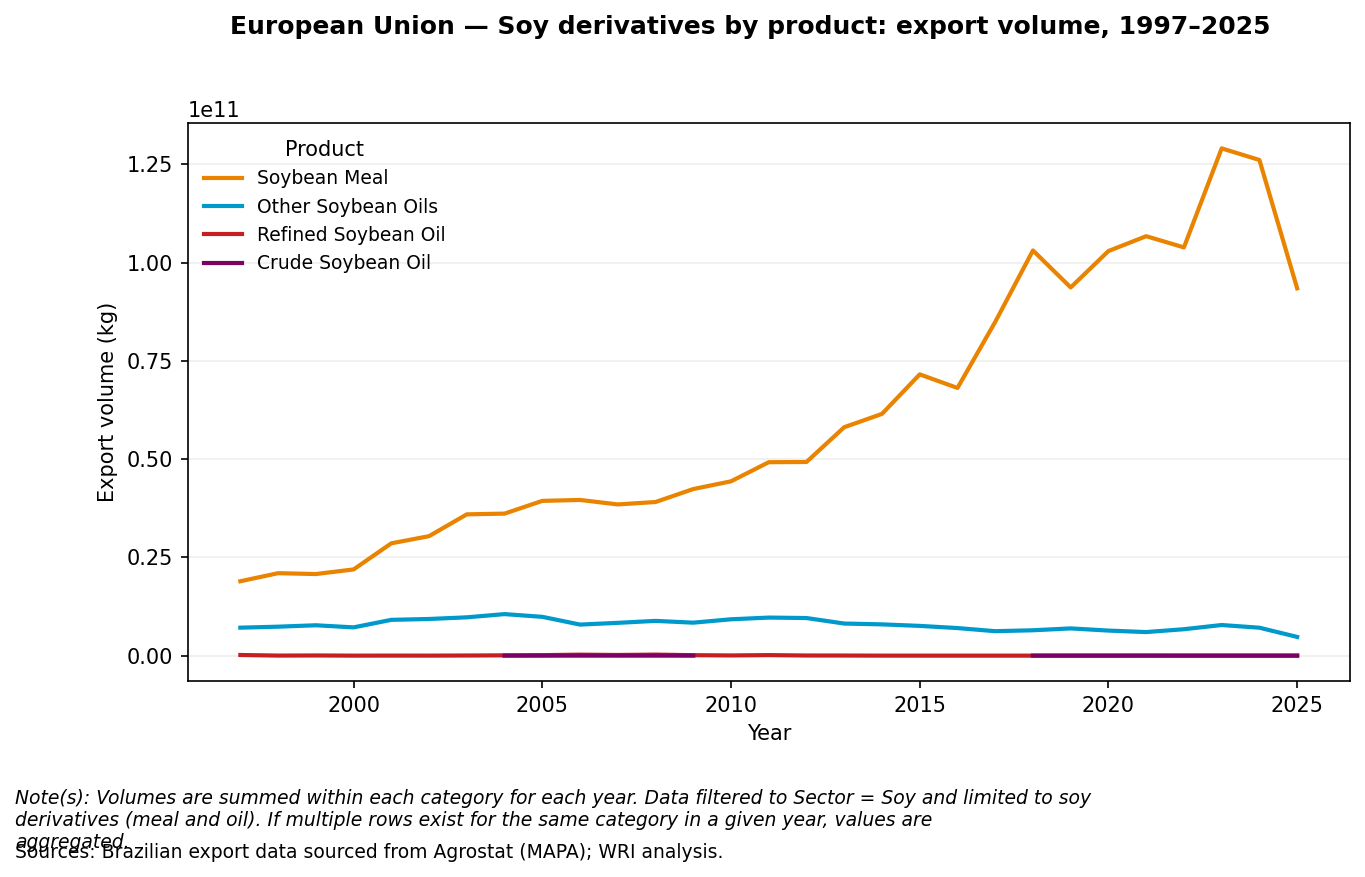

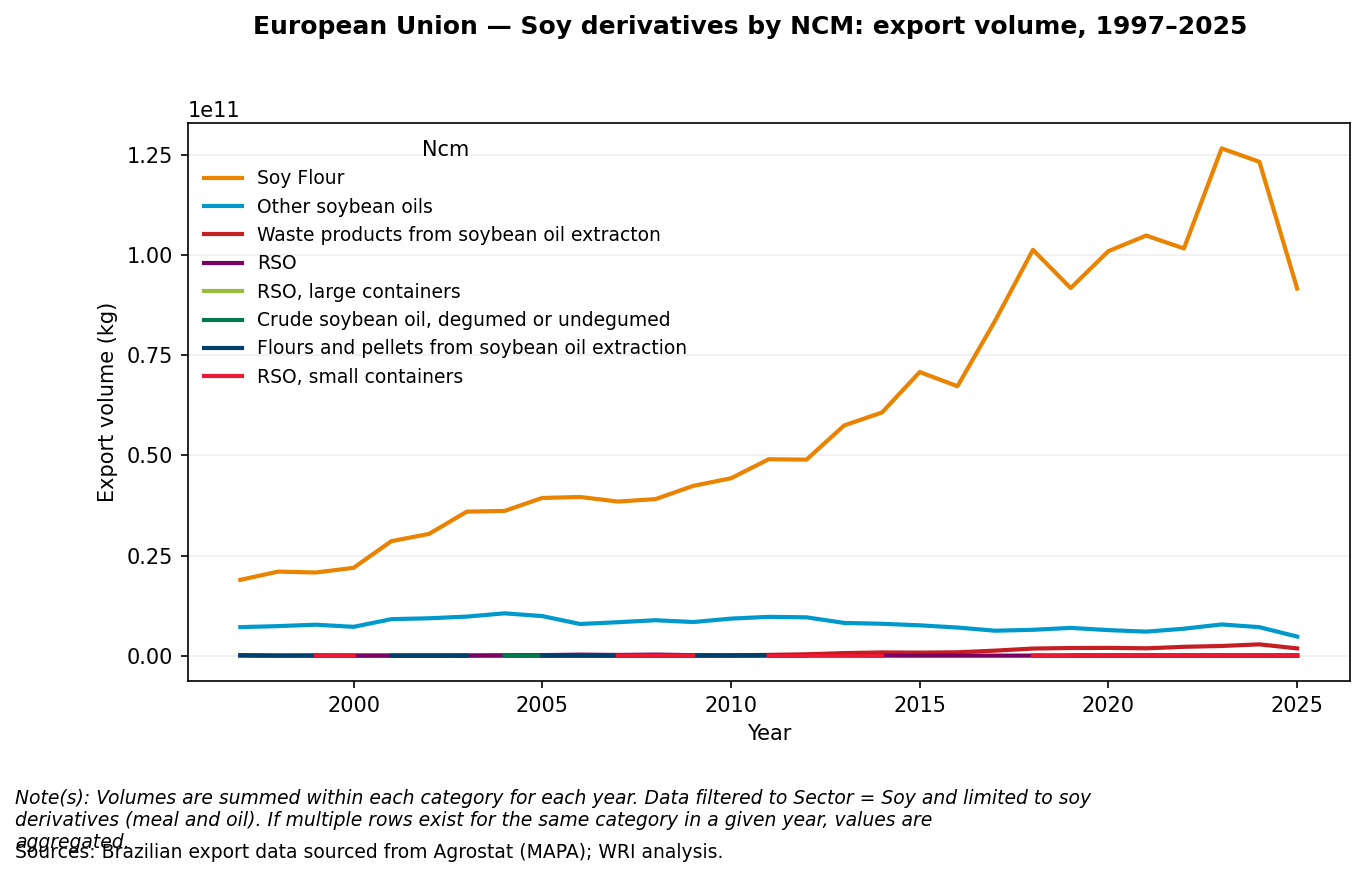

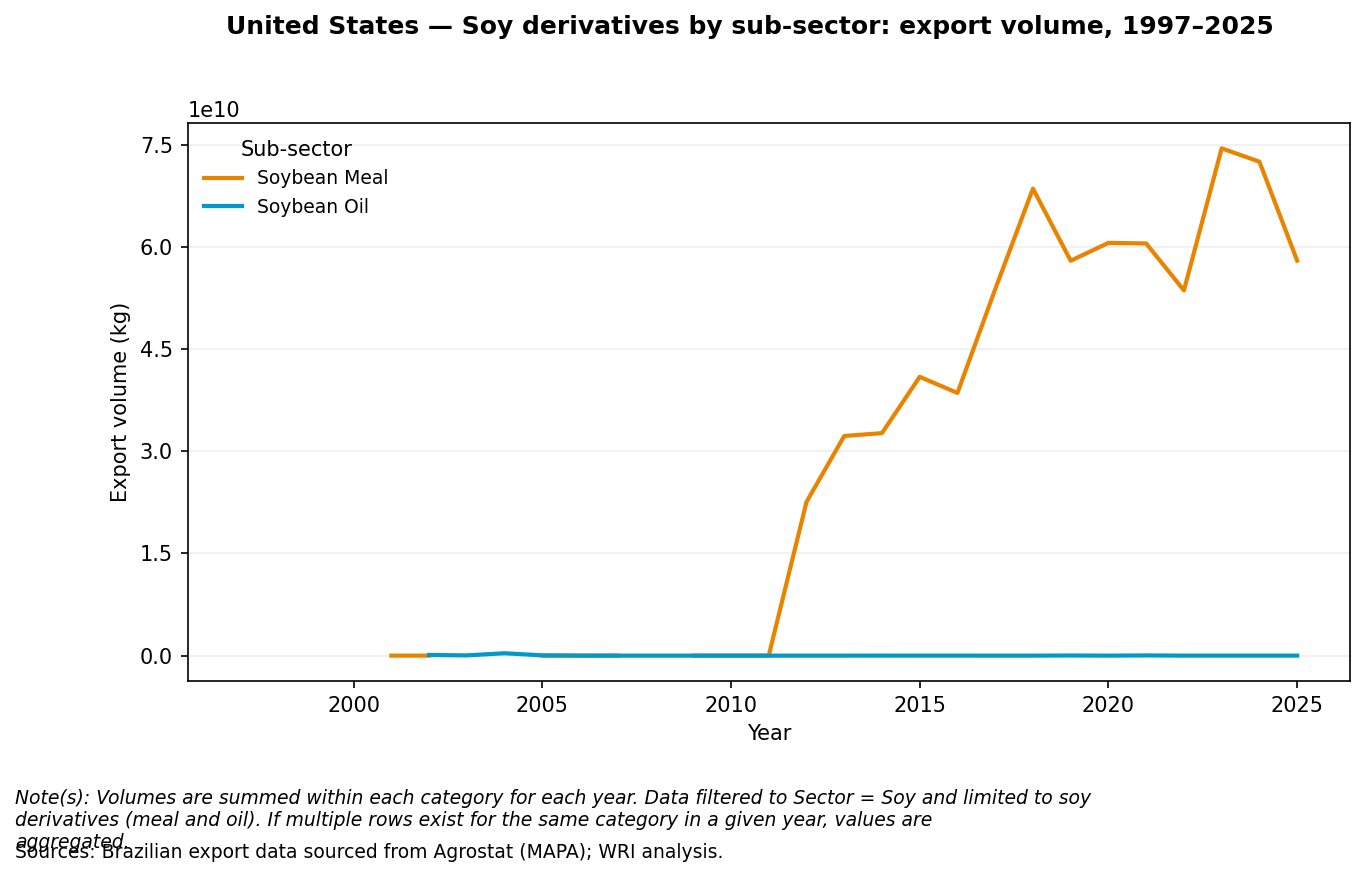

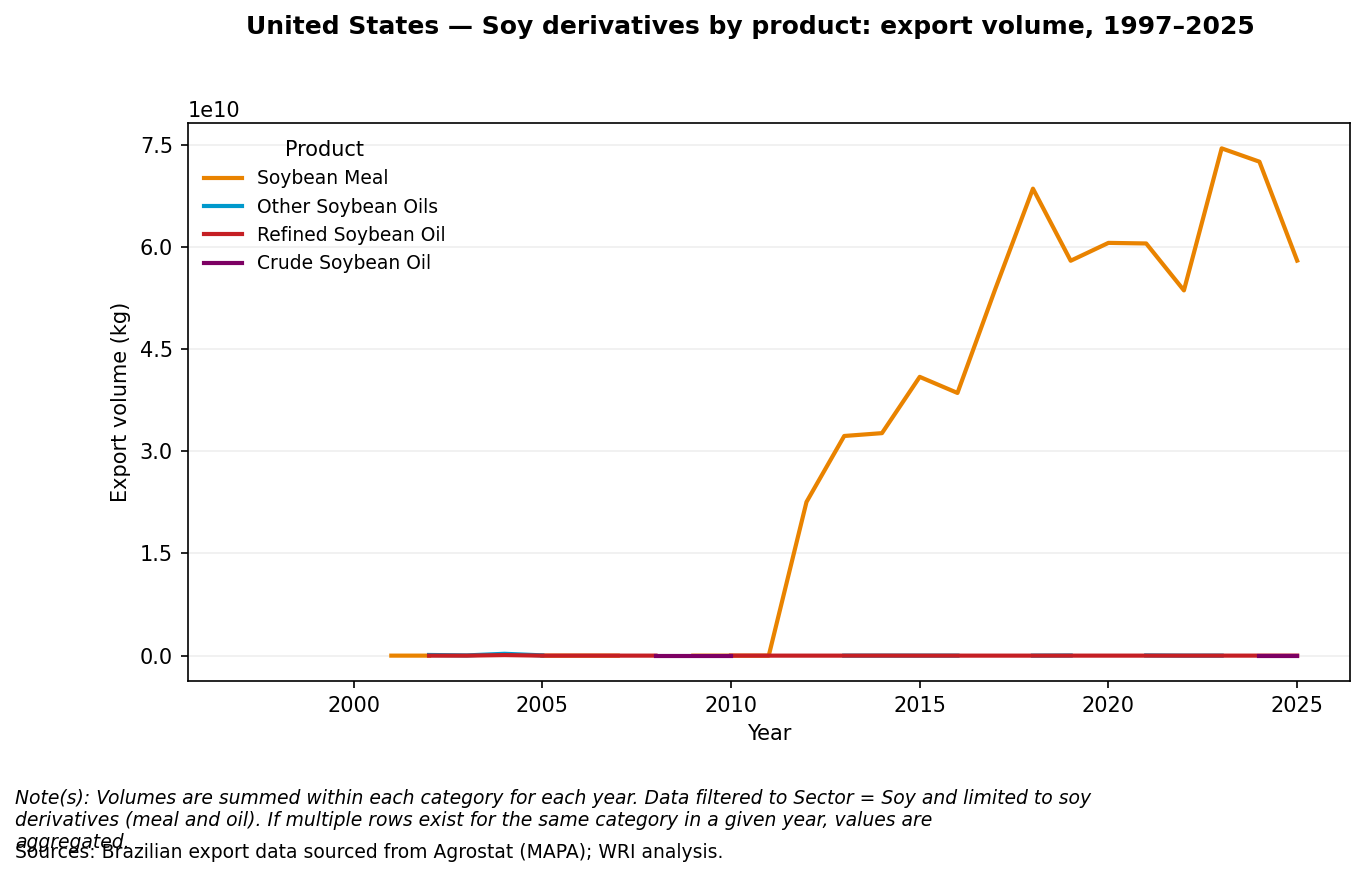

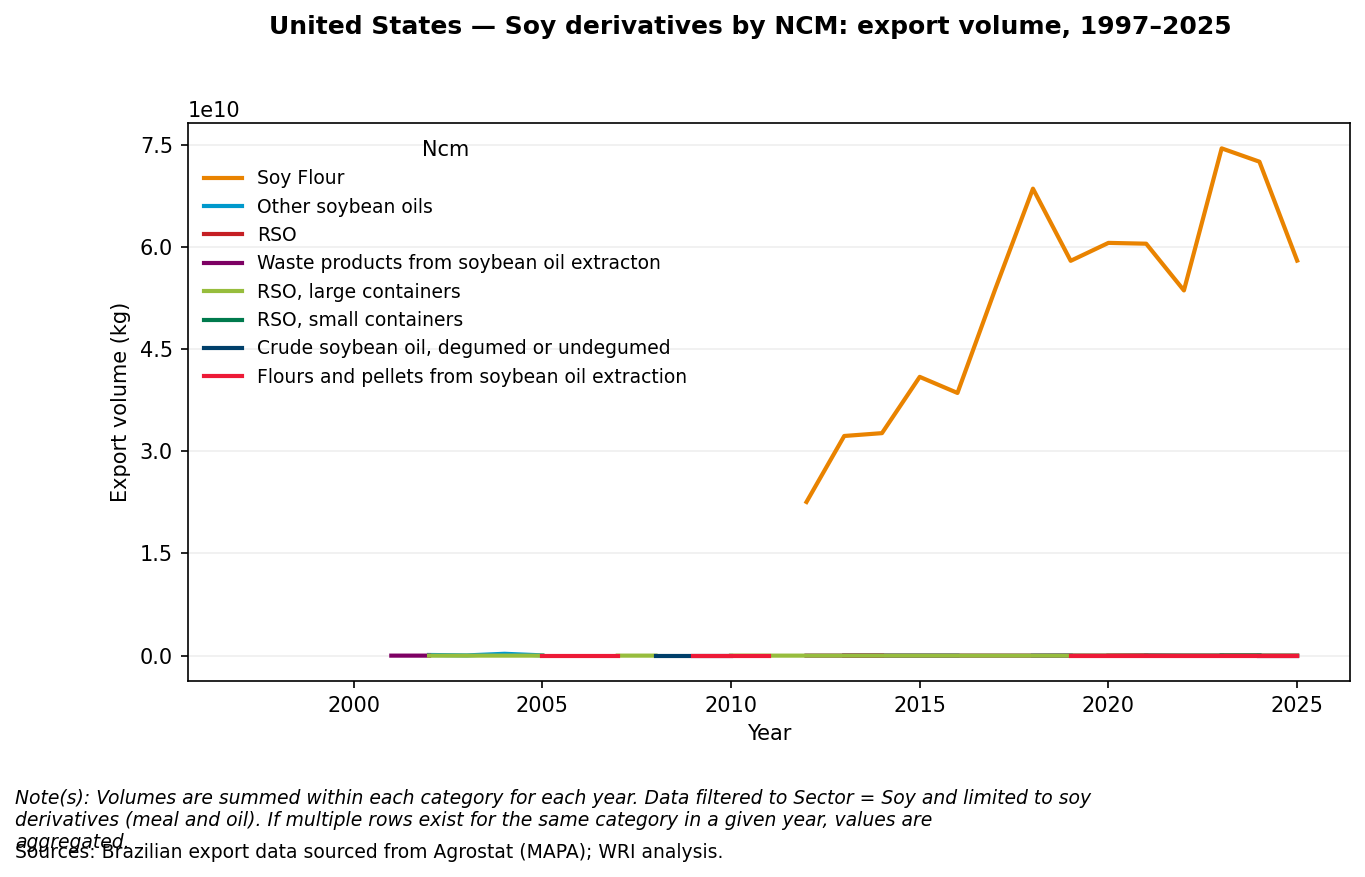

Saved figures:
 - figures_soy_derivatives\all_soy_derivatives_sub_sector_volume_1997_2025.png
 - figures_soy_derivatives\all_soy_derivatives_product_volume_1997_2025.png
 - figures_soy_derivatives\all_soy_derivatives_ncm_volume_1997_2025.png
 - figures_soy_derivatives\china_soy_derivatives_sub_sector_volume_1997_2025.png
 - figures_soy_derivatives\china_soy_derivatives_product_volume_1997_2025.png
 - figures_soy_derivatives\china_soy_derivatives_ncm_volume_1997_2025.png
 - figures_soy_derivatives\european_union_soy_derivatives_sub_sector_volume_1997_2025.png
 - figures_soy_derivatives\european_union_soy_derivatives_product_volume_1997_2025.png
 - figures_soy_derivatives\european_union_soy_derivatives_ncm_volume_1997_2025.png
 - figures_soy_derivatives\united_states_soy_derivatives_sub_sector_volume_1997_2025.png
 - figures_soy_derivatives\united_states_soy_derivatives_product_volume_1997_2025.png
 - figures_soy_derivatives\united_states_soy_derivatives_ncm_volume_1997_2025.png


In [19]:
# JUPYTER NOTEBOOK CELL — SOY DERIVATIVES BY COUNTRY (SUB-SECTOR / PRODUCT / NCM), 1997–2025
# Creates a separate chart per country showing summed export VOLUME (kg) lines for:
#   1) Sub-Sector
#   2) Product
#   3) NCM
# The code reads a two-row header table: row 1 = years, row 2 = measure labels (e.g., "Value (USD)", "Volume (KG)").
# It filters to Sector == "Soy" and keeps soy derivatives (Meal/Oil) by default.
# LINES USE ONLY THE REQUESTED COLOR PALETTE:
# #E98300, #0099CC, #C51F24, #7D0063, #97BD3D, #007A4D, #003F6A, #ED1A37, #FCD900, #9B9B9B

import os
import re
import math
import textwrap
from typing import List, Tuple, Optional, Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# ------------------------------------------------------------------------------------
# 1) Configuration
# ------------------------------------------------------------------------------------

# Path to workbook
EXCEL_PATH = r"D:\WRI\Field Boundaries\Tech Note\Agrostat - Brazil - EUDR Crop Exports\Brazil Commodity Exports - Soy NCM - 1997-2025.xlsx"
# For notebook environments where you've uploaded the file:
# EXCEL_PATH = r"/mnt/data/Brazil Commodity Exports - Soy NCM - 1997-2025.xlsx"

SHEET_NAME = 0

YEAR_START = 1997
YEAR_END = 2025

# Output figure directory
FIG_DIR = "figures_soy_derivatives"
os.makedirs(FIG_DIR, exist_ok=True)

# Requested brand palette (cycled across category lines)
CATEGORY_COLORS = [
    "#E98300", "#0099CC", "#C51F24", "#7D0063", "#97BD3D",
    "#007A4D", "#003F6A", "#ED1A37", "#FCD900", "#9B9B9B"
]

# Notes / sources for figure footers
NOTE_TEXT_BASE = (
    "Volumes are summed within each category for each year. "
    "Data filtered to Sector = Soy and limited to soy derivatives (meal and oil). "
    "If multiple rows exist for the same category in a given year, values are aggregated."
)
SOURCE_TEXT = "Brazilian export data sourced from Agrostat (MAPA); WRI analysis."

# By default we keep only soy derivatives (Meal/Oil). Set to False to include all Soy sub-sectors.
ONLY_SOY_DERIVATIVES = True

# ------------------------------------------------------------------------------------
# 2) Small utilities
# ------------------------------------------------------------------------------------

def _ascii_lower(s: str) -> str:
    if s is None:
        return ""
    s = str(s)
    s = s.replace("Á","A").replace("À","A").replace("Â","A").replace("Ã","A").replace("Ä","A").replace("á","a").replace("à","a").replace("â","a").replace("ã","a").replace("ä","a")
    s = s.replace("É","E").replace("È","E").replace("Ê","E").replace("Ë","E").replace("é","e").replace("è","e").replace("ê","e").replace("ë","e")
    s = s.replace("Í","I").replace("Ì","I").replace("Î","I").replace("Ï","I").replace("í","i").replace("ì","i").replace("î","i").replace("ï","i")
    s = s.replace("Ó","O").replace("Ò","O").replace("Ô","O").replace("Õ","O").replace("Ö","O").replace("ó","o").replace("ò","o").replace("ô","o").replace("õ","o").replace("ö","o")
    s = s.replace("Ú","U").replace("Ù","U").replace("Û","U").replace("Ü","U").replace("ú","u").replace("ù","u").replace("û","u").replace("ü","u")
    s = s.replace("Ç","C").replace("ç","c")
    return s.lower().strip()

def parse_year(x) -> Optional[int]:
    if x is None:
        return None
    s = str(x)
    m = re.search(r"(19|20)\d{2}", s)
    if m:
        return int(m.group(0))
    return None

def is_value_measure(name: str) -> bool:
    s = _ascii_lower(name)
    return any(k in s for k in ["value", "valor", "usd", "us$", "dollar", "d\u00f3lar", "dolar"])

def is_volume_measure(name: str) -> bool:
    s = _ascii_lower(name)
    return any(k in s for k in ["volume", "kg", "peso", "ton", "tonne", "tonnes"])

def to_number(x) -> Optional[float]:
    if x is None or (isinstance(x, float) and math.isnan(x)):
        return None
    if isinstance(x, (int, float, np.integer, np.floating)):
        return float(x)
    s = str(x).strip()
    if s in {"-", "", "nan", "None", "NONE"}:
        return None
    s = s.replace(",", "").replace("\u00a0", "").replace(" ", "")
    try:
        return float(s)
    except Exception:
        return None

def wrap_text(s: str, width: int = 100) -> str:
    return "\n".join(textwrap.wrap(s, width=width, break_long_words=False))

def sentence_case(s: str) -> str:
    s = str(s).strip()
    return s[:1].upper() + s[1:].lower() if s else s

def canon_country_label(s: str) -> str:
    t = _ascii_lower(s)
    if t in {"eu", "ue", "eu-27", "eu27", "eu 27", "ue27", "ue 27"} or "european union" in t:
        return "European Union"
    if any(k in t for k in ["united states", "usa", "u.s.", "us", "eua", "estados unidos"]):
        return "United States"
    if "china" in t:
        return "China"
    return s.strip()

# ------------------------------------------------------------------------------------
# 3) Load and reshape: two-row header (years + measures)
# ------------------------------------------------------------------------------------

def load_wide_table(path: str, sheet_name=0) -> pd.DataFrame:
    df = pd.read_excel(path, sheet_name=sheet_name, header=[0, 1], dtype=object)

    # Normalize MultiIndex; treat blank/Unnamed tops as None
    norm_cols = []
    for col in df.columns:
        if isinstance(col, tuple) and len(col) == 2:
            top, bottom = col
            top_str = "" if (top is None or (isinstance(top, float) and pd.isna(top))) else str(top)
            if top_str.strip() == "" or top_str.lower().startswith("unnamed"):
                top_clean = None
            else:
                top_clean = top
            bottom_clean = str(bottom).strip()
            norm_cols.append((top_clean, bottom_clean))
        else:
            norm_cols.append((None, str(col).strip()))
    df.columns = pd.MultiIndex.from_tuples(norm_cols)
    return df

ID_LABELS = {
    "country": {"country"},
    "sector": {"sector"},
    "sub_sector": {"sub-sector", "sub sector", "subsector", "sub-setor", "sub setor"},
    "product": {"product"},
    "ncm": {"ncm"},
}

def find_id_keys(df_multi: pd.DataFrame) -> Dict[str, Tuple[object, str]]:
    keys: Dict[str, Tuple[object, str]] = {}
    for col in df_multi.columns:
        top, bottom = col
        b = _ascii_lower(bottom)
        for std, labels in ID_LABELS.items():
            if b in labels and std not in keys:
                keys[std] = col
    needed = {"country", "sector", "sub_sector", "product", "ncm"}
    missing = [k for k in needed if k not in keys]
    if missing:
        raise ValueError(f"Could not find ID columns for: {missing}. Please check bottom header labels.")
    return keys

def melt_volume_long(df_multi: pd.DataFrame) -> pd.DataFrame:
    keys = find_id_keys(df_multi)

    vol_cols: List[Tuple[Tuple[object, str], int]] = []
    for (top, bottom) in df_multi.columns:
        y = parse_year(top)
        if y is None:
            continue
        if is_volume_measure(bottom):
            vol_cols.append(((top, bottom), y))

    if not vol_cols:
        raise ValueError("No 'Volume' measure columns were detected. Ensure second header row includes 'Volume (KG)' or similar.")

    id_df = pd.DataFrame({
        "country": df_multi[keys["country"]],
        "sector": df_multi[keys["sector"]],
        "sub_sector": df_multi[keys["sub_sector"]],
        "product": df_multi[keys["product"]],
        "ncm": df_multi[keys["ncm"]],
    })

    df_vol = id_df.copy()
    for (key, y) in vol_cols:
        df_vol[y] = df_multi[key]

    longv = df_vol.melt(
        id_vars=["country", "sector", "sub_sector", "product", "ncm"],
        var_name="year",
        value_name="volume_kg"
    )

    longv["year"] = pd.to_numeric(longv["year"], errors="coerce").astype("Int64")
    longv["volume_kg"] = longv["volume_kg"].apply(to_number)

    longv = longv.dropna(subset=["year"]).copy()
    longv = longv[(longv["year"] >= YEAR_START) & (longv["year"] <= YEAR_END)].copy()

    for c in ["country", "sector", "sub_sector", "product", "ncm"]:
        longv[c] = longv[c].astype(str).str.strip()

    return longv

# ------------------------------------------------------------------------------------
# 4) Filter to Soy derivatives (Meal/Oil), then aggregate
# ------------------------------------------------------------------------------------

def is_soy_derivative(sub_sector: str, product: str) -> bool:
    ss = _ascii_lower(sub_sector)
    pp = _ascii_lower(product)
    has_deriv = ("meal" in ss) or ("oil" in ss) or ("meal" in pp) or ("oil" in pp)
    has_grain = ("grain" in ss) or ("grain" in pp)
    return has_deriv and not has_grain

def filter_soy_derivatives(longv: pd.DataFrame) -> pd.DataFrame:
    mask_sector = longv["sector"].astype(str).str.lower().str.contains(r"\bsoy\b", regex=True, na=False)
    df = longv[mask_sector].copy()
    if ONLY_SOY_DERIVATIVES:
        mask_deriv = df.apply(lambda r: is_soy_derivative(str(r["sub_sector"]), str(r["product"])), axis=1)
        df = df[mask_deriv].copy()
    df["country_label"] = df["country"].apply(canon_country_label)
    return df

def agg_by_dimension(df: pd.DataFrame, country: str, dim: str) -> pd.DataFrame:
    sub = df[df["country_label"] == country].copy()
    if sub.empty:
        return pd.DataFrame()
    g = sub.groupby(["year", dim], dropna=False)["volume_kg"].sum(min_count=1).reset_index()
    piv = g.pivot(index="year", columns=dim, values="volume_kg").sort_index()
    return piv

# ------------------------------------------------------------------------------------
# 5) Plotting helpers (WRI style) — uses only CATEGORY_COLORS for lines
# ------------------------------------------------------------------------------------

def plot_country_dimension_lines(
    pivot: pd.DataFrame,
    country: str,
    dim: str,
    note_text: str,
    source_text: str,
    save_dir: str
) -> Optional[str]:
    if pivot.empty or pivot.shape[1] == 0:
        return None

    col_totals = pivot.sum(axis=0, skipna=True).sort_values(ascending=False)
    pivot = pivot[col_totals.index]

    colors = [CATEGORY_COLORS[i % len(CATEGORY_COLORS)] for i in range(pivot.shape[1])]

    fig, ax = plt.subplots(figsize=(10, 6), dpi=150)

    for i, col in enumerate(pivot.columns):
        ax.plot(pivot.index.values, pivot[col].values, label=str(col), linewidth=2.0, color=colors[i])

    ax.set_xlabel("Year")
    ax.set_ylabel("Export volume (kg)")
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6))
    ax.grid(True, axis="y", alpha=0.2, linewidth=0.8)

    legend_title = {"sub_sector": "sub-sector", "product": "product", "ncm": "NCM"}[dim]
    ax.legend(title=sentence_case(legend_title), frameon=False, ncol=1, fontsize=9)

    title_bits = {
        "sub_sector": "Soy derivatives by sub-sector",
        "product": "Soy derivatives by product",
        "ncm": "Soy derivatives by NCM"
    }
    title = f"{country} — {title_bits[dim]}: export volume, {YEAR_START}–{YEAR_END}"
    plt.suptitle(title, fontsize=12, fontweight="bold", y=0.98)

    nt = wrap_text(note_text, width=110)
    st = wrap_text(source_text, width=110)
    plt.subplots_adjust(top=0.86, bottom=0.24)
    fig.text(0.01, 0.12, f"Note(s): {nt}", ha="left", va="top", fontsize=9, style="italic")
    fig.text(0.01, 0.06, f"Sources: {st}", ha="left", va="top", fontsize=9)

    safe_country = _ascii_lower(country).replace(" ", "_").replace("-", "_")
    outname = f"{safe_country}_soy_derivatives_{dim}_volume_{YEAR_START}_{YEAR_END}.png"
    outpath = os.path.join(save_dir, outname)
    plt.savefig(outpath, bbox_inches="tight")
    plt.show()

    return outpath

# ------------------------------------------------------------------------------------
# 6) Run: load, reshape, filter, aggregate, and plot for each country and dimension
# ------------------------------------------------------------------------------------

df_wide = load_wide_table(EXCEL_PATH, sheet_name=SHEET_NAME)
df_long_vol = melt_volume_long(df_wide)
df_soy = filter_soy_derivatives(df_long_vol)

countries = sorted(df_soy["country_label"].dropna().unique().tolist())
print("Countries detected (soy derivatives):", countries)

saved_files: List[str] = []

for country in countries:
    piv_sub = agg_by_dimension(df_soy, country=country, dim="sub_sector")
    p1 = plot_country_dimension_lines(
        pivot=piv_sub,
        country=country,
        dim="sub_sector",
        note_text=NOTE_TEXT_BASE,
        source_text=SOURCE_TEXT,
        save_dir=FIG_DIR
    )
    if p1:
        saved_files.append(p1)

    piv_prod = agg_by_dimension(df_soy, country=country, dim="product")
    p2 = plot_country_dimension_lines(
        pivot=piv_prod,
        country=country,
        dim="product",
        note_text=NOTE_TEXT_BASE,
        source_text=SOURCE_TEXT,
        save_dir=FIG_DIR
    )
    if p2:
        saved_files.append(p2)

    piv_ncm = agg_by_dimension(df_soy, country=country, dim="ncm")
    p3 = plot_country_dimension_lines(
        pivot=piv_ncm,
        country=country,
        dim="ncm",
        note_text=NOTE_TEXT_BASE,
        source_text=SOURCE_TEXT,
        save_dir=FIG_DIR
    )
    if p3:
        saved_files.append(p3)

print("Saved figures:")
for p in saved_files:
    print(" -", p)
